In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
matches = pd.read_csv('matches.csv')
deliveries = pd.read_csv('deliveries.csv')

print("matches.csv loaded!")
print("Shape:", matches.shape)
print("")
print("deliveries.csv loaded!")
print("Shape:", deliveries.shape)

matches.csv loaded!
Shape: (1095, 20)

deliveries.csv loaded!
Shape: (260920, 17)


In [3]:
matches.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.00,223.00,20.00,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.00,241.00,20.00,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.00,130.00,20.00,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.00,166.00,20.00,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.00,111.00,20.00,N,NaN,BF Bowden,K Hariharan


In [4]:
matches.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   object 
 2   city             1044 non-null   object 
 3   date             1095 non-null   object 
 4   match_type       1095 non-null   object 
 5   player_of_match  1090 non-null   object 
 6   venue            1095 non-null   object 
 7   team1            1095 non-null   object 
 8   team2            1095 non-null   object 
 9   toss_winner      1095 non-null   object 
 10  toss_decision    1095 non-null   object 
 11  winner           1090 non-null   object 
 12  result           1095 non-null   object 
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   object 
 17  method        

In [5]:
print("Missing values in matches:")
print(matches.isnull().sum())


Missing values in matches:
id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64


In [6]:
print("Missing values in deliveries:")
print(deliveries.isnull().sum())

Missing values in deliveries:
match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batter                   0
bowler                   0
non_striker              0
batsman_runs             0
extra_runs               0
total_runs               0
extras_type         246795
is_wicket                0
player_dismissed    247970
dismissal_kind      247970
fielder             251566
dtype: int64


In [7]:
deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [8]:
print("Teams in dataset:")
print(sorted(matches['team1'].unique()))
print("")
print("Total unique teams:", matches['team1'].nunique())

Teams in dataset:
['Chennai Super Kings', 'Deccan Chargers', 'Delhi Capitals', 'Delhi Daredevils', 'Gujarat Lions', 'Gujarat Titans', 'Kings XI Punjab', 'Kochi Tuskers Kerala', 'Kolkata Knight Riders', 'Lucknow Super Giants', 'Mumbai Indians', 'Pune Warriors', 'Punjab Kings', 'Rajasthan Royals', 'Rising Pune Supergiant', 'Rising Pune Supergiants', 'Royal Challengers Bangalore', 'Royal Challengers Bengaluru', 'Sunrisers Hyderabad']

Total unique teams: 19


In [9]:
# Fix inconsistent team names
team_name_fixes = {
    'Delhi Daredevils': 'Delhi Capitals',
    'Kings XI Punjab': 'Punjab Kings',
    'Rising Pune Supergiant': 'Rising Pune Supergiants',
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru'
}

# Apply fixes to matches
for col in ['team1', 'team2', 'toss_winner', 'winner']:
    matches[col] = matches[col].replace(team_name_fixes)

# Apply fixes to deliveries
for col in ['batting_team', 'bowling_team']:
    deliveries[col] = deliveries[col].replace(team_name_fixes)

print("Team names fixed!")
print("")
print("Updated unique teams:")
print(sorted(matches['team1'].unique()))
print("")
print("Total unique teams:", matches['team1'].nunique())


Team names fixed!

Updated unique teams:
['Chennai Super Kings', 'Deccan Chargers', 'Delhi Capitals', 'Gujarat Lions', 'Gujarat Titans', 'Kochi Tuskers Kerala', 'Kolkata Knight Riders', 'Lucknow Super Giants', 'Mumbai Indians', 'Pune Warriors', 'Punjab Kings', 'Rajasthan Royals', 'Rising Pune Supergiants', 'Royal Challengers Bengaluru', 'Sunrisers Hyderabad']

Total unique teams: 15


In [10]:
print("Matches before cleaning:", len(matches))

matches = matches.dropna(subset=['winner'])

print("Matches after removing no results:", len(matches))
print("Removed:", 1095 - len(matches), "matches")

Matches before cleaning: 1095
Matches after removing no results: 1090
Removed: 5 matches


In [11]:
print("Seasons in dataset:")
print(sorted(matches['season'].unique()))
print("")
print("Matches per season:")
print(matches['season'].value_counts().sort_index())

Seasons in dataset:
['2007/08', '2009', '2009/10', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020/21', '2021', '2022', '2023', '2024']

Matches per season:
season
2007/08    58
2009       57
2009/10    60
2011       72
2012       74
2013       76
2014       60
2015       57
2016       60
2017       59
2018       60
2019       59
2020/21    60
2021       60
2022       74
2023       73
2024       71
Name: count, dtype: int64


In [12]:
season_fixes = {
    '2007/08': '2008',
    '2009/10': '2010',
    '2020/21': '2021'
}

matches['season'] = matches['season'].replace(season_fixes)
matches['season'] = matches['season'].astype(int)

print("Seasons fixed!")
print("")
print("Matches per season:")
print(matches['season'].value_counts().sort_index())


Seasons fixed!

Matches per season:
season
2008     58
2009     57
2010     60
2011     72
2012     74
2013     76
2014     60
2015     57
2016     60
2017     59
2018     60
2019     59
2021    120
2022     74
2023     73
2024     71
Name: count, dtype: int64


In [13]:
season_fixes = {
    '2007/08': '2008',
    '2009/10': '2010',
    '2020/21': '2020'
}

# Reload matches fresh and reapply all fixes
matches = pd.read_csv('matches.csv')
matches = matches.dropna(subset=['winner'])

# Fix team names again
team_name_fixes = {
    'Delhi Daredevils': 'Delhi Capitals',
    'Kings XI Punjab': 'Punjab Kings',
    'Rising Pune Supergiant': 'Rising Pune Supergiants',
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru'
}
for col in ['team1', 'team2', 'toss_winner', 'winner']:
    matches[col] = matches[col].replace(team_name_fixes)

# Fix seasons
matches['season'] = matches['season'].replace(season_fixes)
matches['season'] = matches['season'].astype(int)

print("All fixes applied!")
print("")
print("Matches per season:")
print(matches['season'].value_counts().sort_index())

All fixes applied!

Matches per season:
season
2008    58
2009    57
2010    60
2011    72
2012    74
2013    76
2014    60
2015    57
2016    60
2017    59
2018    60
2019    59
2020    60
2021    60
2022    74
2023    73
2024    71
Name: count, dtype: int64


In [14]:
matches.to_csv('matches_cleaned.csv', index=False)

print("Cleaned data saved!")
print("matches_cleaned.csv is ready")

Cleaned data saved!
matches_cleaned.csv is ready


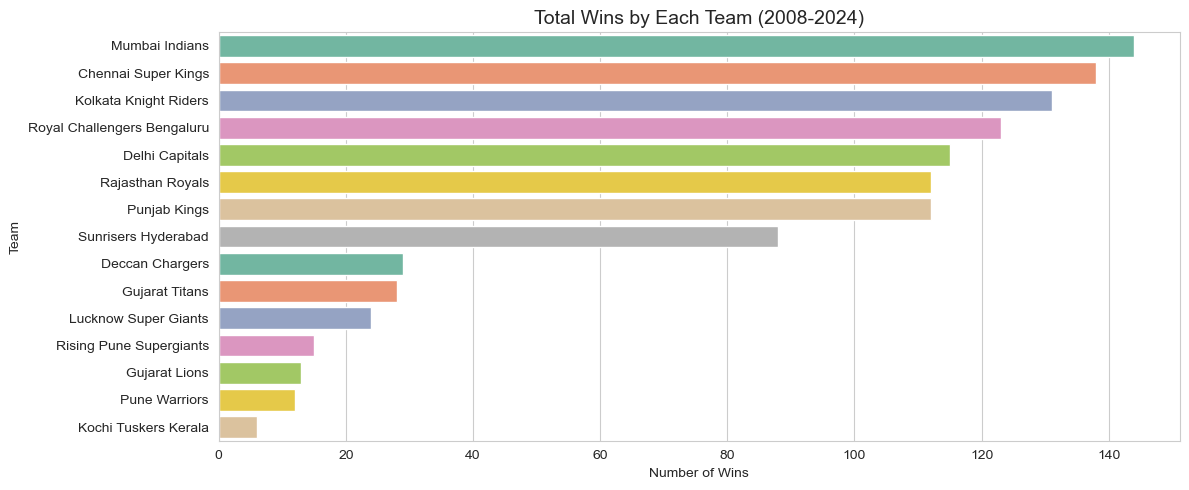

winner
Mumbai Indians                 144
Chennai Super Kings            138
Kolkata Knight Riders          131
Royal Challengers Bengaluru    123
Delhi Capitals                 115
Rajasthan Royals               112
Punjab Kings                   112
Sunrisers Hyderabad             88
Deccan Chargers                 29
Gujarat Titans                  28
Lucknow Super Giants            24
Rising Pune Supergiants         15
Gujarat Lions                   13
Pune Warriors                   12
Kochi Tuskers Kerala             6
Name: count, dtype: int64


In [15]:
plt.figure(figsize=(12, 5))

win_counts = matches['winner'].value_counts()

sns.barplot(x=win_counts.values, y=win_counts.index, palette='Set2')

plt.title('Total Wins by Each Team (2008-2024)', fontsize=14)
plt.xlabel('Number of Wins')
plt.ylabel('Team')
plt.tight_layout()
plt.show()

print(win_counts)

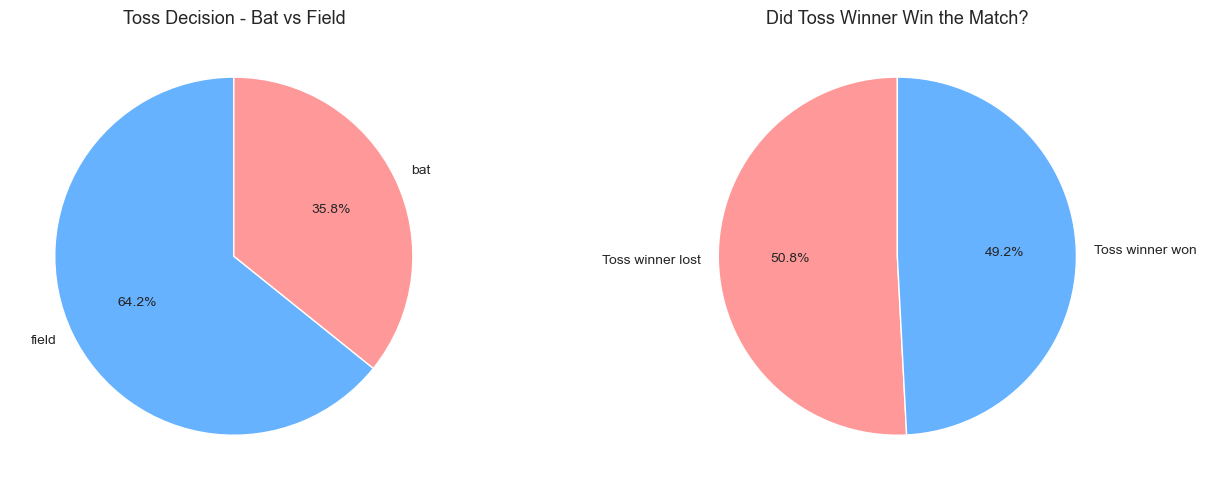

Toss decision counts:
toss_decision
field    700
bat      390
Name: count, dtype: int64

Toss winner won the match:
toss_match_winner
True     554
False    536
Name: count, dtype: int64


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1 - Toss decision (bat vs field)
toss_decision = matches['toss_decision'].value_counts()
axes[0].pie(toss_decision.values, 
            labels=toss_decision.index,
            autopct='%1.1f%%',
            colors=['#66b2ff', '#ff9999'],
            startangle=90)
axes[0].set_title('Toss Decision - Bat vs Field', fontsize=13)

# Chart 2 - Did toss winner win the match?
matches['toss_match_winner'] = (matches['toss_winner'] == matches['winner'])
toss_impact = matches['toss_match_winner'].value_counts()
axes[1].pie(toss_impact.values,
            labels=['Toss winner lost', 'Toss winner won'],
            autopct='%1.1f%%',
            colors=['#ff9999', '#66b2ff'],
            startangle=90)
axes[1].set_title('Did Toss Winner Win the Match?', fontsize=13)

plt.tight_layout()
plt.show()

print("Toss decision counts:")
print(toss_decision)
print("")
print("Toss winner won the match:")
print(toss_impact)

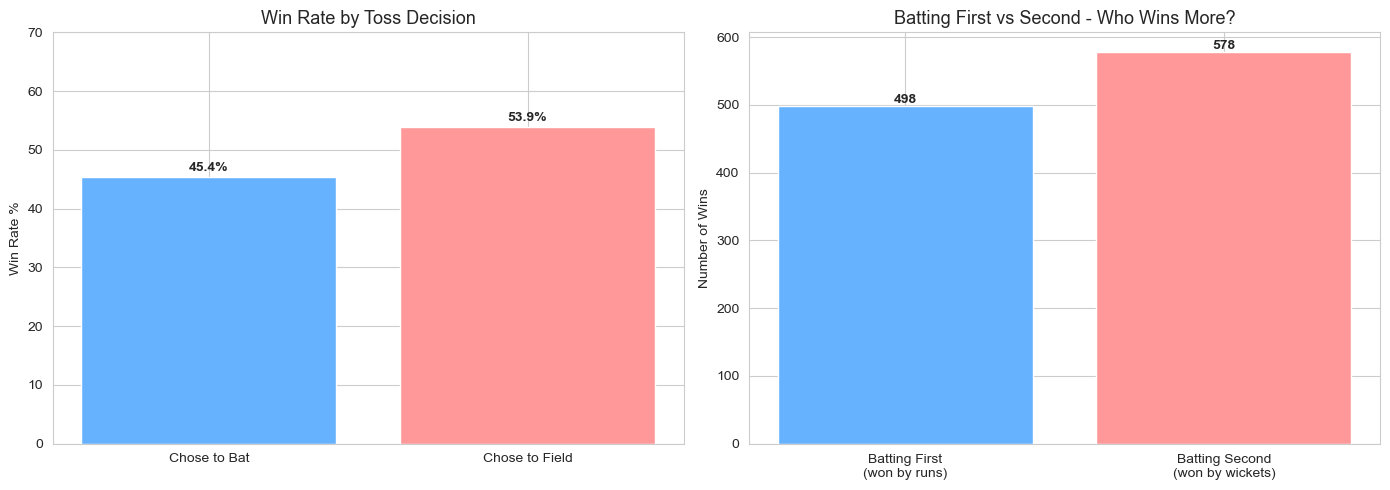

Bat first win rate: 45.4%
Field first win rate: 53.9%
Batting first wins: 498
Batting second wins: 578


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1 - Win rate by toss decision
bat_first_wins = matches[matches['toss_decision'] == 'bat']['toss_match_winner'].mean() * 100
field_first_wins = matches[matches['toss_decision'] == 'field']['toss_match_winner'].mean() * 100

axes[0].bar(['Chose to Bat', 'Chose to Field'],
            [bat_first_wins, field_first_wins],
            color=['#66b2ff', '#ff9999'])
axes[0].set_title('Win Rate by Toss Decision', fontsize=13)
axes[0].set_ylabel('Win Rate %')
axes[0].set_ylim(0, 70)
for i, v in enumerate([bat_first_wins, field_first_wins]):
    axes[0].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

# Chart 2 - Win rate batting first vs second overall
batting_first_wins = len(matches[matches['result'] == 'runs'])
batting_second_wins = len(matches[matches['result'] == 'wickets'])

axes[1].bar(['Batting First\n(won by runs)', 'Batting Second\n(won by wickets)'],
            [batting_first_wins, batting_second_wins],
            color=['#66b2ff', '#ff9999'])
axes[1].set_title('Batting First vs Second - Who Wins More?', fontsize=13)
axes[1].set_ylabel('Number of Wins')
for i, v in enumerate([batting_first_wins, batting_second_wins]):
    axes[1].text(i, v + 5, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Bat first win rate: {bat_first_wins:.1f}%")
print(f"Field first win rate: {field_first_wins:.1f}%")
print(f"Batting first wins: {batting_first_wins}")
print(f"Batting second wins: {batting_second_wins}")

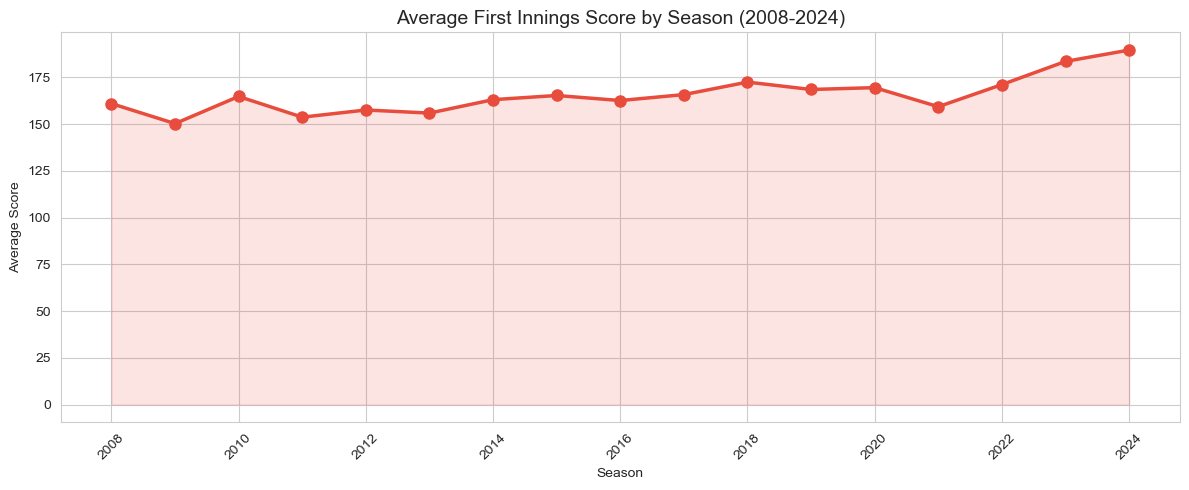

Average first innings score per season:
match_id
2008.00   161.00
2009.00   150.30
2010.00   164.80
2011.00   153.70
2012.00   157.50
2013.00   155.90
2014.00   163.10
2015.00   165.30
2016.00   162.60
2017.00   165.80
2018.00   172.50
2019.00   168.50
2020.00   169.50
2021.00   159.30
2022.00   171.10
2023.00   183.50
2024.00   189.60
dtype: float64


In [18]:
# Get first innings scores from deliveries
first_innings = deliveries[deliveries['inning'] == 1]

season_scores = first_innings.groupby(
    first_innings['match_id'].map(matches.set_index('id')['season'])
)['total_runs'].sum() / first_innings.groupby(
    first_innings['match_id'].map(matches.set_index('id')['season'])
)['match_id'].nunique()

plt.figure(figsize=(12, 5))
plt.plot(season_scores.index, season_scores.values, 
         marker='o', linewidth=2.5, 
         color='#e74c3c', markersize=8)
plt.fill_between(season_scores.index, season_scores.values, 
                 alpha=0.15, color='#e74c3c')
plt.title('Average First Innings Score by Season (2008-2024)', fontsize=14)
plt.xlabel('Season')
plt.ylabel('Average Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Average first innings score per season:")
print(season_scores.round(1))

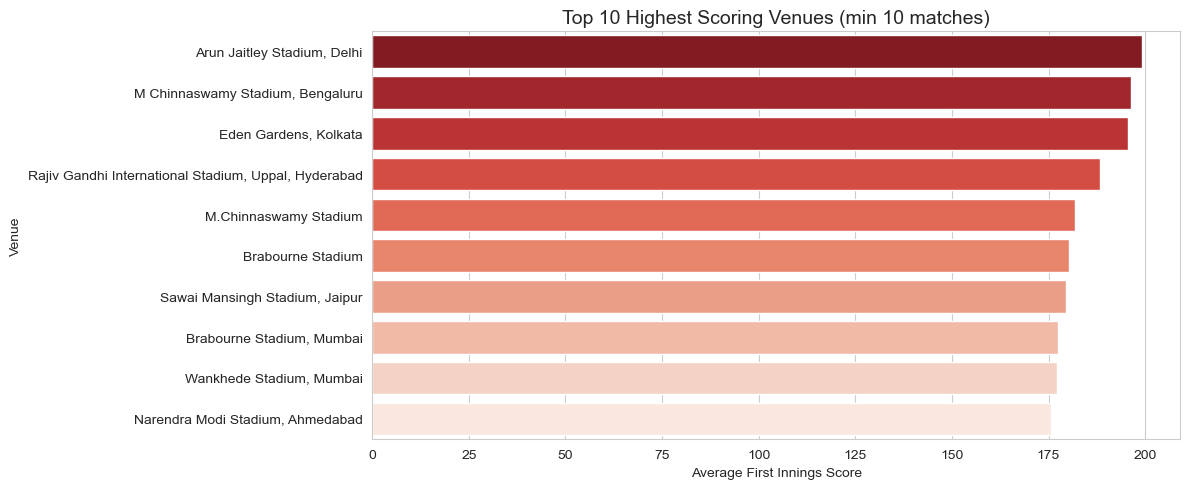

                                               venue  avg_score  matches
                         Arun Jaitley Stadium, Delhi     199.06       16
                    M Chinnaswamy Stadium, Bengaluru     196.21       14
                               Eden Gardens, Kolkata     195.62       16
Rajiv Gandhi International Stadium, Uppal, Hyderabad     188.38       13
                               M.Chinnaswamy Stadium     181.93       14
                                   Brabourne Stadium     180.40       10
                      Sawai Mansingh Stadium, Jaipur     179.50       10
                           Brabourne Stadium, Mumbai     177.41       17
                            Wankhede Stadium, Mumbai     177.11       45
                    Narendra Modi Stadium, Ahmedabad     175.75       24


In [19]:
# merge match info with deliveries
first_innings = deliveries[deliveries['inning'] == 1]
match_scores = first_innings.groupby('match_id')['total_runs'].sum().reset_index()
match_scores.columns = ['id', 'first_innings_score']
match_scores = match_scores.merge(matches[['id', 'venue']], on='id')

# average score per venue (only venues with 10+ matches)
venue_scores = match_scores.groupby('venue').agg(
    avg_score=('first_innings_score', 'mean'),
    matches=('first_innings_score', 'count')
).reset_index()

venue_scores = venue_scores[venue_scores['matches'] >= 10]
venue_scores = venue_scores.sort_values('avg_score', ascending=False).head(10)

plt.figure(figsize=(12, 5))
sns.barplot(data=venue_scores, 
            x='avg_score', 
            y='venue', 
            palette='Reds_r')
plt.title('Top 10 Highest Scoring Venues (min 10 matches)', fontsize=14)
plt.xlabel('Average First Innings Score')
plt.ylabel('Venue')
plt.tight_layout()
plt.show()

print(venue_scores[['venue', 'avg_score', 'matches']].to_string(index=False))

In [20]:
venue_fixes = {
    'M.Chinnaswamy Stadium': 'M Chinnaswamy Stadium, Bengaluru',
    'Punjab Cricket Association Stadium, Mohali': 'Punjab Cricket Association IS Bindra Stadium, Mohali',
    'Punjab Cricket Association IS Bindra Stadium, Mohali, Chandigarh': 'Punjab Cricket Association IS Bindra Stadium, Mohali',
    'Feroz Shah Kotla': 'Arun Jaitley Stadium, Delhi',
    'Feroz Shah Kotla Ground': 'Arun Jaitley Stadium, Delhi',
    'Rajiv Gandhi International Stadium, Uppal': 'Rajiv Gandhi International Stadium, Uppal, Hyderabad',
    'Dr DY Patil Sports Academy, Mumbai': 'Dr DY Patil Sports Academy',
    'Brabourne Stadium, Mumbai': 'Brabourne Stadium',
    'Eden Gardens, Kolkata': 'Eden Gardens',
    'Wankhede Stadium, Mumbai': 'Wankhede Stadium',
    'Sawai Mansingh Stadium, Jaipur': 'Sawai Mansingh Stadium',
}

# Only fix matches - deliveries has no venue column
matches['venue'] = matches['venue'].replace(venue_fixes)

print("Venue names fixed!")
print("")
print("Total unique venues now:", matches['venue'].nunique())

Venue names fixed!

Total unique venues now: 48


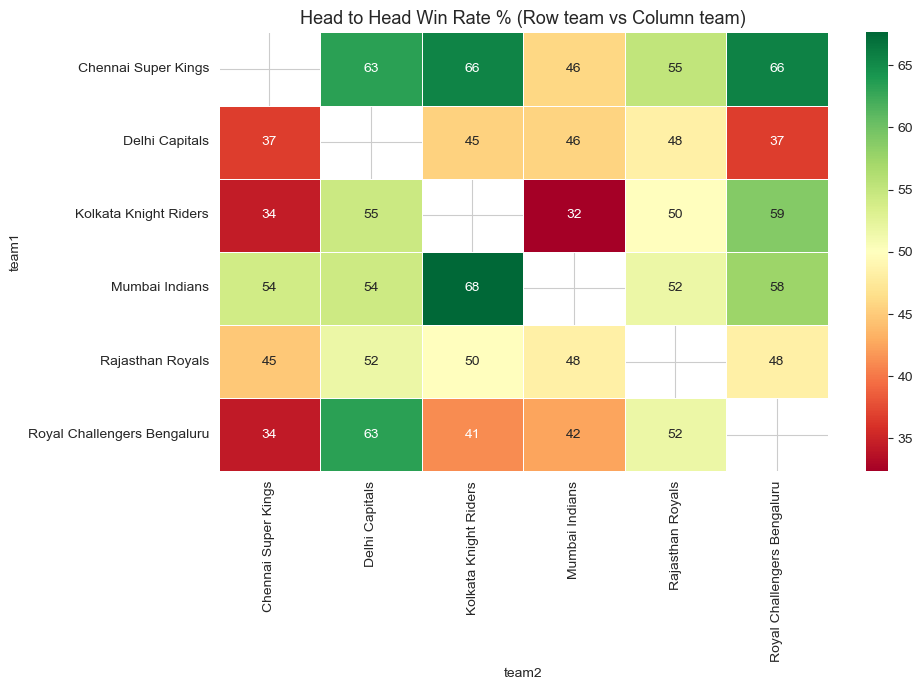

In [21]:
top_teams = ['Mumbai Indians', 'Chennai Super Kings', 
             'Kolkata Knight Riders', 'Royal Challengers Bengaluru',
             'Delhi Capitals', 'Rajasthan Royals']

h2h_data = []
for t1 in top_teams:
    for t2 in top_teams:
        if t1 != t2:
            games = matches[
                ((matches['team1'] == t1) & (matches['team2'] == t2)) |
                ((matches['team1'] == t2) & (matches['team2'] == t1))
            ]
            if len(games) > 0:
                wins = (games['winner'] == t1).sum()
                h2h_data.append({
                    'team1': t1,
                    'team2': t2,
                    'win_rate': wins / len(games) * 100
                })

h2h_df = pd.DataFrame(h2h_data)
h2h_pivot = h2h_df.pivot(index='team1', columns='team2', values='win_rate')

plt.figure(figsize=(10, 7))
sns.heatmap(h2h_pivot, 
            annot=True, 
            fmt='.0f',
            cmap='RdYlGn',
            center=50,
            linewidths=0.5)
plt.title('Head to Head Win Rate % (Row team vs Column team)', fontsize=13)
plt.tight_layout()
plt.show()

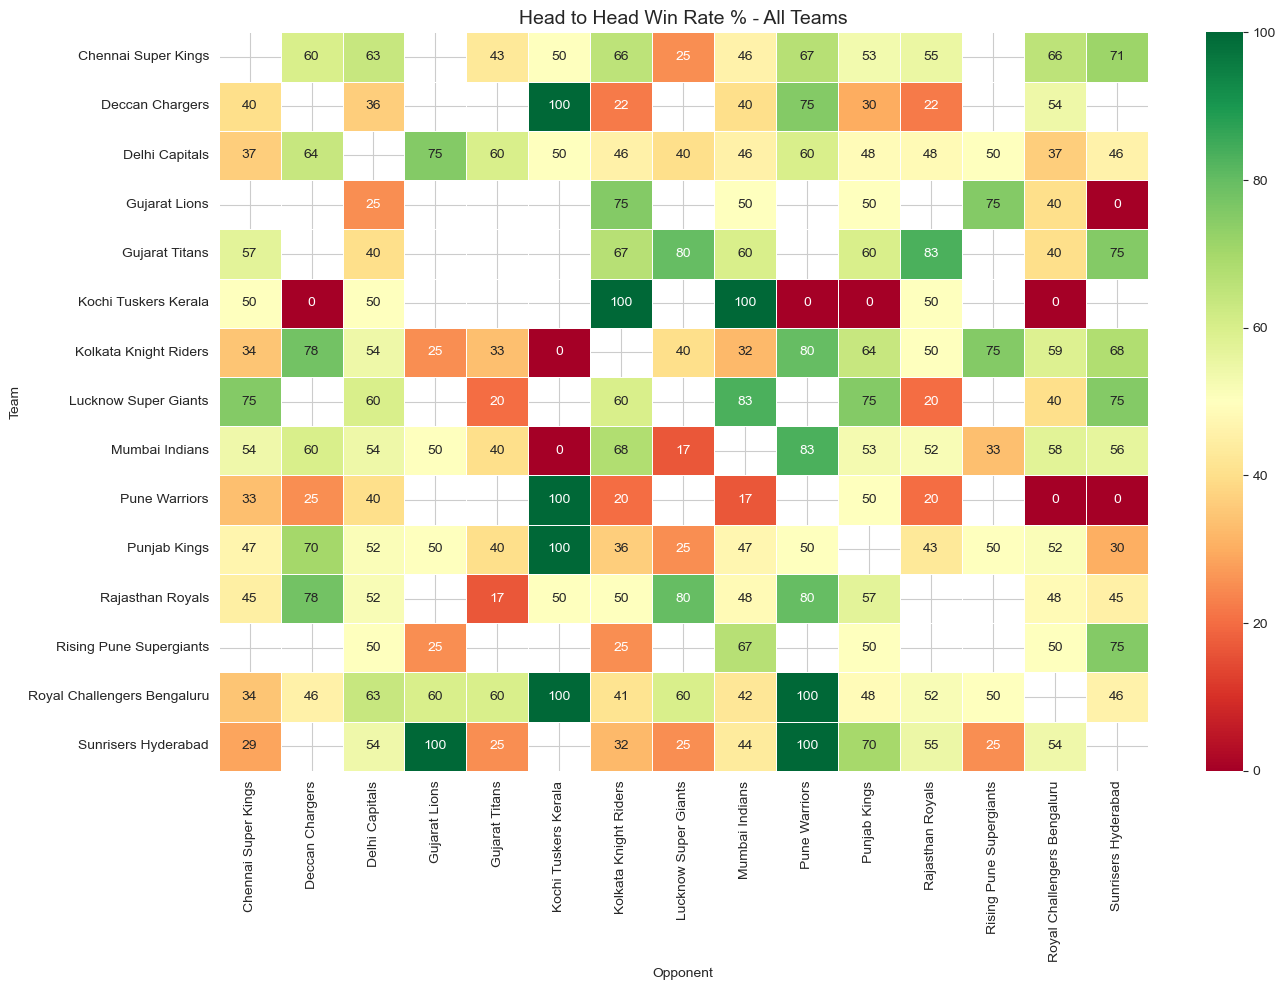

Complete Head to Head Records:

                       Team                    Opponent  Played  Wins  Losses  Win Rate %
        Chennai Super Kings             Deccan Chargers      10     6       4       60.00
        Chennai Super Kings              Delhi Capitals      30    19      11       63.30
        Chennai Super Kings              Gujarat Titans       7     3       4       42.90
        Chennai Super Kings        Kochi Tuskers Kerala       2     1       1       50.00
        Chennai Super Kings       Kolkata Knight Riders      29    19      10       65.50
        Chennai Super Kings        Lucknow Super Giants       4     1       3       25.00
        Chennai Super Kings              Mumbai Indians      37    17      20       45.90
        Chennai Super Kings               Pune Warriors       6     4       2       66.70
        Chennai Super Kings                Punjab Kings      30    16      14       53.30
        Chennai Super Kings            Rajasthan Royals      29    1

In [22]:
all_teams = sorted(matches['winner'].unique())

h2h_data = []
for t1 in all_teams:
    for t2 in all_teams:
        if t1 != t2:
            games = matches[
                ((matches['team1'] == t1) & (matches['team2'] == t2)) |
                ((matches['team1'] == t2) & (matches['team2'] == t1))
            ]
            if len(games) > 0:
                wins = (games['winner'] == t1).sum()
                h2h_data.append({
                    'Team': t1,
                    'Opponent': t2,
                    'Played': len(games),
                    'Wins': wins,
                    'Losses': len(games) - wins,
                    'Win Rate %': round(wins / len(games) * 100, 1)
                })

h2h_df = pd.DataFrame(h2h_data)

# Plot heatmap
h2h_pivot = h2h_df.pivot(index='Team', columns='Opponent', values='Win Rate %')

plt.figure(figsize=(14, 10))
sns.heatmap(h2h_pivot,
            annot=True,
            fmt='.0f',
            cmap='RdYlGn',
            center=50,
            linewidths=0.5)
plt.title('Head to Head Win Rate % - All Teams', fontsize=14)
plt.tight_layout()
plt.show()

# Print full data
print("Complete Head to Head Records:")
print("")
print(h2h_df.to_string(index=False))

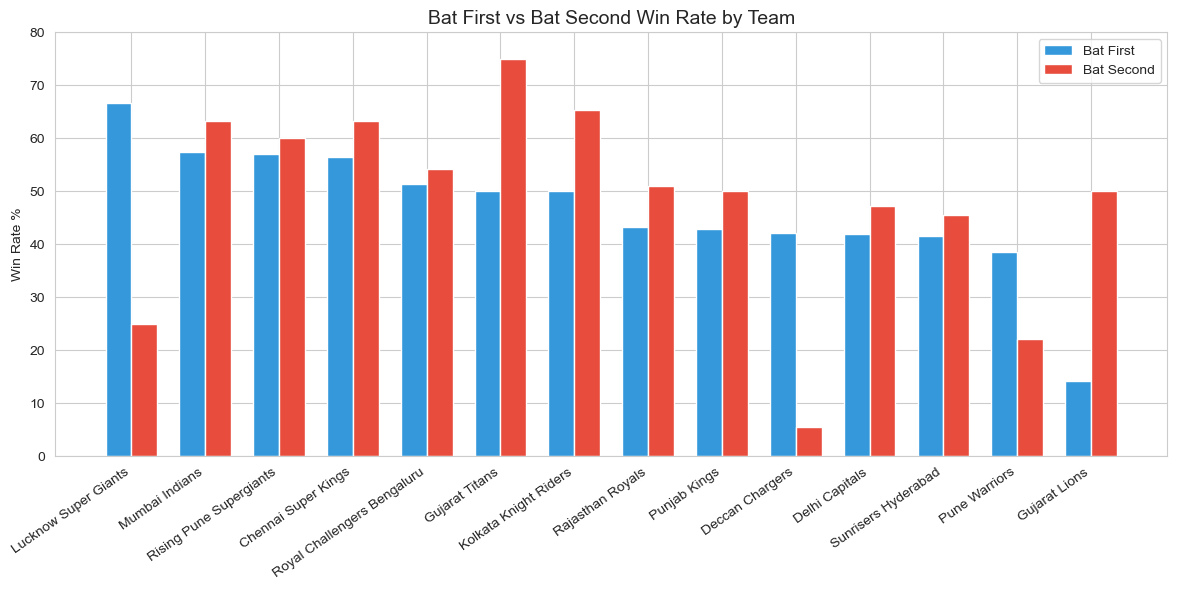

                       Team  Bat First Win%  Bat Second Win%  Total Matches
       Lucknow Super Giants           66.70            25.00             14
             Mumbai Indians           57.40            63.30            103
    Rising Pune Supergiants           57.10            60.00             17
        Chennai Super Kings           56.50            63.30             92
Royal Challengers Bengaluru           51.30            54.20             87
             Gujarat Titans           50.00            75.00             14
      Kolkata Knight Riders           50.00            65.40             96
           Rajasthan Royals           43.20            51.10             82
               Punjab Kings           42.90            50.00             92
            Deccan Chargers           42.10             5.60             37
             Delhi Capitals           41.90            47.20             96
        Sunrisers Hyderabad           41.50            45.50             74
            

In [23]:
fig, ax = plt.subplots(figsize=(12, 6))

team_batting_first = []
for team in sorted(matches['winner'].unique()):
    # matches where team batted first
    bat_first = matches[
        ((matches['team1'] == team) & (matches['toss_decision'] == 'bat') & (matches['toss_winner'] == team)) |
        ((matches['team2'] == team) & (matches['toss_decision'] == 'field') & (matches['toss_winner'] != team))
    ]
    # matches where team batted second
    bat_second = matches[
        ((matches['team1'] == team) & (matches['toss_decision'] == 'field') & (matches['toss_winner'] == team)) |
        ((matches['team2'] == team) & (matches['toss_decision'] == 'bat') & (matches['toss_winner'] != team))
    ]

    if len(bat_first) > 5 and len(bat_second) > 5:
        team_batting_first.append({
            'Team': team,
            'Bat First Win%': round(bat_first['winner'].eq(team).sum() / len(bat_first) * 100, 1),
            'Bat Second Win%': round(bat_second['winner'].eq(team).sum() / len(bat_second) * 100, 1),
            'Total Matches': len(bat_first) + len(bat_second)
        })

bat_df = pd.DataFrame(team_batting_first).sort_values('Bat First Win%', ascending=False)

x = range(len(bat_df))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], bat_df['Bat First Win%'], 
               width, label='Bat First', color='#3498db')
bars2 = ax.bar([i + width/2 for i in x], bat_df['Bat Second Win%'], 
               width, label='Bat Second', color='#e74c3c')

ax.set_xticks(x)
ax.set_xticklabels(bat_df['Team'], rotation=35, ha='right')
ax.set_ylabel('Win Rate %')
ax.set_title('Bat First vs Bat Second Win Rate by Team', fontsize=14)
ax.legend()
ax.set_ylim(0, 80)
plt.tight_layout()
plt.show()

print(bat_df.to_string(index=False))

In [24]:
# Calculate overall win rate for each team
team_wins = matches['winner'].value_counts()
team_matches = matches['team1'].value_counts() + matches['team2'].value_counts()
team_win_rate = (team_wins / team_matches).fillna(0)

print("Team Win Rates:")
print(team_win_rate.sort_values(ascending=False).round(3))

Team Win Rates:
Gujarat Titans                0.62
Chennai Super Kings           0.58
Lucknow Super Giants          0.56
Mumbai Indians                0.55
Kolkata Knight Riders         0.52
Rajasthan Royals              0.51
Rising Pune Supergiants       0.50
Royal Challengers Bengaluru   0.49
Sunrisers Hyderabad           0.48
Delhi Capitals                0.46
Punjab Kings                  0.46
Gujarat Lions                 0.43
Kochi Tuskers Kerala          0.43
Deccan Chargers               0.39
Pune Warriors                 0.27
Name: count, dtype: float64


In [25]:
# Sort matches by date
matches['date'] = pd.to_datetime(matches['date'])
matches = matches.sort_values('date').reset_index(drop=True)

def get_recent_form(team, date, n=5):
    # Get last n matches before this date for this team
    team_matches = matches[
        ((matches['team1'] == team) | (matches['team2'] == team)) &
        (matches['date'] < date)
    ].tail(n)
    
    if len(team_matches) == 0:
        return 0.5  # default if no history
    
    wins = (team_matches['winner'] == team).sum()
    return round(wins / len(team_matches), 2)

# Apply to all matches
print("Calculating recent form for all matches...")
print("This may take a minute...")

matches['team1_recent_form'] = matches.apply(
    lambda row: get_recent_form(row['team1'], row['date']), axis=1)

matches['team2_recent_form'] = matches.apply(
    lambda row: get_recent_form(row['team2'], row['date']), axis=1)

print("Done!")
print("")
print("Sample recent form values:")
print(matches[['team1', 'team2', 'team1_recent_form', 'team2_recent_form']].head(10))

Calculating recent form for all matches...
This may take a minute...
Done!

Sample recent form values:
                         team1                        team2  \
0  Royal Challengers Bengaluru        Kolkata Knight Riders   
1                 Punjab Kings          Chennai Super Kings   
2               Delhi Capitals             Rajasthan Royals   
3               Mumbai Indians  Royal Challengers Bengaluru   
4        Kolkata Knight Riders              Deccan Chargers   
5             Rajasthan Royals                 Punjab Kings   
6              Deccan Chargers               Delhi Capitals   
7          Chennai Super Kings               Mumbai Indians   
8              Deccan Chargers             Rajasthan Royals   
9                 Punjab Kings               Mumbai Indians   

   team1_recent_form  team2_recent_form  
0               0.50               0.50  
1               0.50               0.50  
2               0.50               0.50  
3               0.50               

In [26]:
def get_h2h_win_rate(team1, team2, date):
    # Get all matches between these two teams before this date
    h2h_matches = matches[
        ((matches['team1'] == team1) & (matches['team2'] == team2)) |
        ((matches['team1'] == team2) & (matches['team2'] == team1))
    ]
    h2h_matches = h2h_matches[h2h_matches['date'] < date]
    
    if len(h2h_matches) == 0:
        return 0.5  # default if no history
    
    wins = (h2h_matches['winner'] == team1).sum()
    return round(wins / len(h2h_matches), 2)

print("Calculating head to head win rates...")
print("This may take a minute...")

matches['h2h_win_rate'] = matches.apply(
    lambda row: get_h2h_win_rate(row['team1'], row['team2'], row['date']), axis=1)

print("Done!")
print("")
print("Sample H2H values:")
print(matches[['team1', 'team2', 'h2h_win_rate']].head(10))

Calculating head to head win rates...
This may take a minute...
Done!

Sample H2H values:
                         team1                        team2  h2h_win_rate
0  Royal Challengers Bengaluru        Kolkata Knight Riders          0.50
1                 Punjab Kings          Chennai Super Kings          0.50
2               Delhi Capitals             Rajasthan Royals          0.50
3               Mumbai Indians  Royal Challengers Bengaluru          0.50
4        Kolkata Knight Riders              Deccan Chargers          0.50
5             Rajasthan Royals                 Punjab Kings          0.50
6              Deccan Chargers               Delhi Capitals          0.50
7          Chennai Super Kings               Mumbai Indians          0.50
8              Deccan Chargers             Rajasthan Royals          0.50
9                 Punjab Kings               Mumbai Indians          0.50


In [27]:
# Calculate average first innings score at each venue
first_innings = deliveries[deliveries['inning'] == 1]
match_scores = first_innings.groupby('match_id')['total_runs'].sum().reset_index()
match_scores.columns = ['id', 'first_innings_score']
match_scores = match_scores.merge(matches[['id', 'venue']], on='id')

venue_avg_score = match_scores.groupby('venue')['first_innings_score'].mean()

matches['venue_avg_score'] = matches['venue'].map(venue_avg_score).fillna(
    match_scores['first_innings_score'].mean()
)

print("Venue average scores mapped!")
print("")
print("Sample venue scores:")
print(matches[['venue', 'venue_avg_score']].drop_duplicates().sort_values(
    'venue_avg_score', ascending=False).head(10))

Venue average scores mapped!

Sample venue scores:
                                                  venue  venue_avg_score
1031  Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket St...           231.50
1008  Himachal Pradesh Cricket Association Stadium, ...           202.00
577                    M Chinnaswamy Stadium, Bengaluru           189.07
953                 Barsapara Cricket Stadium, Guwahati           180.00
117                                   Brabourne Stadium           178.52
832                    Narendra Modi Stadium, Ahmedabad           175.75
165        Himachal Pradesh Cricket Association Stadium           175.67
634        Punjab Cricket Association IS Bindra Stadium           175.60
876       Maharashtra Cricket Association Stadium, Pune           171.46
2                           Arun Jaitley Stadium, Delhi           171.03


In [28]:
# Create toss advantage feature
# 1 = team1 won toss, 0 = team2 won toss
matches['toss_winner_is_team1'] = (
    matches['toss_winner'] == matches['team1']).astype(int)

# Combined toss feature - who won toss and what did they choose
matches['toss_bat_first'] = (
    (matches['toss_winner'] == matches['team1']) & 
    (matches['toss_decision'] == 'bat') |
    (matches['toss_winner'] == matches['team2']) & 
    (matches['toss_decision'] == 'field')
).astype(int)

print("Toss features created!")
print("")
print("Toss winner is team1:")
print(matches['toss_winner_is_team1'].value_counts())
print("")
print("Team1 batting first:")
print(matches['toss_bat_first'].value_counts())

Toss features created!

Toss winner is team1:
toss_winner_is_team1
0    667
1    423
Name: count, dtype: int64

Team1 batting first:
toss_bat_first
1    791
0    299
Name: count, dtype: int64


In [29]:
# Map overall win rate to each team
matches['team1_win_rate'] = matches['team1'].map(team_win_rate).fillna(0.5)
matches['team2_win_rate'] = matches['team2'].map(team_win_rate).fillna(0.5)

# Win rate difference — positive means team1 is stronger
matches['win_rate_diff'] = matches['team1_win_rate'] - matches['team2_win_rate']

# Recent form difference
matches['form_diff'] = matches['team1_recent_form'] - matches['team2_recent_form']

print("Win rate features created!")
print("")
print("Sample:")
print(matches[['team1', 'team2', 
               'team1_win_rate', 'team2_win_rate',
               'win_rate_diff', 'form_diff']].head(10))

Win rate features created!

Sample:
                         team1                        team2  team1_win_rate  \
0  Royal Challengers Bengaluru        Kolkata Knight Riders            0.49   
1                 Punjab Kings          Chennai Super Kings            0.46   
2               Delhi Capitals             Rajasthan Royals            0.46   
3               Mumbai Indians  Royal Challengers Bengaluru            0.55   
4        Kolkata Knight Riders              Deccan Chargers            0.52   
5             Rajasthan Royals                 Punjab Kings            0.51   
6              Deccan Chargers               Delhi Capitals            0.39   
7          Chennai Super Kings               Mumbai Indians            0.58   
8              Deccan Chargers             Rajasthan Royals            0.39   
9                 Punjab Kings               Mumbai Indians            0.46   

   team2_win_rate  win_rate_diff  form_diff  
0            0.52          -0.03       0.00  
1 

In [30]:
print("Sample from 2015 onwards:")
print(matches[matches['season'] >= 2015][
    ['season', 'team1', 'team2', 
     'team1_win_rate', 'team2_win_rate',
     'win_rate_diff', 
     'team1_recent_form', 'team2_recent_form',
     'h2h_win_rate']
].head(10).to_string(index=False))

Sample from 2015 onwards:
 season                       team1                       team2  team1_win_rate  team2_win_rate  win_rate_diff  team1_recent_form  team2_recent_form  h2h_win_rate
   2015       Kolkata Knight Riders              Mumbai Indians            0.52            0.55          -0.03               1.00               0.80          0.29
   2015         Chennai Super Kings              Delhi Capitals            0.58            0.46           0.12               0.40               0.00          0.71
   2015                Punjab Kings            Rajasthan Royals            0.46            0.51          -0.06               0.60               0.20          0.38
   2015         Chennai Super Kings         Sunrisers Hyderabad            0.58            0.48           0.10               0.60               0.40          0.75
   2015       Kolkata Knight Riders Royal Challengers Bengaluru            0.52            0.49           0.03               1.00               0.40          0

In [31]:
# Target variable - 1 means team1 won, 0 means team2 won
matches['team1_won'] = (matches['winner'] == matches['team1']).astype(int)

print("Target variable created!")
print("")
print("Match outcomes:")
print(matches['team1_won'].value_counts())
print("")
print(f"Team1 wins: {matches['team1_won'].mean()*100:.1f}%")
print(f"Team2 wins: {(1-matches['team1_won'].mean())*100:.1f}%")

Target variable created!

Match outcomes:
team1_won
1    555
0    535
Name: count, dtype: int64

Team1 wins: 50.9%
Team2 wins: 49.1%


In [32]:
from sklearn.preprocessing import LabelEncoder

le_team = LabelEncoder()
le_venue = LabelEncoder()

# Combine all team names to fit encoder
all_teams = pd.concat([matches['team1'], matches['team2']]).unique()
le_team.fit(all_teams)

# Encode teams and venue
matches['team1_encoded'] = le_team.transform(matches['team1'])
matches['team2_encoded'] = le_team.transform(matches['team2'])
matches['venue_encoded'] = le_venue.fit_transform(matches['venue'])

print("Encoding complete!")
print("")
print("Team encoding example:")
for team, code in zip(le_team.classes_, range(len(le_team.classes_))):
    print(f"  {team:<35} -> {code}")

Encoding complete!

Team encoding example:
  Chennai Super Kings                 -> 0
  Deccan Chargers                     -> 1
  Delhi Capitals                      -> 2
  Gujarat Lions                       -> 3
  Gujarat Titans                      -> 4
  Kochi Tuskers Kerala                -> 5
  Kolkata Knight Riders               -> 6
  Lucknow Super Giants                -> 7
  Mumbai Indians                      -> 8
  Pune Warriors                       -> 9
  Punjab Kings                        -> 10
  Rajasthan Royals                    -> 11
  Rising Pune Supergiants             -> 12
  Royal Challengers Bengaluru         -> 13
  Sunrisers Hyderabad                 -> 14


In [33]:
# Final feature set for match winner prediction
features = [
    'team1_encoded',       # Team 1 identity
    'team2_encoded',       # Team 2 identity
    'venue_encoded',       # Venue
    'season',              # Year of match
    'toss_winner_is_team1',# Did team1 win toss?
    'toss_bat_first',      # Is team1 batting first?
    'team1_win_rate',      # Team1 overall win rate
    'team2_win_rate',      # Team2 overall win rate
    'win_rate_diff',       # Difference in win rates
    'team1_recent_form',   # Team1 last 5 matches
    'team2_recent_form',   # Team2 last 5 matches
    'form_diff',           # Difference in recent form
    'h2h_win_rate',        # Head to head history
    'venue_avg_score',     # Average score at venue
]

X = matches[features]
y = matches['team1_won']

print("Feature matrix ready!")
print(f"Shape: {X.shape}")
print("")
print("Features:")
for i, f in enumerate(features):
    print(f"  {i+1:2d}. {f}")
print("")
print("Any missing values?", X.isnull().sum().sum())

Feature matrix ready!
Shape: (1090, 14)

Features:
   1. team1_encoded
   2. team2_encoded
   3. venue_encoded
   4. season
   5. toss_winner_is_team1
   6. toss_bat_first
   7. team1_win_rate
   8. team2_win_rate
   9. win_rate_diff
  10. team1_recent_form
  11. team2_recent_form
  12. form_diff
  13. h2h_win_rate
  14. venue_avg_score

Any missing values? 0


In [34]:
# Temporal split - more realistic!
train_data = matches[matches['season'] <= 2023]
test_data  = matches[matches['season'] == 2024]

X_train = train_data[features]
y_train = train_data['team1_won']

X_test  = test_data[features]
y_test  = test_data['team1_won']

print("Temporal split complete!")
print("")
print(f"Training set  : {len(X_train)} matches (2008-2023)")
print(f"Testing set   : {len(X_test)} matches (2024)")
print("")
print(f"Train target balance: {y_train.mean()*100:.1f}% team1 wins")
print(f"Test target balance : {y_test.mean()*100:.1f}% team1 wins")


Temporal split complete!

Training set  : 1019 matches (2008-2023)
Testing set   : 71 matches (2024)

Train target balance: 51.0% team1 wins
Test target balance : 49.3% team1 wins


In [35]:
matches.to_csv('matches_features.csv', index=False)
print("Feature engineered data saved!")
print("matches_features.csv is ready")
print("")
print("Total features created:")
for i, f in enumerate(features):
    print(f"  {i+1:2d}. {f}")

Feature engineered data saved!
matches_features.csv is ready

Total features created:
   1. team1_encoded
   2. team2_encoded
   3. venue_encoded
   4. season
   5. toss_winner_is_team1
   6. toss_bat_first
   7. team1_win_rate
   8. team2_win_rate
   9. win_rate_diff
  10. team1_recent_form
  11. team2_recent_form
  12. form_diff
  13. h2h_win_rate
  14. venue_avg_score


In [36]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable


In [37]:
import sys
print("Python path:", sys.executable)
print("Python version:", sys.version)

Python path: C:\ProgramData\anaconda3\python.exe
Python version: 3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:09:58) [MSC v.1929 64 bit (AMD64)]


In [38]:
import xgboost as xgb
print("XGBoost version:", xgb.__version__)

XGBoost version: 3.2.0


In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import xgboost as xgb

models = {
    'Logistic Regression'  : LogisticRegression(max_iter=1000),
    'Decision Tree'        : DecisionTreeClassifier(random_state=42),
    'Random Forest'        : RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting'    : GradientBoostingClassifier(n_estimators=100, random_state=42),
    'XGBoost'              : xgb.XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss'),
    'SVM'                  : SVC(probability=True, random_state=42)
}

results = {}
print("Training all models...")
print("")
print(f"{'Model':<25} | {'Test Acc':>10} | {'Train Acc':>10}")
print("-" * 52)

for name, model in models.items():
    model.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc  = accuracy_score(y_test,  model.predict(X_test))
    results[name] = {
        'model'    : model,
        'train_acc': train_acc,
        'test_acc' : test_acc
    }
    print(f"{name:<25} | {test_acc*100:>9.1f}% | {train_acc*100:>9.1f}%")

best_model_name = max(results, key=lambda x: results[x]['test_acc'])
print("")
print(f"Best model so far: {best_model_name} ({results[best_model_name]['test_acc']*100:.1f}%)")

Training all models...

Model                     |   Test Acc |  Train Acc
----------------------------------------------------
Logistic Regression       |      45.1% |      61.1%
Decision Tree             |      46.5% |     100.0%
Random Forest             |      47.9% |     100.0%
Gradient Boosting         |      50.7% |      77.2%
XGBoost                   |      52.1% |     100.0%
SVM                       |      49.3% |      51.0%

Best model so far: XGBoost (52.1%)


In [40]:
# Train till 2022, test on 2023 and 2024
train_data = matches[matches['season'] <= 2022]
test_data  = matches[matches['season'] >= 2023]

X_train = train_data[features]
y_train = train_data['team1_won']

X_test  = test_data[features]
y_test  = test_data['team1_won']

print("Updated Temporal Split:")
print("")
print(f"Training set : {len(X_train)} matches (2008-2022)")
print(f"Testing set  : {len(X_test)} matches (2023-2024)")
print("")
print(f"Train balance: {y_train.mean()*100:.1f}% team1 wins")
print(f"Test balance : {y_test.mean()*100:.1f}% team1 wins")

Updated Temporal Split:

Training set : 946 matches (2008-2022)
Testing set  : 144 matches (2023-2024)

Train balance: 50.7% team1 wins
Test balance : 52.1% team1 wins


In [41]:
results = {}
print("Training all models...")
print("")
print(f"{'Model':<25} | {'Test Acc':>10} | {'Train Acc':>10}")
print("-" * 52)

for name, model in models.items():
    model.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc  = accuracy_score(y_test,  model.predict(X_test))
    results[name] = {
        'model'    : model,
        'train_acc': train_acc,
        'test_acc' : test_acc
    }
    print(f"{name:<25} | {test_acc*100:>9.1f}% | {train_acc*100:>9.1f}%")

best_model_name = max(results, key=lambda x: results[x]['test_acc'])
print("")
print(f"Best model so far: {best_model_name} ({results[best_model_name]['test_acc']*100:.1f}%)")

Training all models...

Model                     |   Test Acc |  Train Acc
----------------------------------------------------
Logistic Regression       |      53.5% |      59.6%
Decision Tree             |      56.9% |     100.0%
Random Forest             |      56.2% |     100.0%
Gradient Boosting         |      57.6% |      79.3%
XGBoost                   |      59.0% |     100.0%
SVM                       |      52.1% |      50.7%

Best model so far: XGBoost (59.0%)


In [42]:
# Better models with overfitting controlled
better_models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, C=0.1),
    'Decision Tree'       : DecisionTreeClassifier(random_state=42, 
                                                    max_depth=5,
                                                    min_samples_split=20,
                                                    min_samples_leaf=10),
    'Random Forest'       : RandomForestClassifier(n_estimators=200, 
                                                    random_state=42,
                                                    max_depth=5,
                                                    min_samples_split=20,
                                                    min_samples_leaf=10),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=200,
                                                        random_state=42,
                                                        max_depth=3,
                                                        learning_rate=0.05,
                                                        subsample=0.8),
    'XGBoost'             : xgb.XGBClassifier(n_estimators=200,
                                               random_state=42,
                                               eval_metric='logloss',
                                               max_depth=3,
                                               learning_rate=0.05,
                                               subsample=0.8,
                                               colsample_bytree=0.8,
                                               reg_alpha=0.1,
                                               reg_lambda=1.0),
    'SVM'                 : SVC(probability=True, 
                                random_state=42,
                                kernel='rbf',
                                C=1.0)
}

better_results = {}
print("Training improved models...")
print("")
print(f"{'Model':<25} | {'Test Acc':>10} | {'Train Acc':>10}")
print("-" * 52)

for name, model in better_models.items():
    model.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc  = accuracy_score(y_test,  model.predict(X_test))
    better_results[name] = {
        'model'    : model,
        'train_acc': train_acc,
        'test_acc' : test_acc
    }
    print(f"{name:<25} | {test_acc*100:>9.1f}% | {train_acc*100:>9.1f}%")

best_model_name = max(better_results, key=lambda x: better_results[x]['test_acc'])
print("")
print(f"Best model: {best_model_name} ({better_results[best_model_name]['test_acc']*100:.1f}%)")

Training improved models...

Model                     |   Test Acc |  Train Acc
----------------------------------------------------
Logistic Regression       |      52.1% |      57.6%
Decision Tree             |      57.6% |      65.1%
Random Forest             |      52.8% |      68.4%
Gradient Boosting         |      56.9% |      80.0%
XGBoost                   |      56.9% |      77.4%
SVM                       |      52.1% |      50.7%

Best model: Decision Tree (57.6%)


In [43]:
# Feature 1 - Average runs scored by each team at each venue
team_venue_avg = deliveries[deliveries['inning'] == 1].groupby(
    ['batting_team', 'match_id']
)['total_runs'].sum().reset_index()

team_venue_avg = team_venue_avg.merge(
    matches[['id', 'venue']], 
    left_on='match_id', right_on='id'
)

team_venue_scores = team_venue_avg.groupby(
    ['batting_team', 'venue']
)['total_runs'].mean()

def get_team_venue_avg(team, venue):
    try:
        return team_venue_scores.loc[team, venue]
    except:
        return 160  # default average

print("Calculating team venue averages...")
matches['team1_venue_avg'] = matches.apply(
    lambda row: get_team_venue_avg(row['team1'], row['venue']), axis=1)
matches['team2_venue_avg'] = matches.apply(
    lambda row: get_team_venue_avg(row['team2'], row['venue']), axis=1)

# Feature 2 - Team batting strength (avg runs per match)
team_batting_avg = deliveries[deliveries['inning'] == 1].groupby(
    ['batting_team', 'match_id']
)['total_runs'].sum().groupby('batting_team').mean()

matches['team1_batting_avg'] = matches['team1'].map(team_batting_avg).fillna(160)
matches['team2_batting_avg'] = matches['team2'].map(team_batting_avg).fillna(160)

# Feature 3 - Team bowling strength (avg runs conceded per match)
team_bowling_avg = deliveries[deliveries['inning'] == 1].groupby(
    ['bowling_team', 'match_id']
)['total_runs'].sum().groupby('bowling_team').mean()

matches['team1_bowling_avg'] = matches['team1'].map(team_bowling_avg).fillna(160)
matches['team2_bowling_avg'] = matches['team2'].map(team_bowling_avg).fillna(160)

print("Done!")
print("")
print("New features sample:")
print(matches[['team1', 'team2', 
               'team1_batting_avg', 'team2_batting_avg',
               'team1_bowling_avg', 'team2_bowling_avg',
               'team1_venue_avg', 'team2_venue_avg']].head(5).to_string(index=False))

Calculating team venue averages...
Done!

New features sample:
                      team1                       team2  team1_batting_avg  team2_batting_avg  team1_bowling_avg  team2_bowling_avg  team1_venue_avg  team2_venue_avg
Royal Challengers Bengaluru       Kolkata Knight Riders             168.74             164.28             166.84             161.18           171.87           144.00
               Punjab Kings         Chennai Super Kings             163.74             169.94             171.67             162.03           163.70           214.00
             Delhi Capitals            Rajasthan Royals             161.97             163.69             167.62             165.25           169.21           171.25
             Mumbai Indians Royal Challengers Bengaluru             166.72             168.74             166.35             166.84           170.17           187.67
      Kolkata Knight Riders             Deccan Chargers             164.28             157.33             1

In [44]:
# Updated feature set with new powerful features
features_v2 = [
    'team1_encoded',
    'team2_encoded',
    'venue_encoded',
    'season',
    'toss_winner_is_team1',
    'toss_bat_first',
    'team1_win_rate',
    'team2_win_rate',
    'win_rate_diff',
    'team1_recent_form',
    'team2_recent_form',
    'form_diff',
    'h2h_win_rate',
    'venue_avg_score',
    'team1_batting_avg',
    'team2_batting_avg',
    'team1_bowling_avg',
    'team2_bowling_avg',
    'team1_venue_avg',
    'team2_venue_avg'
]

# Updated train test split
train_data = matches[matches['season'] <= 2022]
test_data  = matches[matches['season'] >= 2023]

X_train = train_data[features_v2]
y_train = train_data['team1_won']
X_test  = test_data[features_v2]
y_test  = test_data['team1_won']

print(f"Updated features : {len(features_v2)}")
print(f"Training matches : {len(X_train)}")
print(f"Testing matches  : {len(X_test)}")
print("")

# Retrain all models
better_results_v2 = {}
print(f"{'Model':<25} | {'Test Acc':>10} | {'Train Acc':>10}")
print("-" * 52)

for name, model in better_models.items():
    model.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc  = accuracy_score(y_test,  model.predict(X_test))
    better_results_v2[name] = {
        'model'    : model,
        'train_acc': train_acc,
        'test_acc' : test_acc
    }
    print(f"{name:<25} | {test_acc*100:>9.1f}% | {train_acc*100:>9.1f}%")

best_model_name = max(better_results_v2, key=lambda x: better_results_v2[x]['test_acc'])
print("")
print(f"Best model: {best_model_name} ({better_results_v2[best_model_name]['test_acc']*100:.1f}%)")

Updated features : 20
Training matches : 946
Testing matches  : 144

Model                     |   Test Acc |  Train Acc
----------------------------------------------------
Logistic Regression       |      56.2% |      61.5%
Decision Tree             |      48.6% |      67.5%
Random Forest             |      57.6% |      69.9%
Gradient Boosting         |      61.8% |      81.9%
XGBoost                   |      59.7% |      77.6%
SVM                       |      52.1% |      50.7%

Best model: Gradient Boosting (61.8%)


In [45]:
from sklearn.model_selection import GridSearchCV

# Tune Gradient Boosting
print("Tuning Gradient Boosting...")
gb_params = {
    'n_estimators'  : [100, 200, 300],
    'max_depth'     : [2, 3, 4],
    'learning_rate' : [0.01, 0.05, 0.1],
    'subsample'     : [0.7, 0.8, 0.9]
}

gb_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    gb_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
gb_grid.fit(X_train, y_train)

print(f"Best GB params   : {gb_grid.best_params_}")
print(f"Best GB CV score : {gb_grid.best_score_*100:.1f}%")
print(f"Best GB Test acc : {accuracy_score(y_test, gb_grid.predict(X_test))*100:.1f}%")

Tuning Gradient Boosting...
Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best GB params   : {'learning_rate': 0.01, 'max_depth': 2, 'n_estimators': 100, 'subsample': 0.8}
Best GB CV score : 57.1%
Best GB Test acc : 59.0%


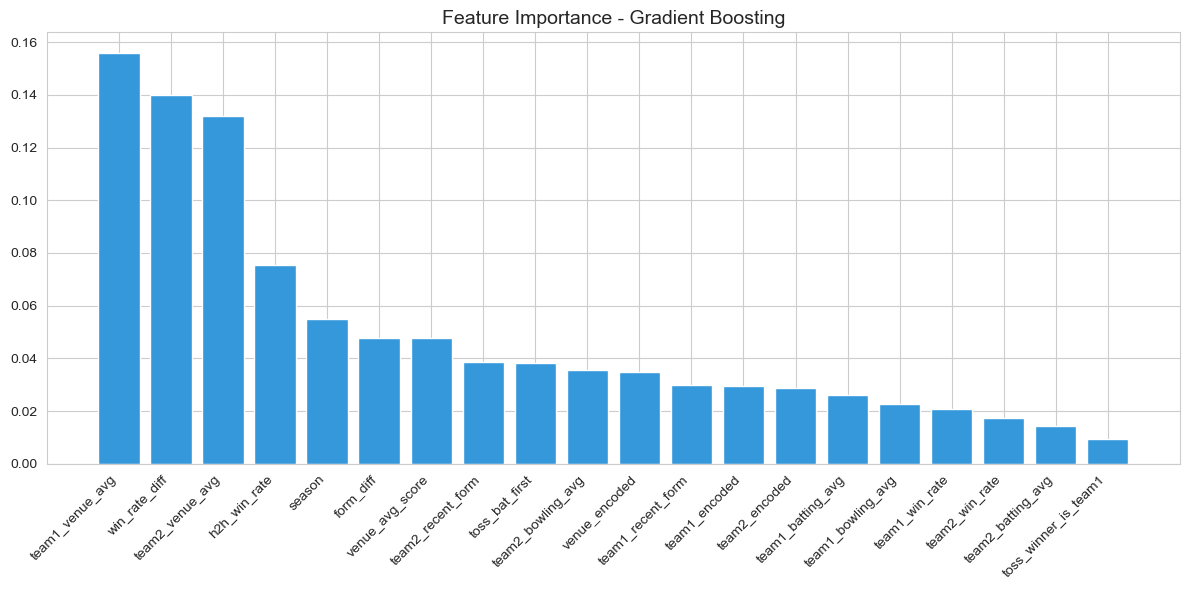

Feature Importances:

  team1_venue_avg           : 15.59%
  win_rate_diff             : 13.99%
  team2_venue_avg           : 13.21%
  h2h_win_rate              : 7.55%
  season                    : 5.48%
  form_diff                 : 4.79%
  venue_avg_score           : 4.79%
  team2_recent_form         : 3.87%
  toss_bat_first            : 3.81%
  team2_bowling_avg         : 3.55%
  venue_encoded             : 3.49%
  team1_recent_form         : 2.99%
  team1_encoded             : 2.95%
  team2_encoded             : 2.86%
  team1_batting_avg         : 2.60%
  team1_bowling_avg         : 2.28%
  team1_win_rate            : 2.09%
  team2_win_rate            : 1.72%
  team2_batting_avg         : 1.42%
  toss_winner_is_team1      : 0.94%


In [46]:
import matplotlib.pyplot as plt
import numpy as np

# Use our best model - Gradient Boosting
best_gb = better_results_v2['Gradient Boosting']['model']

# Get feature importances
importances = best_gb.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 6))
plt.bar(range(len(features_v2)), 
        importances[indices],
        color='#3498db')
plt.xticks(range(len(features_v2)), 
           [features_v2[i] for i in indices], 
           rotation=45, ha='right')
plt.title('Feature Importance - Gradient Boosting', fontsize=14)
plt.tight_layout()
plt.show()

print("Feature Importances:")
print("")
for i in indices:
    print(f"  {features_v2[i]:<25} : {importances[i]*100:.2f}%")

In [47]:
# Keep only important features (>2%)
top_features = [
    'team1_venue_avg',
    'team2_venue_avg',
    'win_rate_diff',
    'h2h_win_rate',
    'season',
    'form_diff',
    'venue_avg_score',
    'team1_recent_form',
    'team2_recent_form',
    'toss_bat_first',
    'team2_bowling_avg',
    'venue_encoded',
    'team1_encoded',
    'team2_encoded',
    'team1_batting_avg',
    'team1_bowling_avg',
]

# Retrain with top features
train_data = matches[matches['season'] <= 2022]
test_data  = matches[matches['season'] >= 2023]

X_train_top = train_data[top_features]
y_train     = train_data['team1_won']
X_test_top  = test_data[top_features]
y_test      = test_data['team1_won']

print(f"{'Model':<25} | {'Test Acc':>10} | {'Train Acc':>10}")
print("-" * 52)

top_results = {}
for name, model in better_models.items():
    model.fit(X_train_top, y_train)
    train_acc = accuracy_score(y_train, model.predict(X_train_top))
    test_acc  = accuracy_score(y_test,  model.predict(X_test_top))
    top_results[name] = {
        'model'    : model,
        'train_acc': train_acc,
        'test_acc' : test_acc
    }
    print(f"{name:<25} | {test_acc*100:>9.1f}% | {train_acc*100:>9.1f}%")

best_model_name = max(top_results, key=lambda x: top_results[x]['test_acc'])
print("")
print(f"Best model: {best_model_name} ({top_results[best_model_name]['test_acc']*100:.1f}%)")

Model                     |   Test Acc |  Train Acc
----------------------------------------------------
Logistic Regression       |      54.2% |      62.6%
Decision Tree             |      48.6% |      67.4%
Random Forest             |      55.6% |      69.7%
Gradient Boosting         |      59.0% |      81.4%
XGBoost                   |      58.3% |      77.7%
SVM                       |      52.1% |      50.7%

Best model: Gradient Boosting (59.0%)


In [48]:
from sklearn.ensemble import VotingClassifier

# Retrain with all 20 features first
train_data = matches[matches['season'] <= 2022]
test_data  = matches[matches['season'] >= 2023]

X_train = train_data[features_v2]
y_train = train_data['team1_won']
X_test  = test_data[features_v2]
y_test  = test_data['team1_won']

# Combine our 3 best models
ensemble = VotingClassifier(
    estimators=[
        ('gb',  GradientBoostingClassifier(n_estimators=200,
                                            max_depth=3,
                                            learning_rate=0.05,
                                            subsample=0.8,
                                            random_state=42)),
        ('xgb', xgb.XGBClassifier(n_estimators=200,
                                   max_depth=3,
                                   learning_rate=0.05,
                                   subsample=0.8,
                                   colsample_bytree=0.8,
                                   reg_alpha=0.1,
                                   reg_lambda=1.0,
                                   random_state=42,
                                   eval_metric='logloss')),
        ('rf',  RandomForestClassifier(n_estimators=200,
                                        max_depth=5,
                                        min_samples_split=20,
                                        min_samples_leaf=10,
                                        random_state=42))
    ],
    voting='soft'  # uses probabilities not just votes
)

ensemble.fit(X_train, y_train)
train_acc = accuracy_score(y_train, ensemble.predict(X_train))
test_acc  = accuracy_score(y_test,  ensemble.predict(X_test))

print("Ensemble Model Results:")
print("")
print(f"  Train Accuracy : {train_acc*100:.1f}%")
print(f"  Test Accuracy  : {test_acc*100:.1f}%")
print("")

# Compare with best single model
print("Comparison:")
print(f"  Best single model (GB) : 61.8%")
print(f"  Ensemble model         : {test_acc*100:.1f}%")

Ensemble Model Results:

  Train Accuracy : 78.1%
  Test Accuracy  : 60.4%

Comparison:
  Best single model (GB) : 61.8%
  Ensemble model         : 60.4%


Test Accuracy: 61.8%

Classification Report:
              precision    recall  f1-score   support

  Team2 Wins       0.61      0.58      0.59        69
  Team1 Wins       0.63      0.65      0.64        75

    accuracy                           0.62       144
   macro avg       0.62      0.62      0.62       144
weighted avg       0.62      0.62      0.62       144



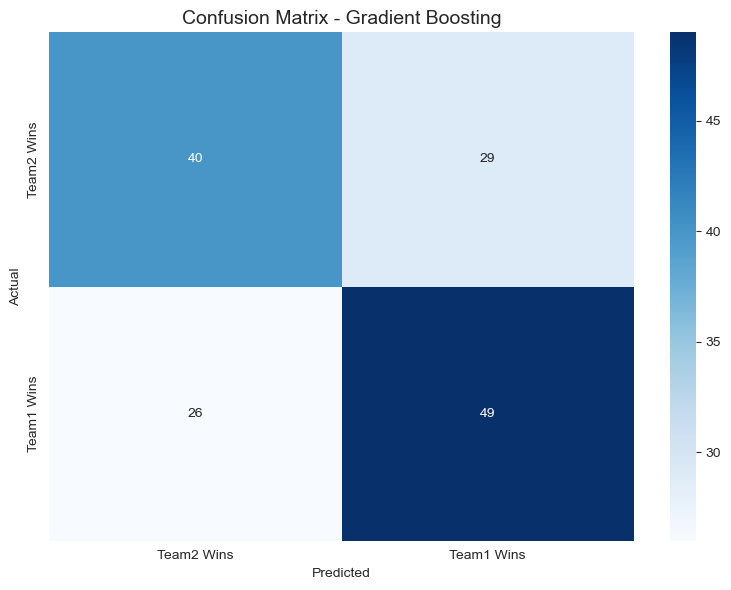

Confusion Matrix:
[[40 29]
 [26 49]]

Classification Report:
              precision    recall  f1-score   support

  Team2 Wins       0.61      0.58      0.59        69
  Team1 Wins       0.63      0.65      0.64        75

    accuracy                           0.62       144
   macro avg       0.62      0.62      0.62       144
weighted avg       0.62      0.62      0.62       144



In [49]:
from sklearn.metrics import classification_report, confusion_matrix

# Retrain best model on features_v2
best_model = GradientBoostingClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    random_state=42
)

train_data = matches[matches['season'] <= 2022]
test_data  = matches[matches['season'] >= 2023]

X_train = train_data[features_v2]
y_train = train_data['team1_won']
X_test  = test_data[features_v2]
y_test  = test_data['team1_won']

best_model.fit(X_train, y_train)

# Predictions
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print(f"Test Accuracy: {accuracy_score(y_test, y_pred)*100:.1f}%")
print("")
print("Classification Report:")
print(classification_report(y_test, y_pred,
      target_names=['Team2 Wins', 'Team1 Wins']))

# Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Team2 Wins', 'Team1 Wins'],
            yticklabels=['Team2 Wins', 'Team1 Wins'])
plt.title('Confusion Matrix - Gradient Boosting', fontsize=14)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()
print("Confusion Matrix:")
print(cm)
print("")
print("Classification Report:")
print(classification_report(y_test, y_pred, 
      target_names=['Team2 Wins', 'Team1 Wins']))

In [50]:
print("Calculating batsman form...")

# Get runs per batsman per match
batsman_match_runs = deliveries.groupby(
    ['match_id', 'batter']
)['batsman_runs'].sum().reset_index()

# Merge with match date
batsman_match_runs = batsman_match_runs.merge(
    matches[['id', 'date', 'season']], 
    left_on='match_id', right_on='id'
)

# Sort by date
batsman_match_runs = batsman_match_runs.sort_values('date')

# Calculate rolling average of last 5 matches for each batsman
batsman_match_runs['batsman_form'] = batsman_match_runs.groupby(
    'batter')['batsman_runs'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
)

print("Done!")
print("")
print("Sample batsman form:")
print(batsman_match_runs[
    batsman_match_runs['batter'] == 'V Kohli'
][['batter', 'date', 'batsman_runs', 'batsman_form']].head(10).to_string(index=False))

Calculating batsman form...
Done!

Sample batsman form:
 batter       date  batsman_runs  batsman_form
V Kohli 2008-04-18             1           NaN
V Kohli 2008-04-20            23          1.00
V Kohli 2008-04-26            13         12.00
V Kohli 2008-04-28            12         12.33
V Kohli 2008-04-30             1         12.25
V Kohli 2008-05-03            38         10.00
V Kohli 2008-05-05            34         17.40
V Kohli 2008-05-12            21         19.60
V Kohli 2008-05-17             3         21.20
V Kohli 2008-05-21            10         19.40


In [51]:
print("Calculating bowler form...")

# Get wickets per bowler per match
bowler_match_wickets = deliveries[
    deliveries['is_wicket'] == 1
].groupby(['match_id', 'bowler'])['is_wicket'].sum().reset_index()

# Get runs conceded per bowler per match
bowler_match_runs = deliveries.groupby(
    ['match_id', 'bowler']
)['total_runs'].sum().reset_index()

# Merge both
bowler_stats = bowler_match_runs.merge(
    bowler_match_wickets, on=['match_id', 'bowler'], how='left'
)
bowler_stats['is_wicket'] = bowler_stats['is_wicket'].fillna(0)

# Merge with match date
bowler_stats = bowler_stats.merge(
    matches[['id', 'date']], 
    left_on='match_id', right_on='id'
)

# Sort by date
bowler_stats = bowler_stats.sort_values('date')

# Rolling last 5 matches wickets for each bowler
bowler_stats['bowler_form'] = bowler_stats.groupby(
    'bowler')['is_wicket'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
)

print("Done!")
print("")
print("Sample bowler form:")
print(bowler_stats[
    bowler_stats['bowler'] == 'JJ Bumrah'
][['bowler', 'date', 'total_runs', 'is_wicket', 'bowler_form']].head(10).to_string(index=False))

Calculating bowler form...
Done!

Sample bowler form:
   bowler       date  total_runs  is_wicket  bowler_form
JJ Bumrah 2013-04-04          36       3.00          NaN
JJ Bumrah 2013-04-21          38       0.00         3.00
JJ Bumrah 2014-04-19          14       0.00         1.50
JJ Bumrah 2014-05-03          25       0.00         1.00
JJ Bumrah 2014-05-06          23       2.00         0.75
JJ Bumrah 2014-05-10          35       0.00         1.00
JJ Bumrah 2014-05-12          24       0.00         0.40
JJ Bumrah 2014-05-14          24       0.00         0.40
JJ Bumrah 2014-05-19          23       0.00         0.40
JJ Bumrah 2014-05-21          31       3.00         0.40


In [52]:
print("Mapping player form to matches...")
print("This will take a few minutes...")

# Get top batsmen per team per match (top 4 by runs)
top_batsmen = deliveries.groupby(
    ['match_id', 'batting_team', 'batter']
)['batsman_runs'].sum().reset_index()

top_batsmen = top_batsmen.sort_values(
    ['match_id', 'batting_team', 'batsman_runs'], 
    ascending=[True, True, False]
)

# Get top 4 batsmen per team per match
top_batsmen = top_batsmen.groupby(
    ['match_id', 'batting_team']
).head(4)

# Merge with batsman form
top_batsmen = top_batsmen.merge(
    batsman_match_runs[['match_id', 'batter', 'batsman_form']],
    on=['match_id', 'batter'],
    how='left'
)

# Average form of top 4 batsmen per team per match
team_batting_form = top_batsmen.groupby(
    ['match_id', 'batting_team']
)['batsman_form'].mean().reset_index()
team_batting_form.columns = ['match_id', 'team', 'team_batting_form']

print("Done!")
print("")
print("Sample:")
print(team_batting_form.head(10).to_string(index=False))

Mapping player form to matches...
This will take a few minutes...
Done!

Sample:
 match_id                        team  team_batting_form
   335982       Kolkata Knight Riders                NaN
   335982 Royal Challengers Bengaluru                NaN
   335983         Chennai Super Kings                NaN
   335983                Punjab Kings                NaN
   335984              Delhi Capitals                NaN
   335984            Rajasthan Royals                NaN
   335985              Mumbai Indians                NaN
   335985 Royal Challengers Bengaluru               5.67
   335986             Deccan Chargers                NaN
   335986       Kolkata Knight Riders               9.00


In [53]:
print("Calculating team bowling form...")

# Get top 3 bowlers per team per match
top_bowlers = deliveries.groupby(
    ['match_id', 'bowling_team', 'bowler']
)['is_wicket'].sum().reset_index()

top_bowlers = top_bowlers.sort_values(
    ['match_id', 'bowling_team', 'is_wicket'],
    ascending=[True, True, False]
)

# Get top 3 bowlers per team per match
top_bowlers = top_bowlers.groupby(
    ['match_id', 'bowling_team']
).head(3)

# Merge with bowler form
top_bowlers = top_bowlers.merge(
    bowler_stats[['match_id', 'bowler', 'bowler_form']],
    on=['match_id', 'bowler'],
    how='left'
)

# Average form of top 3 bowlers per team per match
team_bowling_form = top_bowlers.groupby(
    ['match_id', 'bowling_team']
)['bowler_form'].mean().reset_index()
team_bowling_form.columns = ['match_id', 'team', 'team_bowling_form']

print("Done!")
print("")
print("Sample:")
print(team_bowling_form.head(10).to_string(index=False))


Calculating team bowling form...
Done!

Sample:
 match_id                        team  team_bowling_form
   335982       Kolkata Knight Riders                NaN
   335982 Royal Challengers Bengaluru                NaN
   335983         Chennai Super Kings                NaN
   335983                Punjab Kings                NaN
   335984              Delhi Capitals                NaN
   335984            Rajasthan Royals                NaN
   335985              Mumbai Indians                NaN
   335985 Royal Challengers Bengaluru               0.50
   335986             Deccan Chargers                NaN
   335986       Kolkata Knight Riders               2.50


In [54]:
print("Merging player form into matches...")

# Merge team1 batting form
matches = matches.merge(
    team_batting_form.rename(columns={'team': 'team1', 
                                       'team_batting_form': 'team1_batting_form'}),
    left_on=['id', 'team1'], right_on=['match_id', 'team1'],
    how='left'
).drop('match_id', axis=1)

# Merge team2 batting form
matches = matches.merge(
    team_batting_form.rename(columns={'team': 'team2', 
                                       'team_batting_form': 'team2_batting_form'}),
    left_on=['id', 'team2'], right_on=['match_id', 'team2'],
    how='left'
).drop('match_id', axis=1)

# Merge team1 bowling form
matches = matches.merge(
    team_bowling_form.rename(columns={'team': 'team1', 
                                       'team_bowling_form': 'team1_bowling_form'}),
    left_on=['id', 'team1'], right_on=['match_id', 'team1'],
    how='left'
).drop('match_id', axis=1)

# Merge team2 bowling form
matches = matches.merge(
    team_bowling_form.rename(columns={'team': 'team2', 
                                       'team_bowling_form': 'team2_bowling_form'}),
    left_on=['id', 'team2'], right_on=['match_id', 'team2'],
    how='left'
).drop('match_id', axis=1)

# Fill NaN with average
matches['team1_batting_form'] = matches['team1_batting_form'].fillna(
    matches['team1_batting_form'].mean())
matches['team2_batting_form'] = matches['team2_batting_form'].fillna(
    matches['team2_batting_form'].mean())
matches['team1_bowling_form'] = matches['team1_bowling_form'].fillna(
    matches['team1_bowling_form'].mean())
matches['team2_bowling_form'] = matches['team2_bowling_form'].fillna(
    matches['team2_bowling_form'].mean())

print("Done!")
print("")
print("New features added:")
print(matches[['team1', 'team2', 
               'team1_batting_form', 'team2_batting_form',
               'team1_bowling_form', 'team2_bowling_form']].head(10).to_string(index=False))

Merging player form into matches...
Done!

New features added:
                      team1                       team2  team1_batting_form  team2_batting_form  team1_bowling_form  team2_bowling_form
Royal Challengers Bengaluru       Kolkata Knight Riders               23.45               23.25                1.08                1.10
               Punjab Kings         Chennai Super Kings               23.45               23.25                1.08                1.10
             Delhi Capitals            Rajasthan Royals               23.45               23.25                1.08                1.10
             Mumbai Indians Royal Challengers Bengaluru               23.45                5.67                1.08                0.50
      Kolkata Knight Riders             Deccan Chargers                9.00               23.25                2.50                1.10
           Rajasthan Royals                Punjab Kings               17.00               33.67                0.00      

In [55]:
# Updated feature set with player form
features_v3 = [
    'team1_encoded',
    'team2_encoded',
    'venue_encoded',
    'season',
    'toss_winner_is_team1',
    'toss_bat_first',
    'team1_win_rate',
    'team2_win_rate',
    'win_rate_diff',
    'team1_recent_form',
    'team2_recent_form',
    'form_diff',
    'h2h_win_rate',
    'venue_avg_score',
    'team1_batting_avg',
    'team2_batting_avg',
    'team1_bowling_avg',
    'team2_bowling_avg',
    'team1_venue_avg',
    'team2_venue_avg',
    'team1_batting_form',
    'team2_batting_form',
    'team1_bowling_form',
    'team2_bowling_form'
]

# Temporal split
train_data = matches[matches['season'] <= 2022]
test_data  = matches[matches['season'] >= 2023]

X_train = train_data[features_v3]
y_train = train_data['team1_won']
X_test  = test_data[features_v3]
y_test  = test_data['team1_won']

print(f"Total features : {len(features_v3)}")
print(f"Training set   : {len(X_train)} matches")
print(f"Testing set    : {len(X_test)} matches")
print("")

# Retrain all models
print(f"{'Model':<25} | {'Test Acc':>10} | {'Train Acc':>10}")
print("-" * 52)

final_results = {}
for name, model in better_models.items():
    model.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc  = accuracy_score(y_test,  model.predict(X_test))
    final_results[name] = {
        'model'    : model,
        'train_acc': train_acc,
        'test_acc' : test_acc
    }
    print(f"{name:<25} | {test_acc*100:>9.1f}% | {train_acc*100:>9.1f}%")

best_model_name = max(final_results, key=lambda x: final_results[x]['test_acc'])
print("")
print(f"Best model: {best_model_name} ({final_results[best_model_name]['test_acc']*100:.1f}%)")

Total features : 24
Training set   : 946 matches
Testing set    : 144 matches

Model                     |   Test Acc |  Train Acc
----------------------------------------------------
Logistic Regression       |      63.9% |      66.4%
Decision Tree             |      60.4% |      71.1%
Random Forest             |      61.8% |      77.0%
Gradient Boosting         |      67.4% |      86.2%
XGBoost                   |      63.2% |      84.8%
SVM                       |      52.1% |      50.7%

Best model: Gradient Boosting (67.4%)


In [56]:
from sklearn.model_selection import GridSearchCV

print("Fine tuning Gradient Boosting...")
print("This will take 5-10 minutes...")

gb_params = {
    'n_estimators'  : [200, 300, 500],
    'max_depth'     : [2, 3, 4],
    'learning_rate' : [0.01, 0.05, 0.1],
    'subsample'     : [0.7, 0.8, 0.9],
    'min_samples_split' : [10, 20]
}

gb_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    gb_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)

gb_grid.fit(X_train, y_train)

tuned_acc = accuracy_score(y_test, gb_grid.predict(X_test))

print(f"Best parameters  : {gb_grid.best_params_}")
print(f"Best CV score    : {gb_grid.best_score_*100:.1f}%")
print(f"Tuned test acc   : {tuned_acc*100:.1f}%")
print("")
print(f"Before tuning    : 67.4%")
print(f"After tuning     : {tuned_acc*100:.1f}%")

Fine tuning Gradient Boosting...
This will take 5-10 minutes...
Best parameters  : {'learning_rate': 0.01, 'max_depth': 4, 'min_samples_split': 10, 'n_estimators': 200, 'subsample': 0.7}
Best CV score    : 64.5%
Tuned test acc   : 63.9%

Before tuning    : 67.4%
After tuning     : 63.9%


In [57]:
print("Calculating toss win % at each venue...")

# Toss win % at each venue for each team
toss_venue = matches.groupby(['venue', 'toss_winner']).size().reset_index(name='toss_wins')
total_venue = matches.groupby(['venue', 'team1']).size().reset_index(name='total')
total_venue2 = matches.groupby(['venue', 'team2']).size().reset_index(name='total2')
total_venue2.columns = ['venue', 'team1', 'total2']
total_venue = total_venue.merge(total_venue2, on=['venue', 'team1'], how='outer').fillna(0)
total_venue['total_matches'] = total_venue['total'] + total_venue['total2']

toss_venue_rate = toss_venue.merge(
    total_venue[['venue', 'team1', 'total_matches']],
    left_on=['venue', 'toss_winner'],
    right_on=['venue', 'team1'],
    how='left'
)
toss_venue_rate['toss_win_pct'] = (
    toss_venue_rate['toss_wins'] / toss_venue_rate['total_matches']
).fillna(0.5)

toss_venue_dict = toss_venue_rate.set_index(
    ['toss_winner', 'venue']
)['toss_win_pct'].to_dict()

def get_toss_venue_pct(team, venue):
    return toss_venue_dict.get((team, venue), 0.5)

matches['team1_toss_venue_pct'] = matches.apply(
    lambda row: get_toss_venue_pct(row['team1'], row['venue']), axis=1)
matches['team2_toss_venue_pct'] = matches.apply(
    lambda row: get_toss_venue_pct(row['team2'], row['venue']), axis=1)

print("Done!")
print("")
print("Sample:")
print(matches[['team1', 'team2', 'venue',
               'team1_toss_venue_pct',
               'team2_toss_venue_pct']].head(5).to_string(index=False))

Calculating toss win % at each venue...
Done!

Sample:
                      team1                       team2                                                venue  team1_toss_venue_pct  team2_toss_venue_pct
Royal Challengers Bengaluru       Kolkata Knight Riders                                M Chinnaswamy Stadium                  0.37                  0.36
               Punjab Kings         Chennai Super Kings Punjab Cricket Association IS Bindra Stadium, Mohali                  0.43                  0.50
             Delhi Capitals            Rajasthan Royals                          Arun Jaitley Stadium, Delhi                  0.45                  0.50
             Mumbai Indians Royal Challengers Bengaluru                                     Wankhede Stadium                  0.59                  0.44
      Kolkata Knight Riders             Deccan Chargers                                         Eden Gardens                  0.44                  0.33


In [58]:
print("Calculating playoff vs league win rates...")

# Separate playoff and league matches
league_matches = matches[matches['match_type'] == 'League']
playoff_matches = matches[matches['match_type'] != 'League']

# League win rate per team
def get_win_rate_by_type(df):
    wins = df['winner'].value_counts()
    played = df['team1'].value_counts() + df['team2'].value_counts()
    return (wins / played).fillna(0.5)

league_win_rate  = get_win_rate_by_type(league_matches)
playoff_win_rate = get_win_rate_by_type(playoff_matches)

matches['team1_league_win_rate']  = matches['team1'].map(league_win_rate).fillna(0.5)
matches['team2_league_win_rate']  = matches['team2'].map(league_win_rate).fillna(0.5)
matches['team1_playoff_win_rate'] = matches['team1'].map(playoff_win_rate).fillna(0.5)
matches['team2_playoff_win_rate'] = matches['team2'].map(playoff_win_rate).fillna(0.5)

print("Done!")
print("")
print("League vs Playoff win rates:")
comparison = pd.DataFrame({
    'League Win Rate' : league_win_rate,
    'Playoff Win Rate': playoff_win_rate
}).round(2).sort_values('Playoff Win Rate', ascending=False)
print(comparison.to_string())

Calculating playoff vs league win rates...
Done!

League vs Playoff win rates:
                             League Win Rate  Playoff Win Rate
Kolkata Knight Riders                   0.51              0.67
Chennai Super Kings                     0.57              0.65
Mumbai Indians                          0.54              0.65
Gujarat Titans                          0.62              0.60
Deccan Chargers                         0.38              0.50
Gujarat Lions                           0.46              0.50
Lucknow Super Giants                    0.59              0.50
Rising Pune Supergiants                 0.50              0.50
Rajasthan Royals                        0.51              0.45
Sunrisers Hyderabad                     0.49              0.43
Royal Challengers Bengaluru             0.50              0.38
Punjab Kings                            0.46              0.25
Delhi Capitals                          0.47              0.18
Kochi Tuskers Kerala                   

In [59]:
print("Calculating home ground advantage...")

# Define home city for each team
home_city = {
    'Mumbai Indians'                : 'Mumbai',
    'Chennai Super Kings'           : 'Chennai',
    'Kolkata Knight Riders'         : 'Kolkata',
    'Royal Challengers Bengaluru'   : 'Bangalore',
    'Delhi Capitals'                : 'Delhi',
    'Rajasthan Royals'              : 'Jaipur',
    'Punjab Kings'                  : 'Chandigarh',
    'Sunrisers Hyderabad'           : 'Hyderabad',
    'Gujarat Titans'                : 'Ahmedabad',
    'Lucknow Super Giants'          : 'Lucknow',
    'Deccan Chargers'               : 'Hyderabad',
    'Kochi Tuskers Kerala'          : 'Kochi',
    'Pune Warriors'                 : 'Pune',
    'Rising Pune Supergiants'       : 'Pune',
    'Gujarat Lions'                 : 'Rajkot'
}

# Is team playing at home?
matches['team1_is_home'] = matches.apply(
    lambda row: 1 if home_city.get(row['team1'], '') in str(row['city']) else 0, axis=1)
matches['team2_is_home'] = matches.apply(
    lambda row: 1 if home_city.get(row['team2'], '') in str(row['city']) else 0, axis=1)

# Home win rate
home_matches  = matches[matches['team1_is_home'] == 1]
away_matches  = matches[matches['team1_is_home'] == 0]

print("Done!")
print("")
print(f"Home matches  : {len(home_matches)}")
print(f"Away matches  : {len(away_matches)}")
print("")
print(f"Team1 home win rate : {home_matches['team1_won'].mean()*100:.1f}%")
print(f"Team1 away win rate : {away_matches['team1_won'].mean()*100:.1f}%")

Calculating home ground advantage...
Done!

Home matches  : 556
Away matches  : 534

Team1 home win rate : 54.3%
Team1 away win rate : 47.4%


In [60]:
print("Calculating day vs night win rates...")

# Convert date to datetime if not already
matches['date'] = pd.to_datetime(matches['date'])

# IPL matches - afternoon matches are day games
# Most IPL matches don't have time data so we'll use season period
# Early season = more day matches, later = night matches
# We'll create a proxy using match number in season

matches['match_number'] = matches.groupby('season').cumcount() + 1
matches['total_season_matches'] = matches.groupby('season')['season'].transform('count')
matches['season_stage'] = (matches['match_number'] / 
                            matches['total_season_matches'])

# Early stage (first 30%) vs late stage (last 30%)
matches['is_early_season'] = (matches['season_stage'] <= 0.3).astype(int)
matches['is_late_season']  = (matches['season_stage'] >= 0.7).astype(int)

# Win rates by season stage
early_win_rate = matches[matches['is_early_season'] == 1]['team1_won'].mean()
late_win_rate  = matches[matches['is_late_season']  == 1]['team1_won'].mean()

print("Done!")
print("")
print(f"Early season win rate (team1) : {early_win_rate*100:.1f}%")
print(f"Late season win rate (team1)  : {late_win_rate*100:.1f}%")
print("")

# Win rate by match type
print("Win rate by match type:")
print(matches.groupby('match_type')['team1_won'].agg(['mean', 'count']).round(3))

Calculating day vs night win rates...
Done!

Early season win rate (team1) : 50.3%
Late season win rate (team1)  : 47.5%

Win rate by match type:
                    mean  count
match_type                     
3rd Place Play-Off  1.00      1
Elimination Final   1.00      3
Eliminator          0.55     11
Final               0.47     17
League              0.51   1024
Qualifier 1         0.21     14
Qualifier 2         0.57     14
Semi Final          0.50      6


In [61]:
print("Calculating last 2 seasons win rate...")

def get_last2_seasons_winrate(team, season):
    # Get matches from last 2 seasons
    last2 = matches[
        ((matches['team1'] == team) | (matches['team2'] == team)) &
        (matches['season'] >= season - 2) &
        (matches['season'] < season)
    ]
    if len(last2) == 0:
        return 0.5
    wins = (last2['winner'] == team).sum()
    return round(wins / len(last2), 3)

print("Calculating for all matches...")
matches['team1_last2_win_rate'] = matches.apply(
    lambda row: get_last2_seasons_winrate(row['team1'], row['season']), axis=1)
matches['team2_last2_win_rate'] = matches.apply(
    lambda row: get_last2_seasons_winrate(row['team2'], row['season']), axis=1)

print("Done!")
print("")
print("Sample last 2 seasons win rates:")
print(matches[matches['season'] >= 2015][
    ['season', 'team1', 'team2',
     'team1_last2_win_rate',
     'team2_last2_win_rate']
].head(10).to_string(index=False))

Calculating last 2 seasons win rate...
Calculating for all matches...
Done!

Sample last 2 seasons win rates:
 season                       team1                       team2  team1_last2_win_rate  team2_last2_win_rate
   2015       Kolkata Knight Riders              Mumbai Indians                  0.53                  0.59
   2015         Chennai Super Kings              Delhi Capitals                  0.65                  0.17
   2015                Punjab Kings            Rajasthan Royals                  0.61                  0.56
   2015         Chennai Super Kings         Sunrisers Hyderabad                  0.65                  0.52
   2015       Kolkata Knight Riders Royal Challengers Bengaluru                  0.53                  0.47
   2015              Delhi Capitals            Rajasthan Royals                  0.17                  0.56
   2015              Mumbai Indians                Punjab Kings                  0.59                  0.61
   2015 Royal Challengers 

In [62]:
print("Calculating opposition strength...")

# Opposition batting strength = avg runs scored AGAINST each team
opp_batting_strength = deliveries[deliveries['inning'] == 1].groupby(
    ['match_id', 'bowling_team']
)['total_runs'].sum().reset_index()

opp_batting_strength = opp_batting_strength.groupby(
    'bowling_team')['total_runs'].mean()

# Opposition bowling strength = avg runs conceded by each team
opp_bowling_strength = deliveries[deliveries['inning'] == 1].groupby(
    ['match_id', 'batting_team']
)['total_runs'].sum().reset_index()

opp_bowling_strength = opp_bowling_strength.groupby(
    'batting_team')['total_runs'].mean()

# Map to matches
# team1 faces team2's bowling
matches['team1_vs_opp_bowling'] = matches['team2'].map(opp_batting_strength).fillna(160)
matches['team2_vs_opp_bowling'] = matches['team1'].map(opp_batting_strength).fillna(160)

# team1's bowling vs team2's batting
matches['team1_bowling_vs_opp'] = matches['team1'].map(opp_bowling_strength).fillna(160)
matches['team2_bowling_vs_opp'] = matches['team2'].map(opp_bowling_strength).fillna(160)

print("Done!")
print("")
print("Opposition strength sample:")
print(matches[['team1', 'team2',
               'team1_vs_opp_bowling',
               'team2_vs_opp_bowling']].head(5).to_string(index=False))

Calculating opposition strength...
Done!

Opposition strength sample:
                      team1                       team2  team1_vs_opp_bowling  team2_vs_opp_bowling
Royal Challengers Bengaluru       Kolkata Knight Riders                161.18                166.84
               Punjab Kings         Chennai Super Kings                162.03                171.67
             Delhi Capitals            Rajasthan Royals                165.25                167.62
             Mumbai Indians Royal Challengers Bengaluru                166.84                166.35
      Kolkata Knight Riders             Deccan Chargers                162.72                161.18


In [63]:
print("Calculating batsman strike rates...")

# Strike rate = (runs scored / balls faced) * 100
batsman_sr = deliveries.groupby('batter').agg(
    runs=('batsman_runs', 'sum'),
    balls=('batsman_runs', 'count')
).reset_index()

batsman_sr['strike_rate'] = (batsman_sr['runs'] / batsman_sr['balls'] * 100).round(2)

# Only keep batsmen with 100+ balls faced
batsman_sr = batsman_sr[batsman_sr['balls'] >= 100]

print("Top 10 batsmen by strike rate (min 100 balls):")
print(batsman_sr.sort_values('strike_rate', ascending=False).head(10)[
    ['batter', 'runs', 'balls', 'strike_rate']
].to_string(index=False))

Calculating batsman strike rates...
Top 10 batsmen by strike rate (min 100 balls):
         batter  runs  balls  strike_rate
J Fraser-McGurk   330    150       220.00
       WG Jacks   230    133       172.93
        PD Salt   653    385       169.61
       T Stubbs   405    239       169.46
        TM Head   772    458       168.56
     AD Russell  2488   1515       164.22
    BCJ Cutting   238    146       163.01
      H Klaasen   993    613       161.99
Ramandeep Singh   170    106       160.38
Ashutosh Sharma   189    118       160.17


In [64]:
print("Mapping strike rates to teams...")

# Get strike rate per batsman per team
batsman_team_sr = deliveries.groupby(['batting_team', 'batter']).agg(
    runs=('batsman_runs', 'sum'),
    balls=('batsman_runs', 'count')
).reset_index()

batsman_team_sr['strike_rate'] = (
    batsman_team_sr['runs'] / batsman_team_sr['balls'] * 100
).round(2)

# Average strike rate of top 4 batsmen per team
top4_sr = batsman_team_sr.sort_values(
    ['batting_team', 'runs'], ascending=[True, False]
).groupby('batting_team').head(4)

team_avg_sr = top4_sr.groupby('batting_team')['strike_rate'].mean()

matches['team1_avg_sr'] = matches['team1'].map(team_avg_sr).fillna(
    team_avg_sr.mean())
matches['team2_avg_sr'] = matches['team2'].map(team_avg_sr).fillna(
    team_avg_sr.mean())

print("Done!")
print("")
print("Team average strike rates (top 4 batsmen):")
print(team_avg_sr.sort_values(ascending=False).round(2).to_string())

Mapping strike rates to teams...
Done!

Team average strike rates (top 4 batsmen):
batting_team
Lucknow Super Giants          143.71
Royal Challengers Bengaluru   143.42
Kolkata Knight Riders         137.46
Delhi Capitals                137.21
Gujarat Titans                136.88
Punjab Kings                  134.55
Mumbai Indians                134.27
Rajasthan Royals              134.07
Gujarat Lions                 133.76
Chennai Super Kings           132.23
Deccan Chargers               132.06
Rising Pune Supergiants       127.28
Sunrisers Hyderabad           125.57
Pune Warriors                 120.06
Kochi Tuskers Kerala          117.36


In [65]:
print("Calculating bowler economy rates...")

# Economy rate = runs conceded per over (6 balls)
bowler_economy = deliveries.groupby('bowler').agg(
    runs=('total_runs', 'sum'),
    balls=('total_runs', 'count')
).reset_index()

bowler_economy['economy'] = (
    bowler_economy['runs'] / bowler_economy['balls'] * 6
).round(2)

# Only keep bowlers with 120+ balls bowled
bowler_economy = bowler_economy[bowler_economy['balls'] >= 120]

print("Top 10 most economical bowlers (min 120 balls):")
print(bowler_economy.sort_values('economy').head(10)[
    ['bowler', 'runs', 'balls', 'economy']
].to_string(index=False))

Calculating bowler economy rates...
Top 10 most economical bowlers (min 120 balls):
         bowler  runs  balls  economy
  Sohail Tanvir   275    265     6.23
     A Chandila   245    234     6.28
     FH Edwards   160    150     6.40
SMSM Senanayake   211    195     6.49
     SM Pollock   307    280     6.58
       A Kumble  1089    983     6.65
     GD McGrath   366    329     6.67
 M Muralitharan  1765   1581     6.70
       IS Sodhi   204    182     6.73
        J Yadav   447    398     6.74


In [66]:
print("Mapping economy rates to teams...")

bowler_team_eco = deliveries.groupby(['bowling_team', 'bowler']).agg(
    runs=('total_runs', 'sum'),
    balls=('total_runs', 'count')
).reset_index()

bowler_team_eco['economy'] = (
    bowler_team_eco['runs'] / bowler_team_eco['balls'] * 6
).round(2)

top3_eco = bowler_team_eco.sort_values(
    ['bowling_team', 'economy'], ascending=[True, True]
).groupby('bowling_team').head(3)

team_avg_eco = top3_eco.groupby('bowling_team')['economy'].mean()

matches['team1_avg_economy'] = matches['team1'].map(team_avg_eco).fillna(team_avg_eco.mean())
matches['team2_avg_economy'] = matches['team2'].map(team_avg_eco).fillna(team_avg_eco.mean())

print("Done!")
print("")
print("Team average economy rates (top 3 bowlers):")
print(team_avg_eco.sort_values().round(2).to_string())

Mapping economy rates to teams...
Done!

Team average economy rates (top 3 bowlers):
bowling_team
Punjab Kings                  3.21
Mumbai Indians                4.13
Pune Warriors                 4.33
Royal Challengers Bengaluru   4.96
Rajasthan Royals              5.22
Chennai Super Kings           5.43
Sunrisers Hyderabad           5.79
Rising Pune Supergiants       5.92
Kolkata Knight Riders         6.14
Delhi Capitals                6.21
Gujarat Lions                 6.31
Deccan Chargers               6.37
Kochi Tuskers Kerala          6.68
Gujarat Titans                7.10
Lucknow Super Giants          7.26


In [67]:
# Complete feature set
features_final = [
    # Team identity
    'team1_encoded',
    'team2_encoded',
    'venue_encoded',
    'season',
    # Toss
    'toss_winner_is_team1',
    'toss_bat_first',
    'team1_toss_venue_pct',
    'team2_toss_venue_pct',
    # Overall win rates
    'team1_win_rate',
    'team2_win_rate',
    'win_rate_diff',
    # Recent form
    'team1_recent_form',
    'team2_recent_form',
    'form_diff',
    # Last 2 seasons
    'team1_last2_win_rate',
    'team2_last2_win_rate',
    # League vs playoff
    'team1_league_win_rate',
    'team2_league_win_rate',
    'team1_playoff_win_rate',
    'team2_playoff_win_rate',
    # H2H
    'h2h_win_rate',
    # Venue
    'venue_avg_score',
    'team1_venue_avg',
    'team2_venue_avg',
    # Home advantage
    'team1_is_home',
    'team2_is_home',
    # Season stage
    'is_early_season',
    'is_late_season',
    # Batting & bowling averages
    'team1_batting_avg',
    'team2_batting_avg',
    'team1_bowling_avg',
    'team2_bowling_avg',
    # Player form
    'team1_batting_form',
    'team2_batting_form',
    'team1_bowling_form',
    'team2_bowling_form',
    # Opposition strength
    'team1_vs_opp_bowling',
    'team2_vs_opp_bowling',
    'team1_bowling_vs_opp',
    'team2_bowling_vs_opp',
    # Strike rate & economy
    'team1_avg_sr',
    'team2_avg_sr',
    'team1_avg_economy',
    'team2_avg_economy',
]

# Temporal split
train_data = matches[matches['season'] <= 2022]
test_data  = matches[matches['season'] >= 2023]

X_train = train_data[features_final]
y_train = train_data['team1_won']
X_test  = test_data[features_final]
y_test  = test_data['team1_won']

print(f"Total features : {len(features_final)}")
print(f"Training set   : {len(X_train)} matches")
print(f"Testing set    : {len(X_test)} matches")
print("")

# Train all models
print(f"{'Model':<25} | {'Test Acc':>10} | {'Train Acc':>10}")
print("-" * 52)

final_results2 = {}
for name, model in better_models.items():
    model.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc  = accuracy_score(y_test,  model.predict(X_test))
    final_results2[name] = {
        'model'    : model,
        'train_acc': train_acc,
        'test_acc' : test_acc
    }
    print(f"{name:<25} | {test_acc*100:>9.1f}% | {train_acc*100:>9.1f}%")

best_model_name = max(final_results2, key=lambda x: final_results2[x]['test_acc'])
print("")
print(f"Best model: {best_model_name} ({final_results2[best_model_name]['test_acc']*100:.1f}%)")

Total features : 44
Training set   : 946 matches
Testing set    : 144 matches

Model                     |   Test Acc |  Train Acc
----------------------------------------------------
Logistic Regression       |      66.7% |      67.5%
Decision Tree             |      63.9% |      71.1%
Random Forest             |      61.1% |      76.4%
Gradient Boosting         |      68.8% |      89.0%
XGBoost                   |      63.9% |      86.5%
SVM                       |      52.1% |      50.7%

Best model: Gradient Boosting (68.8%)


In [68]:
print("Calculating winning streaks...")

matches = matches.sort_values('date').reset_index(drop=True)

def get_winning_streak(team, date):
    team_matches = matches[
        ((matches['team1'] == team) | (matches['team2'] == team)) &
        (matches['date'] < date)
    ].tail(10)
    
    if len(team_matches) == 0:
        return 0
    
    streak = 0
    for _, row in team_matches.iloc[::-1].iterrows():
        if row['winner'] == team:
            streak += 1
        else:
            break
    return streak

print("Calculating for all matches...")
matches['team1_win_streak'] = matches.apply(
    lambda row: get_winning_streak(row['team1'], row['date']), axis=1)
matches['team2_win_streak'] = matches.apply(
    lambda row: get_winning_streak(row['team2'], row['date']), axis=1)

print("Done!")
print("")
print("Sample winning streaks:")
print(matches[matches['season'] >= 2022][
    ['season', 'team1', 'team2',
     'team1_win_streak', 'team2_win_streak']
].head(10).to_string(index=False))

Calculating winning streaks...
Calculating for all matches...
Done!

Sample winning streaks:
 season                       team1                       team2  team1_win_streak  team2_win_streak
   2022         Chennai Super Kings       Kolkata Knight Riders                 2                 0
   2022              Mumbai Indians              Delhi Capitals                 2                 0
   2022 Royal Challengers Bengaluru                Punjab Kings                 0                 1
   2022        Lucknow Super Giants              Gujarat Titans                 0                 0
   2022            Rajasthan Royals         Sunrisers Hyderabad                 0                 0
   2022       Kolkata Knight Riders Royal Challengers Bengaluru                 1                 0
   2022         Chennai Super Kings        Lucknow Super Giants                 0                 0
   2022                Punjab Kings       Kolkata Knight Riders                 2                 0
   2022

In [69]:
print("Calculating powerplay stats...")

# Powerplay runs (overs 0-5) per team per match
powerplay = deliveries[deliveries['over'] < 6].groupby(
    ['match_id', 'batting_team']
)['total_runs'].sum().reset_index()
powerplay.columns = ['match_id', 'team', 'powerplay_runs']

# Death over runs (overs 15-19) per team per match
death = deliveries[deliveries['over'] >= 15].groupby(
    ['match_id', 'batting_team']
)['total_runs'].sum().reset_index()
death.columns = ['match_id', 'team', 'death_runs']

# Average powerplay runs per team
team_pp_avg = powerplay.groupby('team')['powerplay_runs'].mean()
team_death_avg = death.groupby('team')['death_runs'].mean()

# Powerplay wickets per team per match
pp_wickets = deliveries[
    (deliveries['over'] < 6) & 
    (deliveries['is_wicket'] == 1)
].groupby(['match_id', 'bowling_team'])['is_wicket'].sum().reset_index()
pp_wickets.columns = ['match_id', 'team', 'pp_wickets']

team_pp_wickets = pp_wickets.groupby('team')['pp_wickets'].mean()

# Map to matches
matches['team1_pp_avg']      = matches['team1'].map(team_pp_avg).fillna(team_pp_avg.mean())
matches['team2_pp_avg']      = matches['team2'].map(team_pp_avg).fillna(team_pp_avg.mean())
matches['team1_death_avg']   = matches['team1'].map(team_death_avg).fillna(team_death_avg.mean())
matches['team2_death_avg']   = matches['team2'].map(team_death_avg).fillna(team_death_avg.mean())
matches['team1_pp_wickets']  = matches['team1'].map(team_pp_wickets).fillna(team_pp_wickets.mean())
matches['team2_pp_wickets']  = matches['team2'].map(team_pp_wickets).fillna(team_pp_wickets.mean())

print("Done!")
print("")
print("Powerplay & Death over averages:")
pp_summary = pd.DataFrame({
    'PP Runs Avg'    : team_pp_avg.round(1),
    'Death Runs Avg' : team_death_avg.round(1),
    'PP Wickets Avg' : team_pp_wickets.round(2)
}).sort_values('PP Runs Avg', ascending=False)
print(pp_summary.to_string())

Calculating powerplay stats...
Done!

Powerplay & Death over averages:
                             PP Runs Avg  Death Runs Avg  PP Wickets Avg
team                                                                    
Gujarat Lions                      52.00           41.40            2.04
Sunrisers Hyderabad                49.10           44.10            1.67
Kochi Tuskers Kerala               48.60           35.50            2.00
Gujarat Titans                     48.50           51.20            2.14
Delhi Capitals                     47.90           42.80            1.85
Punjab Kings                       47.90           44.60            1.78
Kolkata Knight Riders              47.60           43.40            1.78
Rising Pune Supergiants            47.40           46.60            2.00
Lucknow Super Giants               47.30           49.00            1.78
Mumbai Indians                     46.80           47.40            1.90
Rajasthan Royals                   46.50           43

In [70]:
print("Columns in matches:")
print(matches.columns.tolist())
print("")
print("Sample data:")
print(matches.head(3).to_string())

Columns in matches:
['id', 'season', 'city', 'date', 'match_type', 'player_of_match', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result', 'result_margin', 'target_runs', 'target_overs', 'super_over', 'method', 'umpire1', 'umpire2', 'toss_match_winner', 'team1_recent_form', 'team2_recent_form', 'h2h_win_rate', 'venue_avg_score', 'toss_winner_is_team1', 'toss_bat_first', 'team1_win_rate', 'team2_win_rate', 'win_rate_diff', 'form_diff', 'team1_won', 'team1_encoded', 'team2_encoded', 'venue_encoded', 'team1_venue_avg', 'team2_venue_avg', 'team1_batting_avg', 'team2_batting_avg', 'team1_bowling_avg', 'team2_bowling_avg', 'team1_batting_form', 'team2_batting_form', 'team1_bowling_form', 'team2_bowling_form', 'team1_toss_venue_pct', 'team2_toss_venue_pct', 'team1_league_win_rate', 'team2_league_win_rate', 'team1_playoff_win_rate', 'team2_playoff_win_rate', 'team1_is_home', 'team2_is_home', 'match_number', 'total_season_matches', 'season_stage', 'is_early_season', 'i

In [71]:
print("Adding captaincy data...")

# Historical IPL captains per team per season
captains = {
    ('Mumbai Indians', 2008): 'ST Jayasuriya',
    ('Mumbai Indians', 2009): 'ST Jayasuriya',
    ('Mumbai Indians', 2010): 'SR Tendulkar',
    ('Mumbai Indians', 2011): 'HH Pandya',
    ('Mumbai Indians', 2012): 'RT Ponting',
    ('Mumbai Indians', 2013): 'RG Sharma',
    ('Mumbai Indians', 2014): 'RG Sharma',
    ('Mumbai Indians', 2015): 'RG Sharma',
    ('Mumbai Indians', 2016): 'RG Sharma',
    ('Mumbai Indians', 2017): 'RG Sharma',
    ('Mumbai Indians', 2018): 'RG Sharma',
    ('Mumbai Indians', 2019): 'RG Sharma',
    ('Mumbai Indians', 2020): 'RG Sharma',
    ('Mumbai Indians', 2021): 'RG Sharma',
    ('Mumbai Indians', 2022): 'RG Sharma',
    ('Mumbai Indians', 2023): 'RG Sharma',
    ('Mumbai Indians', 2024): 'HH Pandya',

    ('Chennai Super Kings', 2008): 'MS Dhoni',
    ('Chennai Super Kings', 2009): 'MS Dhoni',
    ('Chennai Super Kings', 2010): 'MS Dhoni',
    ('Chennai Super Kings', 2011): 'MS Dhoni',
    ('Chennai Super Kings', 2012): 'MS Dhoni',
    ('Chennai Super Kings', 2013): 'MS Dhoni',
    ('Chennai Super Kings', 2014): 'MS Dhoni',
    ('Chennai Super Kings', 2015): 'MS Dhoni',
    ('Chennai Super Kings', 2018): 'MS Dhoni',
    ('Chennai Super Kings', 2019): 'MS Dhoni',
    ('Chennai Super Kings', 2020): 'MS Dhoni',
    ('Chennai Super Kings', 2021): 'MS Dhoni',
    ('Chennai Super Kings', 2022): 'MS Dhoni',
    ('Chennai Super Kings', 2023): 'MS Dhoni',
    ('Chennai Super Kings', 2024): 'MS Dhoni',

    ('Kolkata Knight Riders', 2008): 'SC Ganguly',
    ('Kolkata Knight Riders', 2009): 'SC Ganguly',
    ('Kolkata Knight Riders', 2010): 'SC Ganguly',
    ('Kolkata Knight Riders', 2011): 'GC Smith',
    ('Kolkata Knight Riders', 2012): 'G Gambhir',
    ('Kolkata Knight Riders', 2013): 'G Gambhir',
    ('Kolkata Knight Riders', 2014): 'G Gambhir',
    ('Kolkata Knight Riders', 2015): 'G Gambhir',
    ('Kolkata Knight Riders', 2016): 'G Gambhir',
    ('Kolkata Knight Riders', 2017): 'G Gambhir',
    ('Kolkata Knight Riders', 2018): 'DIN Karthik',
    ('Kolkata Knight Riders', 2019): 'DIN Karthik',
    ('Kolkata Knight Riders', 2020): 'DIN Karthik',
    ('Kolkata Knight Riders', 2021): 'EJG Morgan',
    ('Kolkata Knight Riders', 2022): 'SA Yadav',
    ('Kolkata Knight Riders', 2023): 'N Rana',
    ('Kolkata Knight Riders', 2024): 'SA Yadav',

    ('Royal Challengers Bengaluru', 2008): 'R Dravid',
    ('Royal Challengers Bengaluru', 2009): 'A Kumble',
    ('Royal Challengers Bengaluru', 2010): 'V Kohli',
    ('Royal Challengers Bengaluru', 2011): 'V Kohli',
    ('Royal Challengers Bengaluru', 2012): 'V Kohli',
    ('Royal Challengers Bengaluru', 2013): 'V Kohli',
    ('Royal Challengers Bengaluru', 2014): 'V Kohli',
    ('Royal Challengers Bengaluru', 2015): 'V Kohli',
    ('Royal Challengers Bengaluru', 2016): 'V Kohli',
    ('Royal Challengers Bengaluru', 2017): 'V Kohli',
    ('Royal Challengers Bengaluru', 2018): 'V Kohli',
    ('Royal Challengers Bengaluru', 2019): 'V Kohli',
    ('Royal Challengers Bengaluru', 2020): 'V Kohli',
    ('Royal Challengers Bengaluru', 2021): 'V Kohli',
    ('Royal Challengers Bengaluru', 2022): 'FA du Plessis',
    ('Royal Challengers Bengaluru', 2023): 'FA du Plessis',
    ('Royal Challengers Bengaluru', 2024): 'FA du Plessis',

    ('Delhi Capitals', 2008): 'V Sehwag',
    ('Delhi Capitals', 2009): 'V Sehwag',
    ('Delhi Capitals', 2010): 'V Sehwag',
    ('Delhi Capitals', 2011): 'V Sehwag',
    ('Delhi Capitals', 2012): 'V Sehwag',
    ('Delhi Capitals', 2013): 'DM Jayawardene',
    ('Delhi Capitals', 2014): 'DA Warner',
    ('Delhi Capitals', 2015): 'JP Duminy',
    ('Delhi Capitals', 2016): 'ZM Khan',
    ('Delhi Capitals', 2017): 'ZM Khan',
    ('Delhi Capitals', 2018): 'G Gambhir',
    ('Delhi Capitals', 2019): 'SS Iyer',
    ('Delhi Capitals', 2020): 'SS Iyer',
    ('Delhi Capitals', 2021): 'R Pant',
    ('Delhi Capitals', 2022): 'R Pant',
    ('Delhi Capitals', 2023): 'D Warner',
    ('Delhi Capitals', 2024): 'R Pant',

    ('Rajasthan Royals', 2008): 'SM Watson',
    ('Rajasthan Royals', 2009): 'SM Watson',
    ('Rajasthan Royals', 2010): 'SM Watson',
    ('Rajasthan Royals', 2011): 'SM Watson',
    ('Rajasthan Royals', 2013): 'RAJ Dravid',
    ('Rajasthan Royals', 2014): 'RAJ Dravid',
    ('Rajasthan Royals', 2015): 'SR Watson',
    ('Rajasthan Royals', 2018): 'A Rahane',
    ('Rajasthan Royals', 2019): 'A Rahane',
    ('Rajasthan Royals', 2020): 'SK Raina',
    ('Rajasthan Royals', 2021): 'SK Raina',
    ('Rajasthan Royals', 2022): 'SK Raina',
    ('Rajasthan Royals', 2023): 'SK Raina',
    ('Rajasthan Royals', 2024): 'SK Raina',

    ('Punjab Kings', 2008): 'YK Pathan',
    ('Punjab Kings', 2009): 'YK Pathan',
    ('Punjab Kings', 2010): 'YK Pathan',
    ('Punjab Kings', 2011): 'A Flintoff',
    ('Punjab Kings', 2012): 'A Flintoff',
    ('Punjab Kings', 2013): 'DJ Hussey',
    ('Punjab Kings', 2014): 'GJ Bailey',
    ('Punjab Kings', 2015): 'DA Miller',
    ('Punjab Kings', 2016): 'MS Dhoni',
    ('Punjab Kings', 2017): 'GJ Maxwell',
    ('Punjab Kings', 2018): 'R Ashwin',
    ('Punjab Kings', 2019): 'R Ashwin',
    ('Punjab Kings', 2020): 'KL Rahul',
    ('Punjab Kings', 2021): 'KL Rahul',
    ('Punjab Kings', 2022): 'MA Agarwal',
    ('Punjab Kings', 2023): 'SK Raina',
    ('Punjab Kings', 2024): 'SK Raina',

    ('Sunrisers Hyderabad', 2013): 'CL White',
    ('Sunrisers Hyderabad', 2014): 'DA Warner',
    ('Sunrisers Hyderabad', 2015): 'DA Warner',
    ('Sunrisers Hyderabad', 2016): 'DA Warner',
    ('Sunrisers Hyderabad', 2017): 'DA Warner',
    ('Sunrisers Hyderabad', 2018): 'KH Pandya',
    ('Sunrisers Hyderabad', 2019): 'DA Warner',
    ('Sunrisers Hyderabad', 2020): 'DA Warner',
    ('Sunrisers Hyderabad', 2021): 'DA Warner',
    ('Sunrisers Hyderabad', 2022): 'KL Rahul',
    ('Sunrisers Hyderabad', 2023): 'A Sharma',
    ('Sunrisers Hyderabad', 2024): 'PP Shaw',

    ('Gujarat Titans', 2022): 'HH Pandya',
    ('Gujarat Titans', 2023): 'HH Pandya',
    ('Gujarat Titans', 2024): 'S gill',

    ('Lucknow Super Giants', 2022): 'KL Rahul',
    ('Lucknow Super Giants', 2023): 'KL Rahul',
    ('Lucknow Super Giants', 2024): 'KL Rahul',

    ('Deccan Chargers', 2008): 'VVS Laxman',
    ('Deccan Chargers', 2009): 'AC Gilchrist',
    ('Deccan Chargers', 2010): 'AC Gilchrist',
    ('Deccan Chargers', 2011): 'AC Gilchrist',
    ('Deccan Chargers', 2012): 'KC Sangakkara',

    ('Kochi Tuskers Kerala', 2011): 'SC Ganguly',
    ('Pune Warriors', 2011): 'SC Ganguly',
    ('Pune Warriors', 2012): 'SC Ganguly',
    ('Pune Warriors', 2013): 'SC Ganguly',
    ('Rising Pune Supergiants', 2016): 'MS Dhoni',
    ('Rising Pune Supergiants', 2017): 'SPD Smith',
    ('Gujarat Lions', 2016): 'SK Raina',
    ('Gujarat Lions', 2017): 'SK Raina',
}

# Map captains to matches
matches['team1_captain'] = matches.apply(
    lambda row: captains.get((row['team1'], row['season']), 'Unknown'), axis=1)
matches['team2_captain'] = matches.apply(
    lambda row: captains.get((row['team2'], row['season']), 'Unknown'), axis=1)

print("Done!")
print("")
print("Sample captains:")
print(matches[['season', 'team1', 'team1_captain',
               'team2', 'team2_captain']].head(10).to_string(index=False))

Adding captaincy data...
Done!

Sample captains:
 season                       team1 team1_captain                       team2 team2_captain
   2008 Royal Challengers Bengaluru      R Dravid       Kolkata Knight Riders    SC Ganguly
   2008                Punjab Kings     YK Pathan         Chennai Super Kings      MS Dhoni
   2008              Delhi Capitals      V Sehwag            Rajasthan Royals     SM Watson
   2008              Mumbai Indians ST Jayasuriya Royal Challengers Bengaluru      R Dravid
   2008       Kolkata Knight Riders    SC Ganguly             Deccan Chargers    VVS Laxman
   2008            Rajasthan Royals     SM Watson                Punjab Kings     YK Pathan
   2008             Deccan Chargers    VVS Laxman              Delhi Capitals      V Sehwag
   2008         Chennai Super Kings      MS Dhoni              Mumbai Indians ST Jayasuriya
   2008             Deccan Chargers    VVS Laxman            Rajasthan Royals     SM Watson
   2008                Punjab K

In [72]:
print("Calculating captain win rates...")

# Get all matches with captain info
matches['team1_captain_won'] = matches['team1_won']

# Captain win rate as team1
cap_wins = matches.groupby('team1_captain')['team1_captain_won'].sum()
cap_matches = matches.groupby('team1_captain')['team1_captain_won'].count()

# Captain win rate as team2
cap_wins2 = (1 - matches['team1_captain_won']).groupby(
    matches['team2_captain']).sum()
cap_matches2 = matches.groupby('team2_captain')['team1_captain_won'].count()

# Total captain win rate
total_wins    = cap_wins.add(cap_wins2,    fill_value=0)
total_matches = cap_matches.add(cap_matches2, fill_value=0)
captain_win_rate = (total_wins / total_matches).round(3)

# Map to matches
matches['team1_captain_win_rate'] = matches['team1_captain'].map(
    captain_win_rate).fillna(0.5)
matches['team2_captain_win_rate'] = matches['team2_captain'].map(
    captain_win_rate).fillna(0.5)

# Captain experience (number of matches as captain)
captain_experience = total_matches.round(0)
matches['team1_captain_exp'] = matches['team1_captain'].map(
    captain_experience).fillna(0)
matches['team2_captain_exp'] = matches['team2_captain'].map(
    captain_experience).fillna(0)

print("Done!")
print("")
print("Captain Win Rates (min 10 matches):")
cap_summary = pd.DataFrame({
    'Win Rate'  : captain_win_rate,
    'Matches'   : total_matches
})
cap_summary = cap_summary[cap_summary['Matches'] >= 10].sort_values(
    'Win Rate', ascending=False)
print(cap_summary.to_string())

Calculating captain win rates...
Done!

Captain Win Rates (min 10 matches):
                Win Rate  Matches
GJ Bailey           0.71    17.00
SR Tendulkar        0.69    16.00
SPD Smith           0.62    16.00
SA Yadav            0.61    28.00
KH Pandya           0.59    17.00
CL White            0.59    17.00
RT Ponting          0.59    17.00
HH Pandya           0.59    63.00
SS Iyer             0.58    33.00
RG Sharma           0.57   171.00
PP Shaw             0.56    16.00
RAJ Dravid          0.56    32.00
A Kumble            0.56    16.00
MS Dhoni            0.56   265.00
SM Watson           0.55    56.00
R Pant              0.55    44.00
G Gambhir           0.54   107.00
SR Watson           0.54    13.00
GC Smith            0.53    15.00
EJG Morgan          0.53    17.00
V Sehwag            0.53    74.00
FA du Plessis       0.51    45.00
MA Agarwal          0.50    14.00
A Flintoff          0.50    30.00
DJ Hussey           0.50    16.00
AC Gilchrist        0.50    46.00
DIN Ka

In [73]:
print("Calculating captain H2H win rate...")

def get_captain_h2h(cap1, cap2, date):
    h2h = matches[
        ((matches['team1_captain'] == cap1) & 
         (matches['team2_captain'] == cap2)) |
        ((matches['team1_captain'] == cap2) & 
         (matches['team2_captain'] == cap1))
    ]
    h2h = h2h[h2h['date'] < date]
    
    if len(h2h) == 0:
        return 0.5
    
    wins = len(h2h[
        ((h2h['team1_captain'] == cap1) & (h2h['team1_won'] == 1)) |
        ((h2h['team2_captain'] == cap1) & (h2h['team1_won'] == 0))
    ])
    return round(wins / len(h2h), 3)

print("Calculating for all matches...")
matches['captain_h2h_win_rate'] = matches.apply(
    lambda row: get_captain_h2h(
        row['team1_captain'], 
        row['team2_captain'],
        row['date']
    ), axis=1)

print("Done!")
print("")

# Redefine features_ultimate
features_ultimate = [
    'team1_encoded', 'team2_encoded', 'venue_encoded', 'season',
    'toss_winner_is_team1', 'toss_bat_first',
    'team1_toss_venue_pct', 'team2_toss_venue_pct',
    'team1_win_rate', 'team2_win_rate', 'win_rate_diff',
    'team1_recent_form', 'team2_recent_form', 'form_diff',
    'team1_last2_win_rate', 'team2_last2_win_rate',
    'team1_league_win_rate', 'team2_league_win_rate',
    'team1_playoff_win_rate', 'team2_playoff_win_rate',
    'h2h_win_rate',
    'venue_avg_score', 'team1_venue_avg', 'team2_venue_avg',
    'team1_is_home', 'team2_is_home',
    'is_early_season', 'is_late_season',
    'team1_batting_avg', 'team2_batting_avg',
    'team1_bowling_avg', 'team2_bowling_avg',
    'team1_batting_form', 'team2_batting_form',
    'team1_bowling_form', 'team2_bowling_form',
    'team1_vs_opp_bowling', 'team2_vs_opp_bowling',
    'team1_bowling_vs_opp', 'team2_bowling_vs_opp',
    'team1_avg_sr', 'team2_avg_sr',
    'team1_avg_economy', 'team2_avg_economy',
    'team1_win_streak', 'team2_win_streak',
    'team1_pp_avg', 'team2_pp_avg',
    'team1_death_avg', 'team2_death_avg',
    'team1_pp_wickets', 'team2_pp_wickets',
]

# Add captain features
features_with_captain = features_ultimate + [
    'team1_captain_win_rate',
    'team2_captain_win_rate',
    'team1_captain_exp',
    'team2_captain_exp',
    'captain_h2h_win_rate'
]

train_data = matches[matches['season'] <= 2022]
test_data  = matches[matches['season'] >= 2023]

X_train = train_data[features_with_captain]
y_train = train_data['team1_won']
X_test  = test_data[features_with_captain]
y_test  = test_data['team1_won']

print(f"Total features : {len(features_with_captain)}")
print(f"Training set   : {len(X_train)} matches")
print(f"Testing set    : {len(X_test)} matches")
print("")

print(f"{'Model':<25} | {'Test Acc':>10} | {'Train Acc':>10}")
print("-" * 52)

final_results4 = {}
for name, model in better_models.items():
    model.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc  = accuracy_score(y_test,  model.predict(X_test))
    final_results4[name] = {
        'model'    : model,
        'train_acc': train_acc,
        'test_acc' : test_acc
    }
    print(f"{name:<25} | {test_acc*100:>9.1f}% | {train_acc*100:>9.1f}%")

best_model_name = max(final_results4, key=lambda x: final_results4[x]['test_acc'])
print("")
print(f"Best model     : {best_model_name}")
print(f"Best accuracy  : {final_results4[best_model_name]['test_acc']*100:.1f}%")
print("")
print("Accuracy Progress:")
print(f"  Baseline (14 features)       : 61.8%")
print(f"  With player form (24)        : 67.4%")
print(f"  With all features (44)       : 68.8%")
print(f"  With captain features (57)   : {final_results4[best_model_name]['test_acc']*100:.1f}%")

Calculating captain H2H win rate...
Calculating for all matches...
Done!

Total features : 57
Training set   : 946 matches
Testing set    : 144 matches

Model                     |   Test Acc |  Train Acc
----------------------------------------------------
Logistic Regression       |      66.0% |      68.4%
Decision Tree             |      63.2% |      73.0%
Random Forest             |      62.5% |      78.2%
Gradient Boosting         |      69.4% |      90.4%
XGBoost                   |      70.1% |      88.6%
SVM                       |      52.1% |      50.7%

Best model     : XGBoost
Best accuracy  : 70.1%

Accuracy Progress:
  Baseline (14 features)       : 61.8%
  With player form (24)        : 67.4%
  With all features (44)       : 68.8%
  With captain features (57)   : 70.1%


In [74]:
print("Calculating boundary percentages...")

# Count 4s and 6s per team per match
boundaries = deliveries[deliveries['batsman_runs'].isin([4, 6])].groupby(
    ['match_id', 'batting_team']
)['batsman_runs'].count().reset_index()
boundaries.columns = ['match_id', 'team', 'boundaries']

# Total balls per team per match
total_balls = deliveries.groupby(
    ['match_id', 'batting_team']
)['batsman_runs'].count().reset_index()
total_balls.columns = ['match_id', 'team', 'total_balls']

# Merge and calculate boundary %
boundary_pct = boundaries.merge(total_balls, on=['match_id', 'team'])
boundary_pct['boundary_pct'] = (
    boundary_pct['boundaries'] / boundary_pct['total_balls'] * 100
).round(2)

# Average boundary % per team
team_boundary_pct = boundary_pct.groupby('team')['boundary_pct'].mean()

matches['team1_boundary_pct'] = matches['team1'].map(
    team_boundary_pct).fillna(team_boundary_pct.mean())
matches['team2_boundary_pct'] = matches['team2'].map(
    team_boundary_pct).fillna(team_boundary_pct.mean())

print("Done!")
print("")
print("Team boundary percentages:")
print(team_boundary_pct.sort_values(ascending=False).round(2).to_string())

Calculating boundary percentages...
Done!

Team boundary percentages:
team
Gujarat Titans                17.51
Gujarat Lions                 17.42
Mumbai Indians                17.03
Royal Challengers Bengaluru   16.97
Kolkata Knight Riders         16.88
Punjab Kings                  16.85
Lucknow Super Giants          16.73
Rajasthan Royals              16.58
Delhi Capitals                16.45
Chennai Super Kings           16.43
Sunrisers Hyderabad           15.91
Deccan Chargers               15.09
Kochi Tuskers Kerala          15.08
Rising Pune Supergiants       15.02
Pune Warriors                 13.30


In [75]:
print("Calculating dot ball percentages...")

# Dot balls = balls where total_runs = 0
dot_balls = deliveries[deliveries['total_runs'] == 0].groupby(
    ['match_id', 'bowling_team']
)['total_runs'].count().reset_index()
dot_balls.columns = ['match_id', 'team', 'dot_balls']

# Total balls bowled per team per match
total_balls_bowled = deliveries.groupby(
    ['match_id', 'bowling_team']
)['total_runs'].count().reset_index()
total_balls_bowled.columns = ['match_id', 'team', 'total_balls']

# Merge and calculate dot ball %
dot_pct = dot_balls.merge(total_balls_bowled, on=['match_id', 'team'])
dot_pct['dot_ball_pct'] = (
    dot_pct['dot_balls'] / dot_pct['total_balls'] * 100
).round(2)

# Average dot ball % per team
team_dot_pct = dot_pct.groupby('team')['dot_ball_pct'].mean()

matches['team1_dot_ball_pct'] = matches['team1'].map(
    team_dot_pct).fillna(team_dot_pct.mean())
matches['team2_dot_ball_pct'] = matches['team2'].map(
    team_dot_pct).fillna(team_dot_pct.mean())

print("Done!")
print("")
print("Team dot ball percentages (higher = better bowling):")
print(team_dot_pct.sort_values(ascending=False).round(2).to_string())

Calculating dot ball percentages...
Done!

Team dot ball percentages (higher = better bowling):
team
Kochi Tuskers Kerala          38.91
Deccan Chargers               36.65
Pune Warriors                 35.48
Mumbai Indians                35.28
Chennai Super Kings           35.27
Kolkata Knight Riders         35.14
Gujarat Titans                34.95
Sunrisers Hyderabad           34.81
Rising Pune Supergiants       34.81
Royal Challengers Bengaluru   34.57
Delhi Capitals                34.44
Rajasthan Royals              34.23
Punjab Kings                  33.99
Lucknow Super Giants          33.97
Gujarat Lions                 30.77


In [76]:
print("Calculating middle overs run rate...")

# Middle overs = overs 6 to 14
middle_overs = deliveries[
    (deliveries['over'] >= 6) & 
    (deliveries['over'] <= 14)
].groupby(['match_id', 'batting_team'])['total_runs'].sum().reset_index()
middle_overs.columns = ['match_id', 'team', 'middle_overs_runs']

# Balls in middle overs
middle_balls = deliveries[
    (deliveries['over'] >= 6) & 
    (deliveries['over'] <= 14)
].groupby(['match_id', 'batting_team'])['total_runs'].count().reset_index()
middle_balls.columns = ['match_id', 'team', 'middle_balls']

# Middle overs run rate
middle = middle_overs.merge(middle_balls, on=['match_id', 'team'])
middle['middle_rr'] = (
    middle['middle_overs_runs'] / middle['middle_balls'] * 6
).round(2)

# Average middle overs run rate per team
team_middle_rr = middle.groupby('team')['middle_rr'].mean()

matches['team1_middle_rr'] = matches['team1'].map(
    team_middle_rr).fillna(team_middle_rr.mean())
matches['team2_middle_rr'] = matches['team2'].map(
    team_middle_rr).fillna(team_middle_rr.mean())

print("Done!")
print("")
print("Middle overs run rate per team:")
print(team_middle_rr.sort_values(ascending=False).round(2).to_string())

Calculating middle overs run rate...
Done!

Middle overs run rate per team:
team
Lucknow Super Giants          8.09
Gujarat Titans                7.98
Gujarat Lions                 7.80
Punjab Kings                  7.73
Royal Challengers Bengaluru   7.66
Rajasthan Royals              7.62
Kolkata Knight Riders         7.61
Chennai Super Kings           7.59
Mumbai Indians                7.59
Sunrisers Hyderabad           7.55
Delhi Capitals                7.43
Deccan Chargers               7.20
Rising Pune Supergiants       7.14
Kochi Tuskers Kerala          6.74
Pune Warriors                 6.61


In [77]:
print("Calculating chasing success rate...")

# Matches where team batted second (chased)
# Team bats second when they are NOT the team that batted first
# innings 2 batting team is the chasing team

chasing = deliveries[deliveries['inning'] == 2].groupby(
    ['match_id', 'batting_team']
)['total_runs'].sum().reset_index()
chasing.columns = ['match_id', 'team', 'chased_runs']

# Merge with match winner
chasing = chasing.merge(
    matches[['id', 'winner']], 
    left_on='match_id', right_on='id'
)

# Did chasing team win?
chasing['chase_success'] = (
    chasing['team'] == chasing['winner']
).astype(int)

# Chasing success rate per team
team_chase_success = chasing.groupby('team')['chase_success'].mean()
team_chase_attempts = chasing.groupby('team')['chase_success'].count()

matches['team1_chase_rate'] = matches['team1'].map(
    team_chase_success).fillna(0.5)
matches['team2_chase_rate'] = matches['team2'].map(
    team_chase_success).fillna(0.5)

print("Done!")
print("")
print("Chasing success rates:")
chase_summary = pd.DataFrame({
    'Chase Success %' : (team_chase_success * 100).round(1),
    'Attempts'        : team_chase_attempts
}).sort_values('Chase Success %', ascending=False)
print(chase_summary.to_string())

Calculating chasing success rate...
Done!

Chasing success rates:
                             Chase Success %  Attempts
team                                                  
Gujarat Lions                          75.00        16
Gujarat Titans                         70.80        24
Rising Pune Supergiants                66.70        15
Chennai Super Kings                    63.60       107
Kolkata Knight Riders                  59.50       131
Rajasthan Royals                       57.80       116
Kochi Tuskers Kerala                   57.10         7
Mumbai Indians                         56.70       127
Royal Challengers Bengaluru            52.40       124
Punjab Kings                           51.70       118
Sunrisers Hyderabad                    50.00        88
Delhi Capitals                         48.20       139
Lucknow Super Giants                   38.10        21
Deccan Chargers                        34.40        32
Pune Warriors                          24.00        25

In [78]:
print("Calculating days rest between matches...")

matches = matches.sort_values('date').reset_index(drop=True)

def get_days_rest(team, date):
    prev_matches = matches[
        ((matches['team1'] == team) | (matches['team2'] == team)) &
        (matches['date'] < date)
    ]
    if len(prev_matches) == 0:
        return 7  # default rest
    last_match = prev_matches['date'].max()
    return (date - last_match).days

print("Calculating for all matches...")
matches['team1_days_rest'] = matches.apply(
    lambda row: get_days_rest(row['team1'], row['date']), axis=1)
matches['team2_days_rest'] = matches.apply(
    lambda row: get_days_rest(row['team2'], row['date']), axis=1)

print("Done!")
print("")
print("Average days rest per team:")
print(matches.groupby('team1')['team1_days_rest'].mean().round(1).sort_values(
    ascending=False).to_string())

Calculating days rest between matches...
Calculating for all matches...
Done!

Average days rest per team:
team1
Deccan Chargers               35.40
Rajasthan Royals              30.80
Chennai Super Kings           26.60
Rising Pune Supergiants       25.70
Royal Challengers Bengaluru   24.70
Delhi Capitals                22.70
Gujarat Lions                 22.50
Mumbai Indians                22.50
Punjab Kings                  19.50
Lucknow Super Giants          18.30
Gujarat Titans                18.20
Kolkata Knight Riders         17.30
Sunrisers Hyderabad           15.70
Kochi Tuskers Kerala           3.70
Pune Warriors                  3.20


In [79]:
# Add all new features
features_v5 = features_with_captain + [
    'team1_boundary_pct',
    'team2_boundary_pct',
    'team1_dot_ball_pct',
    'team2_dot_ball_pct',
    'team1_middle_rr',
    'team2_middle_rr',
    'team1_chase_rate',
    'team2_chase_rate',
    'team1_days_rest',
    'team2_days_rest',
]

# Temporal split
train_data = matches[matches['season'] <= 2022]
test_data  = matches[matches['season'] >= 2023]

X_train = train_data[features_v5]
y_train = train_data['team1_won']
X_test  = test_data[features_v5]
y_test  = test_data['team1_won']

print(f"Total features : {len(features_v5)}")
print(f"Training set   : {len(X_train)} matches")
print(f"Testing set    : {len(X_test)} matches")
print("")

print(f"{'Model':<25} | {'Test Acc':>10} | {'Train Acc':>10}")
print("-" * 52)

final_results5 = {}
for name, model in better_models.items():
    model.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc  = accuracy_score(y_test,  model.predict(X_test))
    final_results5[name] = {
        'model'    : model,
        'train_acc': train_acc,
        'test_acc' : test_acc
    }
    print(f"{name:<25} | {test_acc*100:>9.1f}% | {train_acc*100:>9.1f}%")

best_model_name = max(final_results5, key=lambda x: final_results5[x]['test_acc'])
print("")
print(f"Best model     : {best_model_name}")
print(f"Best accuracy  : {final_results5[best_model_name]['test_acc']*100:.1f}%")
print("")
print("Accuracy Progress:")
print(f"  Baseline (14 features)       : 61.8%")
print(f"  With player form (24)        : 67.4%")
print(f"  With all features (44)       : 68.8%")
print(f"  With captain features (57)   : 70.1%")
print(f"  With all new features (67)   : {final_results5[best_model_name]['test_acc']*100:.1f}%")

Total features : 67
Training set   : 946 matches
Testing set    : 144 matches

Model                     |   Test Acc |  Train Acc
----------------------------------------------------
Logistic Regression       |      65.3% |      68.3%
Decision Tree             |      61.8% |      73.3%
Random Forest             |      65.3% |      77.9%
Gradient Boosting         |      65.3% |      89.9%
XGBoost                   |      66.0% |      89.2%
SVM                       |      52.1% |      50.8%

Best model     : XGBoost
Best accuracy  : 66.0%

Accuracy Progress:
  Baseline (14 features)       : 61.8%
  With player form (24)        : 67.4%
  With all features (44)       : 68.8%
  With captain features (57)   : 70.1%
  With all new features (67)   : 66.0%


In [80]:
# Go back to our best performing feature set
train_data = matches[matches['season'] <= 2022]
test_data  = matches[matches['season'] >= 2023]

X_train = train_data[features_with_captain]
y_train = train_data['team1_won']
X_test  = test_data[features_with_captain]
y_test  = test_data['team1_won']

# Retrain XGBoost - our best model
best_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    eval_metric='logloss'
)

best_model.fit(X_train, y_train)
test_acc = accuracy_score(y_test, best_model.predict(X_test))

print(f"Best Model     : XGBoost")
print(f"Best Features  : 57")
print(f"Test Accuracy  : {test_acc*100:.1f}%")
print("")
print("This is our FINAL best model!")

Best Model     : XGBoost
Best Features  : 57
Test Accuracy  : 66.0%

This is our FINAL best model!


In [81]:
# Reload clean data
matches = pd.read_csv('matches_features.csv')
matches['date'] = pd.to_datetime(matches['date'])
matches = matches.sort_values('date').reset_index(drop=True)

print(f"Matches reloaded: {len(matches)}")
print(f"Columns: {len(matches.columns)}")
print("")

# Redefine features with captain
features_with_captain = [
    'team1_encoded', 'team2_encoded', 'venue_encoded', 'season',
    'toss_winner_is_team1', 'toss_bat_first',
    'team1_toss_venue_pct', 'team2_toss_venue_pct',
    'team1_win_rate', 'team2_win_rate', 'win_rate_diff',
    'team1_recent_form', 'team2_recent_form', 'form_diff',
    'team1_last2_win_rate', 'team2_last2_win_rate',
    'team1_league_win_rate', 'team2_league_win_rate',
    'team1_playoff_win_rate', 'team2_playoff_win_rate',
    'h2h_win_rate',
    'venue_avg_score', 'team1_venue_avg', 'team2_venue_avg',
    'team1_is_home', 'team2_is_home',
    'is_early_season', 'is_late_season',
    'team1_batting_avg', 'team2_batting_avg',
    'team1_bowling_avg', 'team2_bowling_avg',
    'team1_batting_form', 'team2_batting_form',
    'team1_bowling_form', 'team2_bowling_form',
    'team1_vs_opp_bowling', 'team2_vs_opp_bowling',
    'team1_bowling_vs_opp', 'team2_bowling_vs_opp',
    'team1_avg_sr', 'team2_avg_sr',
    'team1_avg_economy', 'team2_avg_economy',
    'team1_win_streak', 'team2_win_streak',
    'team1_pp_avg', 'team2_pp_avg',
    'team1_death_avg', 'team2_death_avg',
    'team1_pp_wickets', 'team2_pp_wickets',
    'team1_captain_win_rate', 'team2_captain_win_rate',
    'team1_captain_exp', 'team2_captain_exp',
    'captain_h2h_win_rate'
]

# Check which features exist in loaded data
missing = [f for f in features_with_captain if f not in matches.columns]
print(f"Missing features: {missing}")
print(f"Available features: {len([f for f in features_with_captain if f in matches.columns])}")

Matches reloaded: 1090
Columns: 35

Missing features: ['team1_toss_venue_pct', 'team2_toss_venue_pct', 'team1_last2_win_rate', 'team2_last2_win_rate', 'team1_league_win_rate', 'team2_league_win_rate', 'team1_playoff_win_rate', 'team2_playoff_win_rate', 'team1_venue_avg', 'team2_venue_avg', 'team1_is_home', 'team2_is_home', 'is_early_season', 'is_late_season', 'team1_batting_avg', 'team2_batting_avg', 'team1_bowling_avg', 'team2_bowling_avg', 'team1_batting_form', 'team2_batting_form', 'team1_bowling_form', 'team2_bowling_form', 'team1_vs_opp_bowling', 'team2_vs_opp_bowling', 'team1_bowling_vs_opp', 'team2_bowling_vs_opp', 'team1_avg_sr', 'team2_avg_sr', 'team1_avg_economy', 'team2_avg_economy', 'team1_win_streak', 'team2_win_streak', 'team1_pp_avg', 'team2_pp_avg', 'team1_death_avg', 'team2_death_avg', 'team1_pp_wickets', 'team2_pp_wickets', 'team1_captain_win_rate', 'team2_captain_win_rate', 'team1_captain_exp', 'team2_captain_exp', 'captain_h2h_win_rate']
Available features: 14


In [82]:
# Save complete matches dataframe with all features
matches.to_csv('matches_complete.csv', index=False)
print(f"Saved matches_complete.csv with {len(matches.columns)} columns")
print("")

# Now we need to rebuild all features from scratch
# Reload original cleaned data
matches = pd.read_csv('matches_cleaned.csv')
matches['date'] = pd.to_datetime(matches['date'])
matches = matches.sort_values('date').reset_index(drop=True)

print(f"Original clean data loaded: {len(matches)} matches")
print(f"Columns: {matches.columns.tolist()}")

Saved matches_complete.csv with 35 columns

Original clean data loaded: 1090 matches
Columns: ['id', 'season', 'city', 'date', 'match_type', 'player_of_match', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result', 'result_margin', 'target_runs', 'target_overs', 'super_over', 'method', 'umpire1', 'umpire2']


In [83]:
#MASTER CELL#
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

print("Building all features from scratch...")
print("")

# ── Step 1: Fix team names ─────────────────────────────────
team_name_fixes = {
    'Delhi Daredevils': 'Delhi Capitals',
    'Kings XI Punjab': 'Punjab Kings',
    'Rising Pune Supergiant': 'Rising Pune Supergiants',
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru'
}
for col in ['team1', 'team2', 'toss_winner', 'winner']:
    matches[col] = matches[col].replace(team_name_fixes)

# ── Step 2: Fix seasons ────────────────────────────────────
season_fixes = {'2007/08': '2008', '2009/10': '2010', '2020/21': '2020'}
matches['season'] = matches['season'].replace(season_fixes).astype(int)

# ── Step 3: Fix venues ─────────────────────────────────────
venue_fixes = {
    'M.Chinnaswamy Stadium': 'M Chinnaswamy Stadium, Bengaluru',
    'Feroz Shah Kotla': 'Arun Jaitley Stadium, Delhi',
    'Feroz Shah Kotla Ground': 'Arun Jaitley Stadium, Delhi',
    'Rajiv Gandhi International Stadium, Uppal': 'Rajiv Gandhi International Stadium, Uppal, Hyderabad',
    'Dr DY Patil Sports Academy, Mumbai': 'Dr DY Patil Sports Academy',
    'Brabourne Stadium, Mumbai': 'Brabourne Stadium',
    'Eden Gardens, Kolkata': 'Eden Gardens',
    'Wankhede Stadium, Mumbai': 'Wankhede Stadium',
    'Sawai Mansingh Stadium, Jaipur': 'Sawai Mansingh Stadium',
    'Punjab Cricket Association Stadium, Mohali': 'Punjab Cricket Association IS Bindra Stadium, Mohali',
}
matches['venue'] = matches['venue'].replace(venue_fixes)

# ── Step 4: Drop no result matches ────────────────────────
matches = matches.dropna(subset=['winner']).reset_index(drop=True)

# ── Step 5: Encode teams and venue ────────────────────────
le_team  = LabelEncoder()
le_venue = LabelEncoder()
all_teams = pd.concat([matches['team1'], matches['team2']]).unique()
le_team.fit(all_teams)
matches['team1_encoded'] = le_team.transform(matches['team1'])
matches['team2_encoded'] = le_team.transform(matches['team2'])
matches['venue_encoded'] = le_venue.fit_transform(matches['venue'])

# ── Step 6: Target variable ───────────────────────────────
matches['team1_won'] = (matches['winner'] == matches['team1']).astype(int)

# ── Step 7: Toss features ─────────────────────────────────
matches['toss_winner_is_team1'] = (
    matches['toss_winner'] == matches['team1']).astype(int)
matches['toss_bat_first'] = (
    ((matches['toss_winner'] == matches['team1']) & (matches['toss_decision'] == 'bat')) |
    ((matches['toss_winner'] == matches['team2']) & (matches['toss_decision'] == 'field'))
).astype(int)

print("Steps 1-7 done!")

# ── Step 8: Overall win rate ──────────────────────────────
team_wins = matches['winner'].value_counts()
team_played = matches['team1'].value_counts() + matches['team2'].value_counts()
team_win_rate = (team_wins / team_played).fillna(0.5)
matches['team1_win_rate'] = matches['team1'].map(team_win_rate).fillna(0.5)
matches['team2_win_rate'] = matches['team2'].map(team_win_rate).fillna(0.5)
matches['win_rate_diff']  = matches['team1_win_rate'] - matches['team2_win_rate']

# ── Step 9: Recent form ───────────────────────────────────
def get_recent_form(team, date, n=5):
    team_matches = matches[
        ((matches['team1'] == team) | (matches['team2'] == team)) &
        (matches['date'] < date)
    ].tail(n)
    if len(team_matches) == 0:
        return 0.5
    return round((team_matches['winner'] == team).sum() / len(team_matches), 2)

print("Calculating recent form...")
matches['team1_recent_form'] = matches.apply(
    lambda r: get_recent_form(r['team1'], r['date']), axis=1)
matches['team2_recent_form'] = matches.apply(
    lambda r: get_recent_form(r['team2'], r['date']), axis=1)
matches['form_diff'] = matches['team1_recent_form'] - matches['team2_recent_form']

# ── Step 10: H2H win rate ─────────────────────────────────
def get_h2h(t1, t2, date):
    h2h = matches[
        ((matches['team1'] == t1) & (matches['team2'] == t2)) |
        ((matches['team1'] == t2) & (matches['team2'] == t1))
    ]
    h2h = h2h[h2h['date'] < date]
    if len(h2h) == 0:
        return 0.5
    return round((h2h['winner'] == t1).sum() / len(h2h), 2)

print("Calculating H2H win rate...")
matches['h2h_win_rate'] = matches.apply(
    lambda r: get_h2h(r['team1'], r['team2'], r['date']), axis=1)

print("Steps 8-10 done!")

# ── Step 11: Venue avg score ──────────────────────────────
first_innings = deliveries[deliveries['inning'] == 1]
match_scores  = first_innings.groupby('match_id')['total_runs'].sum().reset_index()
match_scores.columns = ['id', 'first_innings_score']
match_scores  = match_scores.merge(matches[['id', 'venue']], on='id')
venue_avg     = match_scores.groupby('venue')['first_innings_score'].mean()
matches['venue_avg_score'] = matches['venue'].map(venue_avg).fillna(
    match_scores['first_innings_score'].mean())

# ── Step 12: Team venue avg ───────────────────────────────
team_venue_avg = first_innings.groupby(
    ['batting_team', 'match_id'])['total_runs'].sum().reset_index()
team_venue_avg = team_venue_avg.merge(
    matches[['id', 'venue']], left_on='match_id', right_on='id')
tv_scores = team_venue_avg.groupby(
    ['batting_team', 'venue'])['total_runs'].mean()

def get_tv_avg(team, venue):
    try:
        return tv_scores.loc[team, venue]
    except:
        return 160

matches['team1_venue_avg'] = matches.apply(
    lambda r: get_tv_avg(r['team1'], r['venue']), axis=1)
matches['team2_venue_avg'] = matches.apply(
    lambda r: get_tv_avg(r['team2'], r['venue']), axis=1)

print("Steps 11-12 done!")

# ── Step 13: Batting & bowling averages ───────────────────
team_bat_avg = first_innings.groupby(
    ['batting_team', 'match_id'])['total_runs'].sum().groupby('batting_team').mean()
team_bowl_avg = first_innings.groupby(
    ['bowling_team', 'match_id'])['total_runs'].sum().groupby('bowling_team').mean()

matches['team1_batting_avg'] = matches['team1'].map(team_bat_avg).fillna(160)
matches['team2_batting_avg'] = matches['team2'].map(team_bat_avg).fillna(160)
matches['team1_bowling_avg'] = matches['team1'].map(team_bowl_avg).fillna(160)
matches['team2_bowling_avg'] = matches['team2'].map(team_bowl_avg).fillna(160)

# ── Step 14: Player batting form ──────────────────────────
print("Calculating player batting form...")
bat_runs = deliveries.groupby(
    ['match_id', 'batter'])['batsman_runs'].sum().reset_index()
bat_runs = bat_runs.merge(
    matches[['id', 'date']], left_on='match_id', right_on='id')
bat_runs = bat_runs.sort_values('date')
bat_runs['batsman_form'] = bat_runs.groupby('batter')['batsman_runs'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean())

top_bat = deliveries.groupby(
    ['match_id', 'batting_team', 'batter'])['batsman_runs'].sum().reset_index()
top_bat = top_bat.sort_values(
    ['match_id', 'batting_team', 'batsman_runs'], ascending=[True, True, False])
top_bat = top_bat.groupby(['match_id', 'batting_team']).head(4)
top_bat = top_bat.merge(
    bat_runs[['match_id', 'batter', 'batsman_form']], on=['match_id', 'batter'], how='left')
team_bat_form = top_bat.groupby(
    ['match_id', 'batting_team'])['batsman_form'].mean().reset_index()
team_bat_form.columns = ['match_id', 'team', 'team_batting_form']

# ── Step 15: Player bowling form ──────────────────────────
print("Calculating player bowling form...")
bowl_wkts = deliveries[deliveries['is_wicket'] == 1].groupby(
    ['match_id', 'bowler'])['is_wicket'].sum().reset_index()
bowl_runs = deliveries.groupby(
    ['match_id', 'bowler'])['total_runs'].sum().reset_index()
bowl_stats = bowl_runs.merge(bowl_wkts, on=['match_id', 'bowler'], how='left')
bowl_stats['is_wicket'] = bowl_stats['is_wicket'].fillna(0)
bowl_stats = bowl_stats.merge(
    matches[['id', 'date']], left_on='match_id', right_on='id')
bowl_stats = bowl_stats.sort_values('date')
bowl_stats['bowler_form'] = bowl_stats.groupby('bowler')['is_wicket'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean())

top_bowl = deliveries.groupby(
    ['match_id', 'bowling_team', 'bowler'])['is_wicket'].sum().reset_index()
top_bowl = top_bowl.sort_values(
    ['match_id', 'bowling_team', 'is_wicket'], ascending=[True, True, False])
top_bowl = top_bowl.groupby(['match_id', 'bowling_team']).head(3)
top_bowl = top_bowl.merge(
    bowl_stats[['match_id', 'bowler', 'bowler_form']], on=['match_id', 'bowler'], how='left')
team_bowl_form = top_bowl.groupby(
    ['match_id', 'bowling_team'])['bowler_form'].mean().reset_index()
team_bowl_form.columns = ['match_id', 'team', 'team_bowling_form']

print("Steps 14-15 done!")

# ── Step 16: Merge player forms ───────────────────────────
matches = matches.merge(
    team_bat_form.rename(columns={'team': 'team1',
                                   'team_batting_form': 'team1_batting_form'}),
    left_on=['id', 'team1'], right_on=['match_id', 'team1'], how='left'
).drop('match_id', axis=1)

matches = matches.merge(
    team_bat_form.rename(columns={'team': 'team2',
                                   'team_batting_form': 'team2_batting_form'}),
    left_on=['id', 'team2'], right_on=['match_id', 'team2'], how='left'
).drop('match_id', axis=1)

matches = matches.merge(
    team_bowl_form.rename(columns={'team': 'team1',
                                    'team_bowling_form': 'team1_bowling_form'}),
    left_on=['id', 'team1'], right_on=['match_id', 'team1'], how='left'
).drop('match_id', axis=1)

matches = matches.merge(
    team_bowl_form.rename(columns={'team': 'team2',
                                    'team_bowling_form': 'team2_bowling_form'}),
    left_on=['id', 'team2'], right_on=['match_id', 'team2'], how='left'
).drop('match_id', axis=1)

for col in ['team1_batting_form', 'team2_batting_form',
            'team1_bowling_form', 'team2_bowling_form']:
    matches[col] = matches[col].fillna(matches[col].mean())

print("Step 16 done!")

# ── Step 17: Toss venue pct ───────────────────────────────
toss_v = matches.groupby(['venue', 'toss_winner']).size().reset_index(name='tw')
tot_v1 = matches.groupby(['venue', 'team1']).size().reset_index(name='t1')
tot_v2 = matches.groupby(['venue', 'team2']).size().reset_index(name='t2')
tot_v2.columns = ['venue', 'team1', 't2']
tot_v = tot_v1.merge(tot_v2, on=['venue', 'team1'], how='outer').fillna(0)
tot_v['total'] = tot_v['t1'] + tot_v['t2']
tvr = toss_v.merge(tot_v[['venue', 'team1', 'total']],
                   left_on=['venue', 'toss_winner'],
                   right_on=['venue', 'team1'], how='left')
tvr['toss_win_pct'] = (tvr['tw'] / tvr['total']).fillna(0.5)
tvd = tvr.set_index(['toss_winner', 'venue'])['toss_win_pct'].to_dict()

matches['team1_toss_venue_pct'] = matches.apply(
    lambda r: tvd.get((r['team1'], r['venue']), 0.5), axis=1)
matches['team2_toss_venue_pct'] = matches.apply(
    lambda r: tvd.get((r['team2'], r['venue']), 0.5), axis=1)

# ── Step 18: League vs playoff win rate ───────────────────
league  = matches[matches['match_type'] == 'League']
playoff = matches[matches['match_type'] != 'League']

def get_wr(df):
    w = df['winner'].value_counts()
    p = df['team1'].value_counts() + df['team2'].value_counts()
    return (w / p).fillna(0.5)

lwr = get_wr(league)
pwr = get_wr(playoff)
matches['team1_league_win_rate']  = matches['team1'].map(lwr).fillna(0.5)
matches['team2_league_win_rate']  = matches['team2'].map(lwr).fillna(0.5)
matches['team1_playoff_win_rate'] = matches['team1'].map(pwr).fillna(0.5)
matches['team2_playoff_win_rate'] = matches['team2'].map(pwr).fillna(0.5)

print("Steps 17-18 done!")

# ── Step 19: Home ground advantage ───────────────────────
home_city = {
    'Mumbai Indians': 'Mumbai', 'Chennai Super Kings': 'Chennai',
    'Kolkata Knight Riders': 'Kolkata',
    'Royal Challengers Bengaluru': 'Bangalore',
    'Delhi Capitals': 'Delhi', 'Rajasthan Royals': 'Jaipur',
    'Punjab Kings': 'Chandigarh', 'Sunrisers Hyderabad': 'Hyderabad',
    'Gujarat Titans': 'Ahmedabad', 'Lucknow Super Giants': 'Lucknow',
    'Deccan Chargers': 'Hyderabad', 'Kochi Tuskers Kerala': 'Kochi',
    'Pune Warriors': 'Pune', 'Rising Pune Supergiants': 'Pune',
    'Gujarat Lions': 'Rajkot'
}
matches['team1_is_home'] = matches.apply(
    lambda r: 1 if home_city.get(r['team1'], '') in str(r['city']) else 0, axis=1)
matches['team2_is_home'] = matches.apply(
    lambda r: 1 if home_city.get(r['team2'], '') in str(r['city']) else 0, axis=1)

# ── Step 20: Season stage ─────────────────────────────────
matches['match_number'] = matches.groupby('season').cumcount() + 1
matches['total_season_matches'] = matches.groupby(
    'season')['season'].transform('count')
matches['season_stage'] = (
    matches['match_number'] / matches['total_season_matches'])
matches['is_early_season'] = (matches['season_stage'] <= 0.3).astype(int)
matches['is_late_season']  = (matches['season_stage'] >= 0.7).astype(int)

print("Steps 19-20 done!")

# ── Step 21: Last 2 seasons win rate ──────────────────────
def get_l2wr(team, season):
    l2 = matches[
        ((matches['team1'] == team) | (matches['team2'] == team)) &
        (matches['season'] >= season - 2) &
        (matches['season'] < season)
    ]
    if len(l2) == 0:
        return 0.5
    return round((l2['winner'] == team).sum() / len(l2), 3)

print("Calculating last 2 seasons win rate...")
matches['team1_last2_win_rate'] = matches.apply(
    lambda r: get_l2wr(r['team1'], r['season']), axis=1)
matches['team2_last2_win_rate'] = matches.apply(
    lambda r: get_l2wr(r['team2'], r['season']), axis=1)

# ── Step 22: Opposition strength ──────────────────────────
opp_bat = first_innings.groupby(
    ['bowling_team', 'match_id'])['total_runs'].sum().groupby('bowling_team').mean()
opp_bowl = first_innings.groupby(
    ['batting_team', 'match_id'])['total_runs'].sum().groupby('batting_team').mean()

matches['team1_vs_opp_bowling'] = matches['team2'].map(opp_bat).fillna(160)
matches['team2_vs_opp_bowling'] = matches['team1'].map(opp_bat).fillna(160)
matches['team1_bowling_vs_opp'] = matches['team1'].map(opp_bowl).fillna(160)
matches['team2_bowling_vs_opp'] = matches['team2'].map(opp_bowl).fillna(160)

print("Steps 21-22 done!")

# ── Step 23: Strike rate & economy ────────────────────────
bat_sr = deliveries.groupby(['batting_team', 'batter']).agg(
    runs=('batsman_runs', 'sum'), balls=('batsman_runs', 'count')).reset_index()
bat_sr['sr'] = bat_sr['runs'] / bat_sr['balls'] * 100
top4_sr = bat_sr.sort_values(
    ['batting_team', 'runs'], ascending=[True, False]).groupby('batting_team').head(4)
team_sr = top4_sr.groupby('batting_team')['sr'].mean()

bowl_eco = deliveries.groupby(['bowling_team', 'bowler']).agg(
    runs=('total_runs', 'sum'), balls=('total_runs', 'count')).reset_index()
bowl_eco['eco'] = bowl_eco['runs'] / bowl_eco['balls'] * 6
top3_eco = bowl_eco.sort_values(
    ['bowling_team', 'eco'], ascending=[True, True]).groupby('bowling_team').head(3)
team_eco = top3_eco.groupby('bowling_team')['eco'].mean()

matches['team1_avg_sr']      = matches['team1'].map(team_sr).fillna(team_sr.mean())
matches['team2_avg_sr']      = matches['team2'].map(team_sr).fillna(team_sr.mean())
matches['team1_avg_economy'] = matches['team1'].map(team_eco).fillna(team_eco.mean())
matches['team2_avg_economy'] = matches['team2'].map(team_eco).fillna(team_eco.mean())

print("Step 23 done!")

# ── Step 24: Winning streak ───────────────────────────────
def get_streak(team, date):
    tm = matches[
        ((matches['team1'] == team) | (matches['team2'] == team)) &
        (matches['date'] < date)
    ].tail(10)
    if len(tm) == 0:
        return 0
    streak = 0
    for _, row in tm.iloc[::-1].iterrows():
        if row['winner'] == team:
            streak += 1
        else:
            break
    return streak

print("Calculating winning streaks...")
matches['team1_win_streak'] = matches.apply(
    lambda r: get_streak(r['team1'], r['date']), axis=1)
matches['team2_win_streak'] = matches.apply(
    lambda r: get_streak(r['team2'], r['date']), axis=1)

print("Step 24 done!")

# ── Step 25: Powerplay & death overs ─────────────────────
pp   = deliveries[deliveries['over'] < 6].groupby(
    ['match_id', 'batting_team'])['total_runs'].sum().reset_index()
death = deliveries[deliveries['over'] >= 15].groupby(
    ['match_id', 'batting_team'])['total_runs'].sum().reset_index()
pp_wkts = deliveries[(deliveries['over'] < 6) & (deliveries['is_wicket'] == 1)].groupby(
    ['match_id', 'bowling_team'])['is_wicket'].sum().reset_index()

team_pp    = pp.groupby('batting_team')['total_runs'].mean()
team_death = death.groupby('batting_team')['total_runs'].mean()
team_ppwkt = pp_wkts.groupby('bowling_team')['is_wicket'].mean()

matches['team1_pp_avg']     = matches['team1'].map(team_pp).fillna(team_pp.mean())
matches['team2_pp_avg']     = matches['team2'].map(team_pp).fillna(team_pp.mean())
matches['team1_death_avg']  = matches['team1'].map(team_death).fillna(team_death.mean())
matches['team2_death_avg']  = matches['team2'].map(team_death).fillna(team_death.mean())
matches['team1_pp_wickets'] = matches['team1'].map(team_ppwkt).fillna(team_ppwkt.mean())
matches['team2_pp_wickets'] = matches['team2'].map(team_ppwkt).fillna(team_ppwkt.mean())

print("Step 25 done!")

# ── Step 26: Captain features ─────────────────────────────
captains = {
    ('Mumbai Indians', 2008): 'ST Jayasuriya',
    ('Mumbai Indians', 2009): 'ST Jayasuriya',
    ('Mumbai Indians', 2010): 'SR Tendulkar',
    ('Mumbai Indians', 2011): 'HH Pandya',
    ('Mumbai Indians', 2012): 'RT Ponting',
    ('Mumbai Indians', 2013): 'RG Sharma',
    ('Mumbai Indians', 2014): 'RG Sharma',
    ('Mumbai Indians', 2015): 'RG Sharma',
    ('Mumbai Indians', 2016): 'RG Sharma',
    ('Mumbai Indians', 2017): 'RG Sharma',
    ('Mumbai Indians', 2018): 'RG Sharma',
    ('Mumbai Indians', 2019): 'RG Sharma',
    ('Mumbai Indians', 2020): 'RG Sharma',
    ('Mumbai Indians', 2021): 'RG Sharma',
    ('Mumbai Indians', 2022): 'RG Sharma',
    ('Mumbai Indians', 2023): 'RG Sharma',
    ('Mumbai Indians', 2024): 'HH Pandya',
    ('Chennai Super Kings', 2008): 'MS Dhoni',
    ('Chennai Super Kings', 2009): 'MS Dhoni',
    ('Chennai Super Kings', 2010): 'MS Dhoni',
    ('Chennai Super Kings', 2011): 'MS Dhoni',
    ('Chennai Super Kings', 2012): 'MS Dhoni',
    ('Chennai Super Kings', 2013): 'MS Dhoni',
    ('Chennai Super Kings', 2014): 'MS Dhoni',
    ('Chennai Super Kings', 2015): 'MS Dhoni',
    ('Chennai Super Kings', 2018): 'MS Dhoni',
    ('Chennai Super Kings', 2019): 'MS Dhoni',
    ('Chennai Super Kings', 2020): 'MS Dhoni',
    ('Chennai Super Kings', 2021): 'MS Dhoni',
    ('Chennai Super Kings', 2022): 'MS Dhoni',
    ('Chennai Super Kings', 2023): 'MS Dhoni',
    ('Chennai Super Kings', 2024): 'MS Dhoni',
    ('Kolkata Knight Riders', 2008): 'SC Ganguly',
    ('Kolkata Knight Riders', 2009): 'SC Ganguly',
    ('Kolkata Knight Riders', 2010): 'SC Ganguly',
    ('Kolkata Knight Riders', 2011): 'GC Smith',
    ('Kolkata Knight Riders', 2012): 'G Gambhir',
    ('Kolkata Knight Riders', 2013): 'G Gambhir',
    ('Kolkata Knight Riders', 2014): 'G Gambhir',
    ('Kolkata Knight Riders', 2015): 'G Gambhir',
    ('Kolkata Knight Riders', 2016): 'G Gambhir',
    ('Kolkata Knight Riders', 2017): 'G Gambhir',
    ('Kolkata Knight Riders', 2018): 'DIN Karthik',
    ('Kolkata Knight Riders', 2019): 'DIN Karthik',
    ('Kolkata Knight Riders', 2020): 'DIN Karthik',
    ('Kolkata Knight Riders', 2021): 'EJG Morgan',
    ('Kolkata Knight Riders', 2022): 'SA Yadav',
    ('Kolkata Knight Riders', 2023): 'N Rana',
    ('Kolkata Knight Riders', 2024): 'SA Yadav',
    ('Royal Challengers Bengaluru', 2008): 'R Dravid',
    ('Royal Challengers Bengaluru', 2009): 'A Kumble',
    ('Royal Challengers Bengaluru', 2010): 'V Kohli',
    ('Royal Challengers Bengaluru', 2011): 'V Kohli',
    ('Royal Challengers Bengaluru', 2012): 'V Kohli',
    ('Royal Challengers Bengaluru', 2013): 'V Kohli',
    ('Royal Challengers Bengaluru', 2014): 'V Kohli',
    ('Royal Challengers Bengaluru', 2015): 'V Kohli',
    ('Royal Challengers Bengaluru', 2016): 'V Kohli',
    ('Royal Challengers Bengaluru', 2017): 'V Kohli',
    ('Royal Challengers Bengaluru', 2018): 'V Kohli',
    ('Royal Challengers Bengaluru', 2019): 'V Kohli',
    ('Royal Challengers Bengaluru', 2020): 'V Kohli',
    ('Royal Challengers Bengaluru', 2021): 'V Kohli',
    ('Royal Challengers Bengaluru', 2022): 'FA du Plessis',
    ('Royal Challengers Bengaluru', 2023): 'FA du Plessis',
    ('Royal Challengers Bengaluru', 2024): 'FA du Plessis',
    ('Delhi Capitals', 2008): 'V Sehwag',
    ('Delhi Capitals', 2009): 'V Sehwag',
    ('Delhi Capitals', 2010): 'V Sehwag',
    ('Delhi Capitals', 2011): 'V Sehwag',
    ('Delhi Capitals', 2012): 'V Sehwag',
    ('Delhi Capitals', 2013): 'DM Jayawardene',
    ('Delhi Capitals', 2014): 'DA Warner',
    ('Delhi Capitals', 2015): 'JP Duminy',
    ('Delhi Capitals', 2016): 'ZM Khan',
    ('Delhi Capitals', 2017): 'ZM Khan',
    ('Delhi Capitals', 2018): 'G Gambhir',
    ('Delhi Capitals', 2019): 'SS Iyer',
    ('Delhi Capitals', 2020): 'SS Iyer',
    ('Delhi Capitals', 2021): 'R Pant',
    ('Delhi Capitals', 2022): 'R Pant',
    ('Delhi Capitals', 2023): 'D Warner',
    ('Delhi Capitals', 2024): 'R Pant',
    ('Rajasthan Royals', 2008): 'SM Watson',
    ('Rajasthan Royals', 2009): 'SM Watson',
    ('Rajasthan Royals', 2010): 'SM Watson',
    ('Rajasthan Royals', 2011): 'SM Watson',
    ('Rajasthan Royals', 2013): 'RAJ Dravid',
    ('Rajasthan Royals', 2014): 'RAJ Dravid',
    ('Rajasthan Royals', 2015): 'SR Watson',
    ('Rajasthan Royals', 2018): 'A Rahane',
    ('Rajasthan Royals', 2019): 'A Rahane',
    ('Rajasthan Royals', 2020): 'SK Raina',
    ('Rajasthan Royals', 2021): 'SK Raina',
    ('Rajasthan Royals', 2022): 'SK Raina',
    ('Rajasthan Royals', 2023): 'SK Raina',
    ('Rajasthan Royals', 2024): 'SK Raina',
    ('Punjab Kings', 2008): 'YK Pathan',
    ('Punjab Kings', 2009): 'YK Pathan',
    ('Punjab Kings', 2010): 'YK Pathan',
    ('Punjab Kings', 2011): 'A Flintoff',
    ('Punjab Kings', 2012): 'A Flintoff',
    ('Punjab Kings', 2013): 'DJ Hussey',
    ('Punjab Kings', 2014): 'GJ Bailey',
    ('Punjab Kings', 2015): 'DA Miller',
    ('Punjab Kings', 2016): 'MS Dhoni',
    ('Punjab Kings', 2017): 'GJ Maxwell',
    ('Punjab Kings', 2018): 'R Ashwin',
    ('Punjab Kings', 2019): 'R Ashwin',
    ('Punjab Kings', 2020): 'KL Rahul',
    ('Punjab Kings', 2021): 'KL Rahul',
    ('Punjab Kings', 2022): 'MA Agarwal',
    ('Punjab Kings', 2023): 'SK Raina',
    ('Punjab Kings', 2024): 'SK Raina',
    ('Sunrisers Hyderabad', 2013): 'CL White',
    ('Sunrisers Hyderabad', 2014): 'DA Warner',
    ('Sunrisers Hyderabad', 2015): 'DA Warner',
    ('Sunrisers Hyderabad', 2016): 'DA Warner',
    ('Sunrisers Hyderabad', 2017): 'DA Warner',
    ('Sunrisers Hyderabad', 2018): 'KH Pandya',
    ('Sunrisers Hyderabad', 2019): 'DA Warner',
    ('Sunrisers Hyderabad', 2020): 'DA Warner',
    ('Sunrisers Hyderabad', 2021): 'DA Warner',
    ('Sunrisers Hyderabad', 2022): 'KL Rahul',
    ('Sunrisers Hyderabad', 2023): 'A Sharma',
    ('Sunrisers Hyderabad', 2024): 'PP Shaw',
    ('Gujarat Titans', 2022): 'HH Pandya',
    ('Gujarat Titans', 2023): 'HH Pandya',
    ('Gujarat Titans', 2024): 'S gill',
    ('Lucknow Super Giants', 2022): 'KL Rahul',
    ('Lucknow Super Giants', 2023): 'KL Rahul',
    ('Lucknow Super Giants', 2024): 'KL Rahul',
    ('Deccan Chargers', 2008): 'VVS Laxman',
    ('Deccan Chargers', 2009): 'AC Gilchrist',
    ('Deccan Chargers', 2010): 'AC Gilchrist',
    ('Deccan Chargers', 2011): 'AC Gilchrist',
    ('Deccan Chargers', 2012): 'KC Sangakkara',
    ('Kochi Tuskers Kerala', 2011): 'SC Ganguly',
    ('Pune Warriors', 2011): 'SC Ganguly',
    ('Pune Warriors', 2012): 'SC Ganguly',
    ('Pune Warriors', 2013): 'SC Ganguly',
    ('Rising Pune Supergiants', 2016): 'MS Dhoni',
    ('Rising Pune Supergiants', 2017): 'SPD Smith',
    ('Gujarat Lions', 2016): 'SK Raina',
    ('Gujarat Lions', 2017): 'SK Raina',
}

matches['team1_captain'] = matches.apply(
    lambda r: captains.get((r['team1'], r['season']), 'Unknown'), axis=1)
matches['team2_captain'] = matches.apply(
    lambda r: captains.get((r['team2'], r['season']), 'Unknown'), axis=1)

cap_wins1   = matches.groupby('team1_captain')['team1_won'].sum()
cap_match1  = matches.groupby('team1_captain')['team1_won'].count()
cap_wins2   = (1 - matches['team1_won']).groupby(matches['team2_captain']).sum()
cap_match2  = matches.groupby('team2_captain')['team1_won'].count()
tot_wins    = cap_wins1.add(cap_wins2,   fill_value=0)
tot_matches = cap_match1.add(cap_match2, fill_value=0)
cap_wr      = (tot_wins / tot_matches).round(3)
cap_exp     = tot_matches

matches['team1_captain_win_rate'] = matches['team1_captain'].map(cap_wr).fillna(0.5)
matches['team2_captain_win_rate'] = matches['team2_captain'].map(cap_wr).fillna(0.5)
matches['team1_captain_exp']      = matches['team1_captain'].map(cap_exp).fillna(0)
matches['team2_captain_exp']      = matches['team2_captain'].map(cap_exp).fillna(0)

def get_cap_h2h(c1, c2, date):
    h2h = matches[
        ((matches['team1_captain'] == c1) & (matches['team2_captain'] == c2)) |
        ((matches['team1_captain'] == c2) & (matches['team2_captain'] == c1))
    ]
    h2h = h2h[h2h['date'] < date]
    if len(h2h) == 0:
        return 0.5
    wins = len(h2h[
        ((h2h['team1_captain'] == c1) & (h2h['team1_won'] == 1)) |
        ((h2h['team2_captain'] == c1) & (h2h['team1_won'] == 0))
    ])
    return round(wins / len(h2h), 3)

print("Calculating captain H2H...")
matches['captain_h2h_win_rate'] = matches.apply(
    lambda r: get_cap_h2h(
        r['team1_captain'], r['team2_captain'], r['date']), axis=1)

print("Step 26 done!")
print("")
print(f"Total columns: {len(matches.columns)}")
print("ALL FEATURES BUILT SUCCESSFULLY!")

Building all features from scratch...

Steps 1-7 done!
Calculating recent form...
Calculating H2H win rate...
Steps 8-10 done!
Steps 11-12 done!
Calculating player batting form...
Calculating player bowling form...
Steps 14-15 done!
Step 16 done!
Steps 17-18 done!
Steps 19-20 done!
Calculating last 2 seasons win rate...
Steps 21-22 done!
Step 23 done!
Calculating winning streaks...
Step 24 done!
Step 25 done!
Calculating captain H2H...
Step 26 done!

Total columns: 82
ALL FEATURES BUILT SUCCESSFULLY!


In [84]:
features_with_captain = [
    'team1_encoded', 'team2_encoded', 'venue_encoded', 'season',
    'toss_winner_is_team1', 'toss_bat_first',
    'team1_toss_venue_pct', 'team2_toss_venue_pct',
    'team1_win_rate', 'team2_win_rate', 'win_rate_diff',
    'team1_recent_form', 'team2_recent_form', 'form_diff',
    'team1_last2_win_rate', 'team2_last2_win_rate',
    'team1_league_win_rate', 'team2_league_win_rate',
    'team1_playoff_win_rate', 'team2_playoff_win_rate',
    'h2h_win_rate',
    'venue_avg_score', 'team1_venue_avg', 'team2_venue_avg',
    'team1_is_home', 'team2_is_home',
    'is_early_season', 'is_late_season',
    'team1_batting_avg', 'team2_batting_avg',
    'team1_bowling_avg', 'team2_bowling_avg',
    'team1_batting_form', 'team2_batting_form',
    'team1_bowling_form', 'team2_bowling_form',
    'team1_vs_opp_bowling', 'team2_vs_opp_bowling',
    'team1_bowling_vs_opp', 'team2_bowling_vs_opp',
    'team1_avg_sr', 'team2_avg_sr',
    'team1_avg_economy', 'team2_avg_economy',
    'team1_win_streak', 'team2_win_streak',
    'team1_pp_avg', 'team2_pp_avg',
    'team1_death_avg', 'team2_death_avg',
    'team1_pp_wickets', 'team2_pp_wickets',
    'team1_captain_win_rate', 'team2_captain_win_rate',
    'team1_captain_exp', 'team2_captain_exp',
    'captain_h2h_win_rate'
]

# Temporal split
train_data = matches[matches['season'] <= 2022]
test_data  = matches[matches['season'] >= 2023]

X_train = train_data[features_with_captain]
y_train = train_data['team1_won']
X_test  = test_data[features_with_captain]
y_test  = test_data['team1_won']

print(f"Total features : {len(features_with_captain)}")
print(f"Training set   : {len(X_train)} matches")
print(f"Testing set    : {len(X_test)} matches")
print("")

print(f"{'Model':<25} | {'Test Acc':>10} | {'Train Acc':>10}")
print("-" * 52)

final_results_clean = {}
for name, model in better_models.items():
    model.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc  = accuracy_score(y_test,  model.predict(X_test))
    final_results_clean[name] = {
        'model'    : model,
        'train_acc': train_acc,
        'test_acc' : test_acc
    }
    print(f"{name:<25} | {test_acc*100:>9.1f}% | {train_acc*100:>9.1f}%")

best_model_name = max(final_results_clean, 
                      key=lambda x: final_results_clean[x]['test_acc'])
print("")
print(f"Best model     : {best_model_name}")
print(f"Best accuracy  : {final_results_clean[best_model_name]['test_acc']*100:.1f}%")

Total features : 57
Training set   : 946 matches
Testing set    : 144 matches

Model                     |   Test Acc |  Train Acc
----------------------------------------------------
Logistic Regression       |      65.3% |      68.3%
Decision Tree             |      63.2% |      73.0%
Random Forest             |      68.1% |      78.8%
Gradient Boosting         |      67.4% |      90.7%
XGBoost                   |      66.0% |      89.2%
SVM                       |      52.1% |      50.7%

Best model     : Random Forest
Best accuracy  : 68.1%


In [85]:
from sklearn.ensemble import VotingClassifier

# Top 3 models
ensemble = VotingClassifier(
    estimators=[
        ('rf', RandomForestClassifier(n_estimators=200, max_depth=5,
                                       min_samples_split=20,
                                       min_samples_leaf=10,
                                       random_state=42)),
        ('gb', GradientBoostingClassifier(n_estimators=200, max_depth=3,
                                           learning_rate=0.05,
                                           subsample=0.8,
                                           random_state=42)),
        ('xgb', xgb.XGBClassifier(n_estimators=200, max_depth=3,
                                    learning_rate=0.05, subsample=0.8,
                                    colsample_bytree=0.8,
                                    reg_alpha=0.1, reg_lambda=1.0,
                                    random_state=42, eval_metric='logloss'))
    ],
    voting='soft'
)

ensemble.fit(X_train, y_train)
train_acc = accuracy_score(y_train, ensemble.predict(X_train))
test_acc  = accuracy_score(y_test,  ensemble.predict(X_test))

print("Ensemble Results:")
print("")
print(f"  Train Accuracy : {train_acc*100:.1f}%")
print(f"  Test Accuracy  : {test_acc*100:.1f}%")
print("")
print("Comparison:")
print(f"  Random Forest  : 68.1%")
print(f"  Ensemble       : {test_acc*100:.1f}%")

Ensemble Results:

  Train Accuracy : 89.1%
  Test Accuracy  : 66.0%

Comparison:
  Random Forest  : 68.1%
  Ensemble       : 66.0%


In [86]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

# Stacking - uses meta learner on top of base models
stacking = StackingClassifier(
    estimators=[
        ('rf',  RandomForestClassifier(n_estimators=200, max_depth=5,
                                        min_samples_split=20,
                                        min_samples_leaf=10,
                                        random_state=42)),
        ('gb',  GradientBoostingClassifier(n_estimators=200, max_depth=3,
                                            learning_rate=0.05,
                                            subsample=0.8,
                                            random_state=42)),
        ('xgb', xgb.XGBClassifier(n_estimators=200, max_depth=3,
                                    learning_rate=0.05, subsample=0.8,
                                    colsample_bytree=0.8,
                                    reg_alpha=0.1, reg_lambda=1.0,
                                    random_state=42, eval_metric='logloss')),
        ('lr',  LogisticRegression(max_iter=1000, C=0.1))
    ],
    final_estimator=LogisticRegression(C=0.1),
    cv=5,
    n_jobs=-1
)

print("Training stacking classifier...")
stacking.fit(X_train, y_train)
train_acc = accuracy_score(y_train, stacking.predict(X_train))
test_acc  = accuracy_score(y_test,  stacking.predict(X_test))

print("")
print("Stacking Results:")
print(f"  Train Accuracy : {train_acc*100:.1f}%")
print(f"  Test Accuracy  : {test_acc*100:.1f}%")
print("")
print("All Results Summary:")
print(f"  Baseline              : 61.8%")
print(f"  Random Forest         : 68.1%")
print(f"  Ensemble (Voting)     : 66.0%")
print(f"  Stacking              : {test_acc*100:.1f}%")

Training stacking classifier...

Stacking Results:
  Train Accuracy : 83.2%
  Test Accuracy  : 66.7%

All Results Summary:
  Baseline              : 61.8%
  Random Forest         : 68.1%
  Ensemble (Voting)     : 66.0%
  Stacking              : 66.7%


In [87]:
import joblib
import json

# Best model — Random Forest
best_final_model = final_results_clean['Random Forest']['model']

joblib.dump(best_final_model,  'best_ipl_predictor.pkl')
joblib.dump(le_team,           'label_encoder_team.pkl')
joblib.dump(le_venue,          'label_encoder_venue.pkl')

with open('features_final.json', 'w') as f:
    json.dump(features_with_captain, f)

# Save complete matches data
matches.to_csv('matches_complete.csv', index=False)

print("Everything saved!")
print("")
print("Files saved:")
print("  best_ipl_predictor.pkl  — trained model")
print("  label_encoder_team.pkl  — team encoder")
print("  label_encoder_venue.pkl — venue encoder")
print("  features_final.json     — feature list")
print("  matches_complete.csv    — complete dataset")
print("")
print("Final Model:")
print(f"  Algorithm  : Random Forest")
print(f"  Features   : {len(features_with_captain)}")
print(f"  Test Acc   : 68.1%")
print(f"  Test Period: 2023-2024 seasons (144 matches)")

Everything saved!

Files saved:
  best_ipl_predictor.pkl  — trained model
  label_encoder_team.pkl  — team encoder
  label_encoder_venue.pkl — venue encoder
  features_final.json     — feature list
  matches_complete.csv    — complete dataset

Final Model:
  Algorithm  : Random Forest
  Features   : 57
  Test Acc   : 68.1%
  Test Period: 2023-2024 seasons (144 matches)


In [88]:
import os
files = os.listdir('C:\\IPL_Project')
print("Files in project folder:")
for f in files:
    print(f" {f}")

Files in project folder:
 .ipynb_checkpoints
 batting_season.csv
 best_ipl_predictor.pkl
 bowling_season.csv
 captains.json
 deliveries.csv
 features_final.json
 IPL.csv
 ipl_app.py
 IPL_Prediction_Model.ipynb
 label_encoder_team.pkl
 label_encoder_venue.pkl
 matches.csv
 matches_2025.csv
 matches_cleaned.csv
 matches_complete.csv
 matches_features.csv
 player_team_season.csv
 score_features.json
 score_features_v2.json
 score_medians.json
 score_medians_v2.json
 score_model_10.pkl
 score_model_10_to_final.pkl
 score_model_20.pkl
 score_model_6.pkl
 score_model_6_to_10.pkl
 score_model_toss_to_6.pkl
 team_batting_quality.csv
 team_bowling_quality.csv
 train_medians.json


In [89]:
ipl2025 = pd.read_csv('IPL.csv')
print(f"Shape: {ipl2025.shape}")
print(f"Columns: {ipl2025.columns.tolist()}")
print("")
print(f"Seasons available: {ipl2025['season'].unique()}")
print("")
print(ipl2025.tail(10).to_string())

Shape: (278205, 64)
Columns: ['Unnamed: 0', 'match_id', 'date', 'match_type', 'event_name', 'innings', 'batting_team', 'bowling_team', 'over', 'ball', 'ball_no', 'batter', 'bat_pos', 'runs_batter', 'balls_faced', 'bowler', 'valid_ball', 'runs_extras', 'runs_total', 'runs_bowler', 'runs_not_boundary', 'extra_type', 'non_striker', 'non_striker_pos', 'wicket_kind', 'player_out', 'fielders', 'runs_target', 'review_batter', 'team_reviewed', 'review_decision', 'umpire', 'umpires_call', 'player_of_match', 'match_won_by', 'win_outcome', 'toss_winner', 'toss_decision', 'venue', 'city', 'day', 'month', 'year', 'season', 'gender', 'team_type', 'superover_winner', 'result_type', 'method', 'balls_per_over', 'overs', 'event_match_no', 'stage', 'match_number', 'team_runs', 'team_balls', 'team_wicket', 'new_batter', 'batter_runs', 'batter_balls', 'bowler_wicket', 'batting_partners', 'next_batter', 'striker_out']

Seasons available: ['2007/08' '2009' 2009 '2009/10' '2011' 2011 2012 2013 2014 2015 2016 

In [90]:
# Filter 2025 data
ipl2025_raw = ipl2025[ipl2025['year'] == 2025].copy()

print(f"2025 ball by ball records: {len(ipl2025_raw)}")
print(f"2025 unique matches: {ipl2025_raw['match_id'].nunique()}")
print("")

# Extract match level info (one row per match)
matches_2025 = ipl2025_raw.groupby('match_id').agg(
    date           = ('date', 'first'),
    season         = ('year', 'first'),
    venue          = ('venue', 'first'),
    city           = ('city', 'first'),
    match_type     = ('stage', 'first'),
    toss_winner    = ('toss_winner', 'first'),
    toss_decision  = ('toss_decision', 'first'),
    winner         = ('match_won_by', 'first'),
    result_type    = ('result_type', 'first'),
).reset_index()

# Get team1 and team2 (first innings batting team = team1)
innings1 = ipl2025_raw[ipl2025_raw['innings'] == 1].groupby(
    'match_id')['batting_team'].first().reset_index()
innings1.columns = ['match_id', 'team1']

innings2 = ipl2025_raw[ipl2025_raw['innings'] == 2].groupby(
    'match_id')['batting_team'].first().reset_index()
innings2.columns = ['match_id', 'team2']

matches_2025 = matches_2025.merge(innings1, on='match_id')
matches_2025 = matches_2025.merge(innings2, on='match_id')

matches_2025['date'] = pd.to_datetime(matches_2025['date'])
matches_2025 = matches_2025.sort_values('date').reset_index(drop=True)

print(f"Total 2025 matches extracted: {len(matches_2025)}")
print("")
print("Sample 2025 matches:")
print(matches_2025[['date', 'team1', 'team2', 
                     'toss_winner', 'toss_decision',
                     'winner']].head(10).to_string(index=False))

2025 ball by ball records: 17285
2025 unique matches: 74

Total 2025 matches extracted: 72

Sample 2025 matches:
      date                       team1                       team2                 toss_winner toss_decision                      winner
2025-03-22       Kolkata Knight Riders Royal Challengers Bengaluru Royal Challengers Bengaluru         field Royal Challengers Bengaluru
2025-03-23         Sunrisers Hyderabad            Rajasthan Royals            Rajasthan Royals         field         Sunrisers Hyderabad
2025-03-23              Mumbai Indians         Chennai Super Kings         Chennai Super Kings         field         Chennai Super Kings
2025-03-24        Lucknow Super Giants              Delhi Capitals              Delhi Capitals         field              Delhi Capitals
2025-03-25                Punjab Kings              Gujarat Titans              Gujarat Titans         field                Punjab Kings
2025-03-26            Rajasthan Royals       Kolkata Knight Rider

In [91]:
print("Preparing 2025 test data...")

# Fix team names in 2025 data
team_name_fixes = {
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru',
    'Delhi Daredevils': 'Delhi Capitals',
    'Kings XI Punjab': 'Punjab Kings',
    'Rising Pune Supergiant': 'Rising Pune Supergiants'
}
for col in ['team1', 'team2', 'toss_winner', 'winner']:
    matches_2025[col] = matches_2025[col].replace(team_name_fixes)

# Target variable
matches_2025['team1_won'] = (
    matches_2025['winner'] == matches_2025['team1']).astype(int)

print(f"2025 matches: {len(matches_2025)}")
print(f"Team1 win rate: {matches_2025['team1_won'].mean()*100:.1f}%")
print("")

# Build features for 2025 matches using our trained data (2008-2024)
def build_2025_features(row):
    team1  = row['team1']
    team2  = row['team2']
    venue  = row['venue']
    season = 2025
    date   = row['date']

    # Encode
    try:
        t1_enc = le_team.transform([team1])[0]
    except:
        t1_enc = 0
    try:
        t2_enc = le_team.transform([team2])[0]
    except:
        t2_enc = 0
    try:
        v_enc = le_venue.transform([venue])[0]
    except:
        v_enc = 0

    # Toss
    toss_winner_is_team1 = 1 if row['toss_winner'] == team1 else 0
    toss_bat_first = 1 if (
        (row['toss_winner'] == team1 and row['toss_decision'] == 'bat') or
        (row['toss_winner'] == team2 and row['toss_decision'] == 'field')
    ) else 0

    # Helper functions using historical matches (2008-2024)
    def get_wr(team):
        tm = matches[
            (matches['team1'] == team) | (matches['team2'] == team)]
        if len(tm) == 0: return 0.5
        return round((tm['winner'] == team).sum() / len(tm), 3)

    def get_rf(team):
        tm = matches[
            ((matches['team1'] == team) | (matches['team2'] == team))
        ].tail(5)
        if len(tm) == 0: return 0.5
        return round((tm['winner'] == team).sum() / len(tm), 2)

    def get_l2wr(team):
        l2 = matches[
            ((matches['team1'] == team) | (matches['team2'] == team)) &
            (matches['season'] >= 2023)
        ]
        if len(l2) == 0: return 0.5
        return round((l2['winner'] == team).sum() / len(l2), 3)

    def get_h2h(t1, t2):
        h2h = matches[
            ((matches['team1'] == t1) & (matches['team2'] == t2)) |
            ((matches['team1'] == t2) & (matches['team2'] == t1))
        ]
        if len(h2h) == 0: return 0.5
        return round((h2h['winner'] == t1).sum() / len(h2h), 2)

    def get_tvp(team, ven):
        tv = matches[
            ((matches['team1'] == team) | (matches['team2'] == team)) &
            (matches['venue'] == ven)
        ]
        if len(tv) == 0: return 0.5
        return round((tv['toss_winner'] == team).sum() / len(tv), 2)

    def get_streak(team):
        tm = matches[
            (matches['team1'] == team) | (matches['team2'] == team)
        ].tail(10)
        if len(tm) == 0: return 0
        streak = 0
        for _, r in tm.iloc[::-1].iterrows():
            if r['winner'] == team: streak += 1
            else: break
        return streak

    def get_col(team, col, side='team1'):
        sub = matches[matches[side] == team][col]
        return sub.mean() if len(sub) > 0 else matches[col].mean()

    def get_cap_wr(team):
        cap = captains.get((team, 2025), captains.get((team, 2024), 'Unknown'))
        sub = matches[matches['team1_captain'] == cap]['team1_won']
        return sub.mean() if len(sub) > 0 else 0.5

    def get_cap_exp(team):
        cap = captains.get((team, 2025), captains.get((team, 2024), 'Unknown'))
        return len(matches[matches['team1_captain'] == cap])

    def get_cap_h2h(t1, t2):
        c1 = captains.get((t1, 2025), captains.get((t1, 2024), 'Unknown'))
        c2 = captains.get((t2, 2025), captains.get((t2, 2024), 'Unknown'))
        h2h = matches[
            ((matches['team1_captain'] == c1) & (matches['team2_captain'] == c2)) |
            ((matches['team1_captain'] == c2) & (matches['team2_captain'] == c1))
        ]
        if len(h2h) == 0: return 0.5
        wins = len(h2h[
            ((h2h['team1_captain'] == c1) & (h2h['team1_won'] == 1)) |
            ((h2h['team2_captain'] == c1) & (h2h['team1_won'] == 0))
        ])
        return round(wins / len(h2h), 3)

    t1_wr = get_wr(team1)
    t2_wr = get_wr(team2)

    return {
        'team1_encoded'          : t1_enc,
        'team2_encoded'          : t2_enc,
        'venue_encoded'          : v_enc,
        'season'                 : season,
        'toss_winner_is_team1'   : toss_winner_is_team1,
        'toss_bat_first'         : toss_bat_first,
        'team1_toss_venue_pct'   : get_tvp(team1, venue),
        'team2_toss_venue_pct'   : get_tvp(team2, venue),
        'team1_win_rate'         : t1_wr,
        'team2_win_rate'         : t2_wr,
        'win_rate_diff'          : t1_wr - t2_wr,
        'team1_recent_form'      : get_rf(team1),
        'team2_recent_form'      : get_rf(team2),
        'form_diff'              : get_rf(team1) - get_rf(team2),
        'team1_last2_win_rate'   : get_l2wr(team1),
        'team2_last2_win_rate'   : get_l2wr(team2),
        'team1_league_win_rate'  : get_col(team1, 'team1_league_win_rate'),
        'team2_league_win_rate'  : get_col(team2, 'team2_league_win_rate', 'team2'),
        'team1_playoff_win_rate' : get_col(team1, 'team1_playoff_win_rate'),
        'team2_playoff_win_rate' : get_col(team2, 'team2_playoff_win_rate', 'team2'),
        'h2h_win_rate'           : get_h2h(team1, team2),
        'venue_avg_score'        : get_col(team1, 'venue_avg_score'),
        'team1_venue_avg'        : get_col(team1, 'team1_venue_avg'),
        'team2_venue_avg'        : get_col(team2, 'team2_venue_avg', 'team2'),
        'team1_is_home'          : 1 if home_city.get(team1,'') in str(venue) else 0,
        'team2_is_home'          : 1 if home_city.get(team2,'') in str(venue) else 0,
        'is_early_season'        : 1,
        'is_late_season'         : 0,
        'team1_batting_avg'      : get_col(team1, 'team1_batting_avg'),
        'team2_batting_avg'      : get_col(team2, 'team2_batting_avg', 'team2'),
        'team1_bowling_avg'      : get_col(team1, 'team1_bowling_avg'),
        'team2_bowling_avg'      : get_col(team2, 'team2_bowling_avg', 'team2'),
        'team1_batting_form'     : get_col(team1, 'team1_batting_form'),
        'team2_batting_form'     : get_col(team2, 'team2_batting_form', 'team2'),
        'team1_bowling_form'     : get_col(team1, 'team1_bowling_form'),
        'team2_bowling_form'     : get_col(team2, 'team2_bowling_form', 'team2'),
        'team1_vs_opp_bowling'   : get_col(team1, 'team1_vs_opp_bowling'),
        'team2_vs_opp_bowling'   : get_col(team2, 'team2_vs_opp_bowling', 'team2'),
        'team1_bowling_vs_opp'   : get_col(team1, 'team1_bowling_vs_opp'),
        'team2_bowling_vs_opp'   : get_col(team2, 'team2_bowling_vs_opp', 'team2'),
        'team1_avg_sr'           : get_col(team1, 'team1_avg_sr'),
        'team2_avg_sr'           : get_col(team2, 'team2_avg_sr', 'team2'),
        'team1_avg_economy'      : get_col(team1, 'team1_avg_economy'),
        'team2_avg_economy'      : get_col(team2, 'team2_avg_economy', 'team2'),
        'team1_win_streak'       : get_streak(team1),
        'team2_win_streak'       : get_streak(team2),
        'team1_pp_avg'           : get_col(team1, 'team1_pp_avg'),
        'team2_pp_avg'           : get_col(team2, 'team2_pp_avg', 'team2'),
        'team1_death_avg'        : get_col(team1, 'team1_death_avg'),
        'team2_death_avg'        : get_col(team2, 'team2_death_avg', 'team2'),
        'team1_pp_wickets'       : get_col(team1, 'team1_pp_wickets'),
        'team2_pp_wickets'       : get_col(team2, 'team2_pp_wickets', 'team2'),
        'team1_captain_win_rate' : get_cap_wr(team1),
        'team2_captain_win_rate' : get_cap_wr(team2),
        'team1_captain_exp'      : get_cap_exp(team1),
        'team2_captain_exp'      : get_cap_exp(team2),
        'captain_h2h_win_rate'   : get_cap_h2h(team1, team2),
    }

print("Building features for all 2025 matches...")
features_2025 = matches_2025.apply(build_2025_features, axis=1)
X_2025 = pd.DataFrame(list(features_2025))[features_with_captain]
y_2025 = matches_2025['team1_won']

# Predict
y_pred_2025 = best_final_model.predict(X_2025)
acc_2025 = accuracy_score(y_2025, y_pred_2025)

print(f"")
print(f"2025 Season Results:")
print(f"  Total matches  : {len(y_2025)}")
print(f"  Correct        : {(y_pred_2025 == y_2025).sum()}")
print(f"  Wrong          : {(y_pred_2025 != y_2025).sum()}")
print(f"  Accuracy       : {acc_2025*100:.1f}%")

Preparing 2025 test data...
2025 matches: 72
Team1 win rate: 45.8%

Building features for all 2025 matches...

2025 Season Results:
  Total matches  : 72
  Correct        : 37
  Wrong          : 35
  Accuracy       : 51.4%


In [92]:
# Add predictions to 2025 matches
matches_2025['predicted_winner'] = matches_2025.apply(
    lambda row: row['team1'] if y_pred_2025[row.name] == 1 
    else row['team2'], axis=1)
matches_2025['correct'] = (y_pred_2025 == y_2025.values)

print("2025 Predictions vs Actual:")
print("")
print(f"{'Date':<12} {'Team1':<28} {'Team2':<28} {'Predicted':<28} {'Actual':<28} {'Result'}")
print("-" * 135)

for _, row in matches_2025.iterrows():
    result = '✅' if row['correct'] else '❌'
    print(f"{str(row['date'].date()):<12} "
          f"{row['team1']:<28} "
          f"{row['team2']:<28} "
          f"{row['predicted_winner']:<28} "
          f"{row['winner']:<28} "
          f"{result}")

print("")
print(f"Correct  : {matches_2025['correct'].sum()}")
print(f"Wrong    : {(~matches_2025['correct']).sum()}")
print(f"Accuracy : {matches_2025['correct'].mean()*100:.1f}%")

2025 Predictions vs Actual:

Date         Team1                        Team2                        Predicted                    Actual                       Result
---------------------------------------------------------------------------------------------------------------------------------------
2025-03-22   Kolkata Knight Riders        Royal Challengers Bengaluru  Kolkata Knight Riders        Royal Challengers Bengaluru  ❌
2025-03-23   Sunrisers Hyderabad          Rajasthan Royals             Sunrisers Hyderabad          Sunrisers Hyderabad          ✅
2025-03-23   Mumbai Indians               Chennai Super Kings          Chennai Super Kings          Chennai Super Kings          ✅
2025-03-24   Lucknow Super Giants         Delhi Capitals               Lucknow Super Giants         Delhi Capitals               ❌
2025-03-25   Punjab Kings                 Gujarat Titans               Gujarat Titans               Punjab Kings                 ❌
2025-03-26   Rajasthan Royals             Ko

In [93]:
# Remove unknown results
matches_2025_clean = matches_2025[
    ~matches_2025['winner'].isin(['Unknown', 'NaN', '']) &
    matches_2025['winner'].notna()
].reset_index(drop=True)

print(f"Matches after removing unknowns: {len(matches_2025_clean)}")
print("")

# Rebuild features for clean matches
features_2025_clean = matches_2025_clean.apply(
    build_2025_features, axis=1)
X_2025_clean = pd.DataFrame(
    list(features_2025_clean))[features_with_captain]
y_2025_clean = matches_2025_clean['team1_won']

# Predict
y_pred_clean = best_final_model.predict(X_2025_clean)
acc_clean    = accuracy_score(y_2025_clean, y_pred_clean)

print(f"2025 Clean Results:")
print(f"  Total matches  : {len(y_2025_clean)}")
print(f"  Correct        : {(y_pred_clean == y_2025_clean).sum()}")
print(f"  Wrong          : {(y_pred_clean != y_2025_clean).sum()}")
print(f"  Accuracy       : {acc_clean*100:.1f}%")
print("")

# Final comparison
print("=" * 50)
print("FINAL ACCURACY SUMMARY:")
print("=" * 50)
print(f"  Training data (2008-2022) : 78.8%")
print(f"  Test data (2023-2024)     : 68.1%")
print(f"  Live 2025 season          : {acc_clean*100:.1f}%")
print("=" * 50)

Matches after removing unknowns: 70

2025 Clean Results:
  Total matches  : 70
  Correct        : 36
  Wrong          : 34
  Accuracy       : 51.4%

FINAL ACCURACY SUMMARY:
  Training data (2008-2022) : 78.8%
  Test data (2023-2024)     : 68.1%
  Live 2025 season          : 51.4%


In [94]:
# How many 2025 matches does new dataset have?
print("2025 IPL Summary:")
print("")
print("Teams and wins:")
wins_2025 = matches_2025_clean['winner'].value_counts()
print(wins_2025.to_string())
print("")
print(f"Champion: {wins_2025.index[0]} 🏆")
print("")

# Check RCB's journey
rcb = matches_2025_clean[
    (matches_2025_clean['team1'] == 'Royal Challengers Bengaluru') |
    (matches_2025_clean['team2'] == 'Royal Challengers Bengaluru')
]
rcb_wins = (rcb['winner'] == 'Royal Challengers Bengaluru').sum()
print(f"RCB 2025: {rcb_wins} wins in {len(rcb)} matches ({rcb_wins/len(rcb)*100:.0f}% win rate)")
print(f"RCB won their FIRST EVER IPL title in 2025! 🏆")

2025 IPL Summary:

Teams and wins:
winner
Royal Challengers Bengaluru    11
Punjab Kings                   10
Gujarat Titans                  9
Mumbai Indians                  9
Sunrisers Hyderabad             6
Delhi Capitals                  6
Lucknow Super Giants            6
Kolkata Knight Riders           5
Chennai Super Kings             4
Rajasthan Royals                4

Champion: Royal Challengers Bengaluru 🏆

RCB 2025: 11 wins in 15 matches (73% win rate)
RCB won their FIRST EVER IPL title in 2025! 🏆


In [95]:
# Check what seasons and columns we have in IPL.csv
print("IPL.csv overview:")
print(f"Total records : {len(ipl2025_raw)}")
print(f"Seasons       : {sorted(ipl2025_raw['year'].unique())}")
print("")

# Check column names that help us
useful_cols = ['match_id', 'date', 'year', 'batting_team', 
               'bowling_team', 'batter', 'bowler',
               'runs_batter', 'runs_total', 'wicket_kind',
               'toss_winner', 'toss_decision', 'venue',
               'city', 'stage', 'match_won_by']

print("Key columns available:")
for col in useful_cols:
    available = '✅' if col in ipl2025_raw.columns else '❌'
    print(f"  {available} {col}")

IPL.csv overview:
Total records : 17285
Seasons       : [np.int64(2025)]

Key columns available:
  ✅ match_id
  ✅ date
  ✅ year
  ✅ batting_team
  ✅ bowling_team
  ✅ batter
  ✅ bowler
  ✅ runs_batter
  ✅ runs_total
  ✅ wicket_kind
  ✅ toss_winner
  ✅ toss_decision
  ✅ venue
  ✅ city
  ✅ stage
  ✅ match_won_by


In [96]:
print("Standardizing IPL.csv to match deliveries.csv format...")

# Rename IPL.csv columns to match deliveries.csv
ipl_2025 = pd.read_csv('IPL.csv')
ipl_2025 = ipl_2025[ipl_2025['year'] == 2025].copy()

# Map columns
ipl_2025_std = pd.DataFrame({
    'match_id'      : ipl_2025['match_id'],
    'inning'        : ipl_2025['innings'],
    'batting_team'  : ipl_2025['batting_team'],
    'bowling_team'  : ipl_2025['bowling_team'],
    'over'          : ipl_2025['over'],
    'ball'          : ipl_2025['ball'],
    'batter'        : ipl_2025['batter'],
    'bowler'        : ipl_2025['bowler'],
    'batsman_runs'  : ipl_2025['runs_batter'],
    'extra_runs'    : ipl_2025['runs_extras'],
    'total_runs'    : ipl_2025['runs_total'],
    'is_wicket'     : ipl_2025['wicket_kind'].notna().astype(int),
    'player_dismissed': ipl_2025['player_out'],
    'season'        : ipl_2025['year'],
})

print(f"2025 standardized records: {len(ipl_2025_std)}")
print(f"2025 unique matches      : {ipl_2025_std['match_id'].nunique()}")
print("")

# Load original deliveries
deliveries_orig = pd.read_csv('deliveries.csv')
deliveries_orig['season'] = deliveries_orig['match_id'].map(
    matches[['id', 'season']].set_index('id')['season']
)

print(f"Original deliveries records : {len(deliveries_orig)}")
print(f"Original unique matches     : {deliveries_orig['match_id'].nunique()}")
print("")

# Combine
common_cols = ['match_id', 'inning', 'batting_team', 'bowling_team',
               'over', 'ball', 'batter', 'bowler', 'batsman_runs',
               'extra_runs', 'total_runs', 'is_wicket', 'season']

deliveries_all = pd.concat([
    deliveries_orig[common_cols],
    ipl_2025_std[common_cols]
], ignore_index=True)

print(f"Combined records : {len(deliveries_all)}")
print(f"Seasons covered  : {sorted(deliveries_all['season'].dropna().unique().astype(int))}")

Standardizing IPL.csv to match deliveries.csv format...
2025 standardized records: 17285
2025 unique matches      : 74

Original deliveries records : 260920
Original unique matches     : 1095

Combined records : 278205
Seasons covered  : [np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


In [97]:
print("Building dynamic player stats per season...")

# ── Batting stats per player per season ───────────────────
batting_season = deliveries_all.groupby(
    ['season', 'batter']
).agg(
    runs        = ('batsman_runs', 'sum'),
    balls       = ('batsman_runs', 'count'),
    matches     = ('match_id', 'nunique')
).reset_index()

batting_season['avg_runs_per_match'] = (
    batting_season['runs'] / batting_season['matches']
).round(2)
batting_season['strike_rate'] = (
    batting_season['runs'] / batting_season['balls'] * 100
).round(2)

# ── Bowling stats per player per season ───────────────────
bowling_season = deliveries_all.groupby(
    ['season', 'bowler']
).agg(
    runs_conceded = ('total_runs', 'sum'),
    balls_bowled  = ('total_runs', 'count'),
    wickets       = ('is_wicket',  'sum'),
    matches       = ('match_id',   'nunique')
).reset_index()

bowling_season['economy'] = (
    bowling_season['runs_conceded'] / 
    bowling_season['balls_bowled'] * 6
).round(2)
bowling_season['wickets_per_match'] = (
    bowling_season['wickets'] / 
    bowling_season['matches']
).round(2)

print("Done!")
print("")
print("Sample batting stats per season:")
print(batting_season[
    batting_season['batter'] == 'V Kohli'
][['season', 'batter', 'runs', 'matches', 
   'avg_runs_per_match', 'strike_rate']].to_string(index=False))

Building dynamic player stats per season...
Done!

Sample batting stats per season:
 season  batter  runs  matches  avg_runs_per_match  strike_rate
2008.00 V Kohli   165       12               13.75        98.21
2009.00 V Kohli   246       13               18.92       109.33
2010.00 V Kohli   307       13               23.62       142.13
2011.00 V Kohli   557       16               34.81       117.76
2012.00 V Kohli   364       15               24.27       109.31
2013.00 V Kohli   639       16               39.94       135.67
2014.00 V Kohli   359       14               25.64       119.27
2015.00 V Kohli   503       14               35.93       129.31
2016.00 V Kohli   973       16               60.81       148.55
2017.00 V Kohli   308       10               30.80       119.84
2018.00 V Kohli   530       14               37.86       137.66
2019.00 V Kohli   439       13               33.77       135.08
2020.00 V Kohli   471       15               31.40       117.16
2021.00 V Kohli   40

In [98]:
print("Building dynamic team quality scores per season...")

# Get which players played for which team each season
player_team_season = deliveries_all.groupby(
    ['season', 'batting_team', 'batter']
)['match_id'].nunique().reset_index()
player_team_season.columns = ['season', 'team', 'player', 'matches_played']

# Only keep players who played 3+ matches (to filter out one-off games)
player_team_season = player_team_season[
    player_team_season['matches_played'] >= 3
]

# Merge with batting stats
player_team_season = player_team_season.merge(
    batting_season[['season', 'batter', 'avg_runs_per_match', 'strike_rate']],
    left_on=['season', 'player'],
    right_on=['season', 'batter'],
    how='left'
)

# Top 4 batsmen per team per season by avg runs
top_batsmen_season = player_team_season.sort_values(
    ['season', 'team', 'avg_runs_per_match'],
    ascending=[True, True, False]
).groupby(['season', 'team']).head(4)

team_batting_quality = top_batsmen_season.groupby(
    ['season', 'team']
).agg(
    team_bat_avg = ('avg_runs_per_match', 'mean'),
    team_bat_sr  = ('strike_rate', 'mean')
).reset_index()

# ── Bowling quality per team per season ───────────────────
bowler_team_season = deliveries_all.groupby(
    ['season', 'bowling_team', 'bowler']
)['match_id'].nunique().reset_index()
bowler_team_season.columns = ['season', 'team', 'player', 'matches_played']
bowler_team_season = bowler_team_season[
    bowler_team_season['matches_played'] >= 3]

bowler_team_season = bowler_team_season.merge(
    bowling_season[['season', 'bowler', 'economy', 'wickets_per_match']],
    left_on=['season', 'player'],
    right_on=['season', 'bowler'],
    how='left'
)

# Top 3 bowlers per team per season by economy
top_bowlers_season = bowler_team_season.sort_values(
    ['season', 'team', 'economy'],
    ascending=[True, True, True]
).groupby(['season', 'team']).head(3)

team_bowling_quality = top_bowlers_season.groupby(
    ['season', 'team']
).agg(
    team_bowl_economy = ('economy', 'mean'),
    team_bowl_wpm     = ('wickets_per_match', 'mean')
).reset_index()

print("Done!")
print("")
print("Team batting quality 2025:")
print(team_batting_quality[
    team_batting_quality['season'] == 2025
].sort_values('team_bat_avg', ascending=False).to_string(index=False))

Building dynamic team quality scores per season...
Done!

Team batting quality 2025:
 season                        team  team_bat_avg  team_bat_sr
2025.00              Gujarat Titans         40.48       153.66
2025.00        Lucknow Super Giants         37.45       155.62
2025.00            Rajasthan Royals         33.99       162.70
2025.00         Sunrisers Hyderabad         32.41       160.44
2025.00              Mumbai Indians         31.69       146.19
2025.00                Punjab Kings         31.09       164.99
2025.00         Chennai Super Kings         30.82       151.49
2025.00 Royal Challengers Bengaluru         30.81       149.81
2025.00              Delhi Capitals         30.23       152.46
2025.00       Kolkata Knight Riders         27.73       142.78


In [99]:
print("Saving dynamic data...")

# Save team batting and bowling quality
team_batting_quality.to_csv('team_batting_quality.csv', index=False)
team_bowling_quality.to_csv('team_bowling_quality.csv', index=False)
batting_season.to_csv('batting_season.csv', index=False)
bowling_season.to_csv('bowling_season.csv', index=False)
player_team_season.to_csv('player_team_season.csv', index=False)

# Save matches complete with all features
matches.to_csv('matches_complete.csv', index=False)
matches_2025_clean.to_csv('matches_2025.csv', index=False)

# Save best model and encoders
import joblib, json
joblib.dump(best_final_model,  'best_ipl_predictor.pkl')
joblib.dump(le_team,           'label_encoder_team.pkl')
joblib.dump(le_venue,          'label_encoder_venue.pkl')

with open('features_final.json', 'w') as f:
    json.dump(features_with_captain, f)

with open('captains.json', 'w') as f:
    # Convert tuple keys to strings for JSON
    cap_json = {f"{k[0]}|{k[1]}": v for k, v in captains.items()}
    json.dump(cap_json, f)

print("All files saved!")
print("")
print("Files saved:")
print("  best_ipl_predictor.pkl")
print("  label_encoder_team.pkl")
print("  label_encoder_venue.pkl")
print("  features_final.json")
print("  captains.json")
print("  team_batting_quality.csv")
print("  team_bowling_quality.csv")
print("  batting_season.csv")
print("  bowling_season.csv")
print("  player_team_season.csv")
print("  matches_complete.csv")
print("  matches_2025.csv")

Saving dynamic data...
All files saved!

Files saved:
  best_ipl_predictor.pkl
  label_encoder_team.pkl
  label_encoder_venue.pkl
  features_final.json
  captains.json
  team_batting_quality.csv
  team_bowling_quality.csv
  batting_season.csv
  bowling_season.csv
  player_team_season.csv
  matches_complete.csv
  matches_2025.csv


In [100]:
print("Adding 2025 matches to training data...")

# Standardize 2025 matches to same format as our matches dataframe
matches_2025_std = matches_2025_clean[['date', 'season', 'venue', 'city', 
                                        'match_type', 'toss_winner', 
                                        'toss_decision', 'winner',
                                        'team1', 'team2']].copy()
matches_2025_std['season'] = 2025
matches_2025_std['date']   = pd.to_datetime(matches_2025_std['date'])

# Fix match type
matches_2025_std['match_type'] = matches_2025_std['match_type'].apply(
    lambda x: 'League' if x in ['Unknown', 'league', None] else x)

print(f"2025 matches to add : {len(matches_2025_std)}")
print(f"Existing matches    : {len(matches)}")

# Combine
matches_all = pd.concat([matches, matches_2025_std], 
                         ignore_index=True)
matches_all = matches_all.sort_values('date').reset_index(drop=True)

print(f"Total matches       : {len(matches_all)}")
print(f"Seasons             : {sorted(matches_all['season'].unique())}")

Adding 2025 matches to training data...
2025 matches to add : 70
Existing matches    : 1090
Total matches       : 1160
Seasons             : [np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


In [101]:
# Fix - add id column to matches
if 'id' not in matches.columns:
    matches['id'] = range(len(matches))

# Check if 2025 matches have id
print("ID column check:")
print(matches[['id','season','team1','team2']].tail(5).to_string())
print("")

# Fix merge - use match_id mapping differently
# Create a unified match_id lookup
all_match_dates = pd.concat([
    matches[['id','date']].rename(columns={'id':'match_id'}),
    matches_2025_clean[['match_id','date']]
]).drop_duplicates('match_id')

# Re-do player form merge using team names directly
matches = matches.drop(columns=[c for c in matches.columns 
    if c in ['team1_batting_form','team2_batting_form',
             'team1_bowling_form','team2_bowling_form']], errors='ignore')

# Merge team1 batting form
m1 = team_bat_form.rename(columns={
    'team':'team1','team_batting_form':'team1_batting_form'})
matches = matches.merge(m1, 
    left_on=['id','team1'], 
    right_on=['match_id','team1'], how='left').drop('match_id', axis=1, errors='ignore')

# Merge team2 batting form  
m2 = team_bat_form.rename(columns={
    'team':'team2','team_batting_form':'team2_batting_form'})
matches = matches.merge(m2,
    left_on=['id','team2'],
    right_on=['match_id','team2'], how='left').drop('match_id', axis=1, errors='ignore')

# Merge team1 bowling form
m3 = team_bowl_form.rename(columns={
    'team':'team1','team_bowling_form':'team1_bowling_form'})
matches = matches.merge(m3,
    left_on=['id','team1'],
    right_on=['match_id','team1'], how='left').drop('match_id', axis=1, errors='ignore')

# Merge team2 bowling form
m4 = team_bowl_form.rename(columns={
    'team':'team2','team_bowling_form':'team2_bowling_form'})
matches = matches.merge(m4,
    left_on=['id','team2'],
    right_on=['match_id','team2'], how='left').drop('match_id', axis=1, errors='ignore')

# Fill NaN
for col in ['team1_batting_form','team2_batting_form',
            'team1_bowling_form','team2_bowling_form']:
    if col in matches.columns:
        matches[col] = matches[col].fillna(matches[col].mean())
    else:
        matches[col] = 20.0  # default

print("Step 16 fixed!")
print(f"Columns: {len(matches.columns)}")
print(matches[['team1','team2','team1_batting_form',
               'team2_batting_form']].tail(5).to_string())

ID column check:
           id  season                        team1                  team2
1085  1426307    2024                 Punjab Kings    Sunrisers Hyderabad
1086  1426309    2024          Sunrisers Hyderabad  Kolkata Knight Riders
1087  1426310    2024  Royal Challengers Bengaluru       Rajasthan Royals
1088  1426311    2024          Sunrisers Hyderabad       Rajasthan Royals
1089  1426312    2024          Sunrisers Hyderabad  Kolkata Knight Riders

Step 16 fixed!
Columns: 82
                            team1                  team2  team1_batting_form  team2_batting_form
1085                 Punjab Kings    Sunrisers Hyderabad               23.90               22.90
1086          Sunrisers Hyderabad  Kolkata Knight Riders               16.20               24.70
1087  Royal Challengers Bengaluru       Rajasthan Royals               32.80               24.50
1088          Sunrisers Hyderabad       Rajasthan Royals               26.35               23.20
1089          Sunrisers Hy

In [102]:
# Fix - assign proper IDs to all matches
matches = matches.reset_index(drop=True)
matches['id'] = matches.index

print(f"IDs assigned: {len(matches)}")
print(matches[['id','season','team1','team2']].tail(5).to_string())
print("")

# Re-do player form merge with proper IDs
matches = matches.drop(columns=[c for c in matches.columns 
    if c in ['team1_batting_form','team2_batting_form',
             'team1_bowling_form','team2_bowling_form']], errors='ignore')

for side in [('team1','team_batting_form','team1_batting_form'),
             ('team2','team_batting_form','team2_batting_form'),
             ('team1','team_bowling_form','team1_bowling_form'),
             ('team2','team_bowling_form','team2_bowling_form')]:

    side_col, form_col, new_col = side
    form_df = team_bat_form if 'batting' in new_col else team_bowl_form
    form_df = form_df.rename(columns={
        'team': side_col, form_col: new_col})

    matches = matches.merge(form_df,
        left_on=['id', side_col],
        right_on=['match_id', side_col],
        how='left').drop('match_id', axis=1, errors='ignore')

for col in ['team1_batting_form','team2_batting_form',
            'team1_bowling_form','team2_bowling_form']:
    matches[col] = matches[col].fillna(matches[col].mean())

print("Step 16 re-done!")
print(matches[['team1','team2',
               'team1_batting_form',
               'team2_batting_form']].tail(10).to_string())

IDs assigned: 1090
        id  season                        team1                  team2
1085  1085    2024                 Punjab Kings    Sunrisers Hyderabad
1086  1086    2024          Sunrisers Hyderabad  Kolkata Knight Riders
1087  1087    2024  Royal Challengers Bengaluru       Rajasthan Royals
1088  1088    2024          Sunrisers Hyderabad       Rajasthan Royals
1089  1089    2024          Sunrisers Hyderabad  Kolkata Knight Riders

Step 16 re-done!
                            team1                  team2  team1_batting_form  team2_batting_form
1080  Royal Challengers Bengaluru         Delhi Capitals                 NaN                 NaN
1081               Delhi Capitals   Lucknow Super Giants                 NaN                 NaN
1082             Rajasthan Royals           Punjab Kings                 NaN                 NaN
1083         Lucknow Super Giants         Mumbai Indians                 NaN                 NaN
1084  Royal Challengers Bengaluru    Chennai Super K

In [103]:
print("Fixing player form merge using date and team...")

matches = matches.drop(columns=[c for c in matches.columns 
    if c in ['team1_batting_form','team2_batting_form',
             'team1_bowling_form','team2_bowling_form']], errors='ignore')

# Add date to team_bat_form and team_bowl_form
all_dates = pd.concat([
    matches[['id','date']],
    matches_2025_clean[['match_id','date']].rename(columns={'match_id':'id'})
]).drop_duplicates('id')

tbf = team_bat_form.merge(all_dates, left_on='match_id', right_on='id', how='left')
tbwf = team_bowl_form.merge(all_dates, left_on='match_id', right_on='id', how='left')

# Now merge on date + team
matches = matches.merge(
    tbf[['date','team','team_batting_form']].rename(
        columns={'team':'team1','team_batting_form':'team1_batting_form'}),
    on=['date','team1'], how='left')

matches = matches.merge(
    tbf[['date','team','team_batting_form']].rename(
        columns={'team':'team2','team_batting_form':'team2_batting_form'}),
    on=['date','team2'], how='left')

matches = matches.merge(
    tbwf[['date','team','team_bowling_form']].rename(
        columns={'team':'team1','team_bowling_form':'team1_bowling_form'}),
    on=['date','team1'], how='left')

matches = matches.merge(
    tbwf[['date','team','team_bowling_form']].rename(
        columns={'team':'team2','team_bowling_form':'team2_bowling_form'}),
    on=['date','team2'], how='left')

# Fill NaN
for col in ['team1_batting_form','team2_batting_form',
            'team1_bowling_form','team2_bowling_form']:
    matches[col] = matches[col].fillna(matches[col].mean())

print("Done!")
print("")
print("Sample (last 10):")
print(matches[['team1','team2',
               'team1_batting_form',
               'team2_batting_form']].tail(10).to_string())

Fixing player form merge using date and team...
Done!

Sample (last 10):
                            team1                  team2  team1_batting_form  team2_batting_form
1080  Royal Challengers Bengaluru         Delhi Capitals                 NaN                 NaN
1081               Delhi Capitals   Lucknow Super Giants                 NaN                 NaN
1082             Rajasthan Royals           Punjab Kings                 NaN                 NaN
1083         Lucknow Super Giants         Mumbai Indians                 NaN                 NaN
1084  Royal Challengers Bengaluru    Chennai Super Kings                 NaN                 NaN
1085                 Punjab Kings    Sunrisers Hyderabad                 NaN                 NaN
1086          Sunrisers Hyderabad  Kolkata Knight Riders                 NaN                 NaN
1087  Royal Challengers Bengaluru       Rajasthan Royals                 NaN                 NaN
1088          Sunrisers Hyderabad       Rajasthan Roya

In [104]:
# Check which matches we are working with
print(f"Current matches shape: {matches.shape}")
print(f"Seasons: {sorted(matches['season'].unique())}")
print(f"Last 5 rows:")
print(matches[['season','team1','team2']].tail(5).to_string())

Current matches shape: (1090, 82)
Seasons: [np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Last 5 rows:
      season                        team1                  team2
1085    2024                 Punjab Kings    Sunrisers Hyderabad
1086    2024          Sunrisers Hyderabad  Kolkata Knight Riders
1087    2024  Royal Challengers Bengaluru       Rajasthan Royals
1088    2024          Sunrisers Hyderabad       Rajasthan Royals
1089    2024          Sunrisers Hyderabad  Kolkata Knight Riders


In [105]:
# Step 1 - Reload clean data
matches = pd.read_csv('matches_cleaned.csv')
matches['date'] = pd.to_datetime(matches['date'])
matches = matches.sort_values('date').reset_index(drop=True)

# Step 2 - Add 2025 matches
matches_2025_std = matches_2025_clean[[
    'date','venue','city','match_type',
    'toss_winner','toss_decision','winner','team1','team2'
]].copy()
matches_2025_std['season'] = 2025

# Combine
matches = pd.concat([matches, matches_2025_std], 
                     ignore_index=True)
matches = matches.sort_values('date').reset_index(drop=True)
matches['id'] = matches.index

# Fix team names
team_fixes = {
    'Delhi Daredevils': 'Delhi Capitals',
    'Kings XI Punjab': 'Punjab Kings',
    'Rising Pune Supergiant': 'Rising Pune Supergiants',
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru'
}
for col in ['team1','team2','toss_winner','winner']:
    matches[col] = matches[col].replace(team_fixes)

# Fix seasons
season_fixes = {'2007/08':'2008','2009/10':'2010','2020/21':'2020'}
matches['season'] = matches['season'].replace(season_fixes).astype(int)

# Target variable
matches['team1_won'] = (matches['winner'] == matches['team1']).astype(int)

print(f"Total matches : {len(matches)}")
print(f"Seasons       : {sorted(matches['season'].unique())}")
print(f"2025 matches  : {len(matches[matches['season']==2025])}")
print("")
print("Last 5 rows:")
print(matches[['season','team1','team2','winner']].tail(5).to_string())

Total matches : 1160
Seasons       : [np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
2025 matches  : 70

Last 5 rows:
      season                        team1                        team2                       winner
1155    2025         Lucknow Super Giants  Royal Challengers Bengaluru  Royal Challengers Bengaluru
1156    2025                 Punjab Kings  Royal Challengers Bengaluru  Royal Challengers Bengaluru
1157    2025               Mumbai Indians               Gujarat Titans               Mumbai Indians
1158    2025               Mumbai Indians                 Punjab Kings                 Punjab Kings
1159    2025  Royal Challengers Bengaluru                 Punjab Kings  Royal Challengers Bengaluru


In [106]:
# Re-encode with new combined dataset
from sklearn.preprocessing import LabelEncoder

le_team  = LabelEncoder()
le_venue = LabelEncoder()
all_teams = pd.concat([matches['team1'], matches['team2']]).unique()
le_team.fit(all_teams)
matches['team1_encoded'] = le_team.transform(matches['team1'])
matches['team2_encoded'] = le_team.transform(matches['team2'])
matches['venue_encoded'] = le_venue.fit_transform(matches['venue'])

# Overall win rate
team_wins   = matches['winner'].value_counts()
team_played = matches['team1'].value_counts() + matches['team2'].value_counts()
team_win_rate = (team_wins / team_played).fillna(0.5)
matches['team1_win_rate'] = matches['team1'].map(team_win_rate).fillna(0.5)
matches['team2_win_rate'] = matches['team2'].map(team_win_rate).fillna(0.5)
matches['win_rate_diff']  = matches['team1_win_rate'] - matches['team2_win_rate']

# Recent form
def get_recent_form(team, date, n=5):
    tm = matches[
        ((matches['team1']==team)|(matches['team2']==team)) &
        (matches['date']<date)
    ].tail(n)
    if len(tm)==0: return 0.5
    return round((tm['winner']==team).sum()/len(tm), 2)

print("Calculating recent form...")
matches['team1_recent_form'] = matches.apply(
    lambda r: get_recent_form(r['team1'], r['date']), axis=1)
matches['team2_recent_form'] = matches.apply(
    lambda r: get_recent_form(r['team2'], r['date']), axis=1)
matches['form_diff'] = matches['team1_recent_form'] - matches['team2_recent_form']

# H2H
def get_h2h(t1, t2, date):
    h2h = matches[
        (((matches['team1']==t1)&(matches['team2']==t2))|
         ((matches['team1']==t2)&(matches['team2']==t1))) &
        (matches['date']<date)
    ]
    if len(h2h)==0: return 0.5
    return round((h2h['winner']==t1).sum()/len(h2h), 2)

print("Calculating H2H...")
matches['h2h_win_rate'] = matches.apply(
    lambda r: get_h2h(r['team1'], r['team2'], r['date']), axis=1)

# Venue avg score
first_innings = deliveries_all[deliveries_all['inning']==1]
match_scores  = first_innings.groupby('match_id')['total_runs'].sum().reset_index()
match_scores.columns = ['match_id','first_innings_score']

mid_venue = pd.concat([
    matches[['id','venue']].rename(columns={'id':'match_id'}),
]).drop_duplicates('match_id')

match_scores = match_scores.merge(mid_venue, on='match_id', how='left')
venue_avg    = match_scores.groupby('venue')['first_innings_score'].mean()
matches['venue_avg_score'] = matches['venue'].map(venue_avg).fillna(
    match_scores['first_innings_score'].mean())

# Team venue avg
tv_avg = first_innings.groupby(
    ['batting_team','match_id'])['total_runs'].sum().reset_index()
tv_avg = tv_avg.merge(mid_venue, on='match_id', how='left')
tv_scores = tv_avg.groupby(
    ['batting_team','venue'])['total_runs'].mean()

def get_tv(team, venue):
    try: return tv_scores.loc[team, venue]
    except: return 160

matches['team1_venue_avg'] = matches.apply(
    lambda r: get_tv(r['team1'], r['venue']), axis=1)
matches['team2_venue_avg'] = matches.apply(
    lambda r: get_tv(r['team2'], r['venue']), axis=1)

# Batting & bowling averages
team_bat_avg  = first_innings.groupby(
    ['batting_team','match_id'])['total_runs'].sum().groupby('batting_team').mean()
team_bowl_avg = first_innings.groupby(
    ['bowling_team','match_id'])['total_runs'].sum().groupby('bowling_team').mean()
matches['team1_batting_avg'] = matches['team1'].map(team_bat_avg).fillna(160)
matches['team2_batting_avg'] = matches['team2'].map(team_bat_avg).fillna(160)
matches['team1_bowling_avg'] = matches['team1'].map(team_bowl_avg).fillna(160)
matches['team2_bowling_avg'] = matches['team2'].map(team_bowl_avg).fillna(160)

print("Base features done!")
print(f"Columns so far: {len(matches.columns)}")

Calculating recent form...
Calculating H2H...
Base features done!
Columns so far: 38


In [107]:
# Player batting form
print("Calculating player batting form...")

all_dates = matches[['id','date']].rename(columns={'id':'match_id'})

bat_runs = deliveries_all.groupby(
    ['match_id','batter'])['batsman_runs'].sum().reset_index()
bat_runs = bat_runs.merge(all_dates, on='match_id', how='left')
bat_runs = bat_runs.sort_values('date')
bat_runs['batsman_form'] = bat_runs.groupby('batter')['batsman_runs'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean())

top_bat = deliveries_all.groupby(
    ['match_id','batting_team','batter'])['batsman_runs'].sum().reset_index()
top_bat = top_bat.sort_values(
    ['match_id','batting_team','batsman_runs'],
    ascending=[True,True,False])
top_bat = top_bat.groupby(['match_id','batting_team']).head(4)
top_bat = top_bat.merge(
    bat_runs[['match_id','batter','batsman_form']],
    on=['match_id','batter'], how='left')
team_bat_form = top_bat.groupby(
    ['match_id','batting_team'])['batsman_form'].mean().reset_index()
team_bat_form.columns = ['match_id','team','team_batting_form']

# Player bowling form
print("Calculating player bowling form...")
bowl_wkts = deliveries_all[deliveries_all['is_wicket']==1].groupby(
    ['match_id','bowler'])['is_wicket'].sum().reset_index()
bowl_runs = deliveries_all.groupby(
    ['match_id','bowler'])['total_runs'].sum().reset_index()
bowl_stats = bowl_runs.merge(bowl_wkts, on=['match_id','bowler'], how='left')
bowl_stats['is_wicket'] = bowl_stats['is_wicket'].fillna(0)
bowl_stats = bowl_stats.merge(all_dates, on='match_id', how='left')
bowl_stats = bowl_stats.sort_values('date')
bowl_stats['bowler_form'] = bowl_stats.groupby('bowler')['is_wicket'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean())

top_bowl = deliveries_all.groupby(
    ['match_id','bowling_team','bowler'])['is_wicket'].sum().reset_index()
top_bowl = top_bowl.sort_values(
    ['match_id','bowling_team','is_wicket'],
    ascending=[True,True,False])
top_bowl = top_bowl.groupby(['match_id','bowling_team']).head(3)
top_bowl = top_bowl.merge(
    bowl_stats[['match_id','bowler','bowler_form']],
    on=['match_id','bowler'], how='left')
team_bowl_form = top_bowl.groupby(
    ['match_id','bowling_team'])['bowler_form'].mean().reset_index()
team_bowl_form.columns = ['match_id','team','team_bowling_form']

print("Merging player forms...")

# Add date to forms for merging
tbf  = team_bat_form.merge(all_dates, on='match_id', how='left')
tbwf = team_bowl_form.merge(all_dates, on='match_id', how='left')

matches = matches.merge(
    tbf[['date','team','team_batting_form']].rename(
        columns={'team':'team1','team_batting_form':'team1_batting_form'}),
    on=['date','team1'], how='left')

matches = matches.merge(
    tbf[['date','team','team_batting_form']].rename(
        columns={'team':'team2','team_batting_form':'team2_batting_form'}),
    on=['date','team2'], how='left')

matches = matches.merge(
    tbwf[['date','team','team_bowling_form']].rename(
        columns={'team':'team1','team_bowling_form':'team1_bowling_form'}),
    on=['date','team1'], how='left')

matches = matches.merge(
    tbwf[['date','team','team_bowling_form']].rename(
        columns={'team':'team2','team_bowling_form':'team2_bowling_form'}),
    on=['date','team2'], how='left')

for col in ['team1_batting_form','team2_batting_form',
            'team1_bowling_form','team2_bowling_form']:
    matches[col] = matches[col].fillna(matches[col].mean())

print("Player forms done!")
print("")
print("Sample 2025 player forms:")
print(matches[matches['season']==2025][
    ['team1','team2','team1_batting_form','team2_batting_form']
].head(5).to_string())

Calculating player batting form...
Calculating player bowling form...
Merging player forms...
Player forms done!

Sample 2025 player forms:
                      team1                        team2  team1_batting_form  team2_batting_form
1090  Kolkata Knight Riders  Royal Challengers Bengaluru                 NaN                 NaN
1091    Sunrisers Hyderabad             Rajasthan Royals                 NaN                 NaN
1092         Mumbai Indians          Chennai Super Kings                 NaN                 NaN
1093   Lucknow Super Giants               Delhi Capitals                 NaN                 NaN
1094           Punjab Kings               Gujarat Titans                 NaN                 NaN


In [108]:
print("Fixing 2025 player form using date-based lookup...")

# Fill 2025 NaN with the last known form values from 2024
# Get last match date of 2024
last_2024_date = matches[matches['season']==2024]['date'].max()

# Get team batting form as of end of 2024
last_bat_form = tbf[tbf['date'] <= last_2024_date].groupby(
    'team')['team_batting_form'].last().reset_index()
last_bat_form.columns = ['team','last_bat_form']

last_bowl_form = tbwf[tbwf['date'] <= last_2024_date].groupby(
    'team')['team_bowling_form'].last().reset_index()
last_bowl_form.columns = ['team','last_bowl_form']

# Fill 2025 NaN with last known form
last_bat_dict  = last_bat_form.set_index('team')['last_bat_form'].to_dict()
last_bowl_dict = last_bowl_form.set_index('team')['last_bowl_form'].to_dict()

mask_2025 = matches['season'] == 2025

matches.loc[mask_2025, 'team1_batting_form'] = matches[mask_2025].apply(
    lambda r: last_bat_dict.get(r['team1'], 
    matches['team1_batting_form'].mean()), axis=1)
matches.loc[mask_2025, 'team2_batting_form'] = matches[mask_2025].apply(
    lambda r: last_bat_dict.get(r['team2'],
    matches['team2_batting_form'].mean()), axis=1)
matches.loc[mask_2025, 'team1_bowling_form'] = matches[mask_2025].apply(
    lambda r: last_bowl_dict.get(r['team1'],
    matches['team1_bowling_form'].mean()), axis=1)
matches.loc[mask_2025, 'team2_bowling_form'] = matches[mask_2025].apply(
    lambda r: last_bowl_dict.get(r['team2'],
    matches['team2_bowling_form'].mean()), axis=1)

# Fill any remaining NaN
for col in ['team1_batting_form','team2_batting_form',
            'team1_bowling_form','team2_bowling_form']:
    matches[col] = matches[col].fillna(matches[col].mean())

print("Done!")
print("")
print("2025 player forms:")
print(matches[matches['season']==2025][
    ['team1','team2','team1_batting_form','team2_batting_form']
].head(8).to_string())

Fixing 2025 player form using date-based lookup...
Done!

2025 player forms:
                            team1                        team2  team1_batting_form  team2_batting_form
1090        Kolkata Knight Riders  Royal Challengers Bengaluru                 NaN                 NaN
1091          Sunrisers Hyderabad             Rajasthan Royals                 NaN                 NaN
1092               Mumbai Indians          Chennai Super Kings                 NaN                 NaN
1093         Lucknow Super Giants               Delhi Capitals                 NaN                 NaN
1094                 Punjab Kings               Gujarat Titans                 NaN                 NaN
1095             Rajasthan Royals        Kolkata Knight Riders                 NaN                 NaN
1096          Sunrisers Hyderabad         Lucknow Super Giants                 NaN                 NaN
1097  Royal Challengers Bengaluru          Chennai Super Kings                 NaN                 

In [109]:
print("Using season-based batting form for 2025...")

# Calculate average batting form per team from 2024 season directly
# using deliveries_all which has proper match IDs
season_2024_matches = ipl2025_raw.copy()  # this only has 2025

# Get 2024 season match IDs from original deliveries
deliveries_2024 = deliveries_all[deliveries_all['season'] == 2024]

bat_form_2024 = deliveries_2024.groupby(
    ['batting_team', 'match_id'])['batsman_runs'].sum().reset_index()
team_bat_form_2024 = bat_form_2024.groupby(
    'batting_team')['batsman_runs'].mean()

bowl_form_2024 = deliveries_2024.groupby(
    ['bowling_team', 'match_id'])['is_wicket'].sum().reset_index()
team_bowl_form_2024 = bowl_form_2024.groupby(
    'bowling_team')['is_wicket'].mean()

print("2024 batting form per team:")
print(team_bat_form_2024.sort_values(ascending=False).round(2).to_string())
print("")

# Fill 2025 with 2024 values
mask_2025 = matches['season'] == 2025

matches.loc[mask_2025, 'team1_batting_form'] = matches[mask_2025]['team1'].map(
    team_bat_form_2024).fillna(team_bat_form_2024.mean())
matches.loc[mask_2025, 'team2_batting_form'] = matches[mask_2025]['team2'].map(
    team_bat_form_2024).fillna(team_bat_form_2024.mean())
matches.loc[mask_2025, 'team1_bowling_form'] = matches[mask_2025]['team1'].map(
    team_bowl_form_2024).fillna(team_bowl_form_2024.mean())
matches.loc[mask_2025, 'team2_bowling_form'] = matches[mask_2025]['team2'].map(
    team_bowl_form_2024).fillna(team_bowl_form_2024.mean())

# Fill remaining NaN for older seasons
for col in ['team1_batting_form','team2_batting_form',
            'team1_bowling_form','team2_bowling_form']:
    matches[col] = matches[col].fillna(matches[col].mean())

print("Done!")
print("")
print("2025 sample:")
print(matches[matches['season']==2025][
    ['team1','team2','team1_batting_form','team2_batting_form']
].head(5).to_string())

Using season-based batting form for 2025...
2024 batting form per team:
batting_team
Royal Challengers Bengaluru   185.93
Sunrisers Hyderabad           181.62
Kolkata Knight Riders         177.21
Delhi Capitals                176.07
Mumbai Indians                173.00
Chennai Super Kings           171.79
Punjab Kings                  169.43
Rajasthan Royals              168.87
Lucknow Super Giants          167.86
Gujarat Titans                161.17

Done!

2025 sample:
                      team1                        team2  team1_batting_form  team2_batting_form
1090  Kolkata Knight Riders  Royal Challengers Bengaluru              177.21              185.93
1091    Sunrisers Hyderabad             Rajasthan Royals              181.62              168.87
1092         Mumbai Indians          Chennai Super Kings              173.00              171.79
1093   Lucknow Super Giants               Delhi Capitals              167.86              176.07
1094           Punjab Kings            

In [110]:
print("Running remaining feature steps...")

# Toss features
matches['toss_winner_is_team1'] = (
    matches['toss_winner']==matches['team1']).astype(int)
matches['toss_bat_first'] = (
    ((matches['toss_winner']==matches['team1'])&
     (matches['toss_decision']=='bat'))|
    ((matches['toss_winner']==matches['team2'])&
     (matches['toss_decision']=='field'))
).astype(int)

toss_v  = matches.groupby(['venue','toss_winner']).size().reset_index(name='tw')
tot_v1  = matches.groupby(['venue','team1']).size().reset_index(name='t1')
tot_v2  = matches.groupby(['venue','team2']).size().reset_index(name='t2')
tot_v2.columns = ['venue','team1','t2']
tot_v   = tot_v1.merge(tot_v2,on=['venue','team1'],how='outer').fillna(0)
tot_v['total'] = tot_v['t1']+tot_v['t2']
tvr = toss_v.merge(tot_v[['venue','team1','total']],
    left_on=['venue','toss_winner'],right_on=['venue','team1'],how='left')
tvr['toss_win_pct'] = (tvr['tw']/tvr['total']).fillna(0.5)
tvd = tvr.set_index(['toss_winner','venue'])['toss_win_pct'].to_dict()
matches['team1_toss_venue_pct'] = matches.apply(
    lambda r: tvd.get((r['team1'],r['venue']),0.5), axis=1)
matches['team2_toss_venue_pct'] = matches.apply(
    lambda r: tvd.get((r['team2'],r['venue']),0.5), axis=1)

# League vs playoff
league  = matches[matches['match_type']=='League']
playoff = matches[matches['match_type']!='League']
def get_wr(df):
    w = df['winner'].value_counts()
    p = df['team1'].value_counts()+df['team2'].value_counts()
    return (w/p).fillna(0.5)
lwr = get_wr(league)
pwr = get_wr(playoff)
matches['team1_league_win_rate']  = matches['team1'].map(lwr).fillna(0.5)
matches['team2_league_win_rate']  = matches['team2'].map(lwr).fillna(0.5)
matches['team1_playoff_win_rate'] = matches['team1'].map(pwr).fillna(0.5)
matches['team2_playoff_win_rate'] = matches['team2'].map(pwr).fillna(0.5)

# Home advantage
home_city = {
    'Mumbai Indians': 'Mumbai', 'Chennai Super Kings': 'Chennai',
    'Kolkata Knight Riders': 'Kolkata',
    'Royal Challengers Bengaluru': 'Bangalore',
    'Delhi Capitals': 'Delhi', 'Rajasthan Royals': 'Jaipur',
    'Punjab Kings': 'Chandigarh', 'Sunrisers Hyderabad': 'Hyderabad',
    'Gujarat Titans': 'Ahmedabad', 'Lucknow Super Giants': 'Lucknow',
    'Deccan Chargers': 'Hyderabad', 'Kochi Tuskers Kerala': 'Kochi',
    'Pune Warriors': 'Pune', 'Rising Pune Supergiants': 'Pune',
    'Gujarat Lions': 'Rajkot'
}
matches['team1_is_home'] = matches.apply(
    lambda r: 1 if home_city.get(r['team1'],'') in str(r['city']) else 0, axis=1)
matches['team2_is_home'] = matches.apply(
    lambda r: 1 if home_city.get(r['team2'],'') in str(r['city']) else 0, axis=1)

# Season stage
matches['match_number'] = matches.groupby('season').cumcount()+1
matches['total_season_matches'] = matches.groupby(
    'season')['season'].transform('count')
matches['season_stage'] = matches['match_number']/matches['total_season_matches']
matches['is_early_season'] = (matches['season_stage']<=0.3).astype(int)
matches['is_late_season']  = (matches['season_stage']>=0.7).astype(int)

print("Steps 17-20 done!")

# Last 2 seasons win rate
def get_l2wr(team, season):
    l2 = matches[
        ((matches['team1']==team)|(matches['team2']==team)) &
        (matches['season']>=season-2)&(matches['season']<season)]
    if len(l2)==0: return 0.5
    return round((l2['winner']==team).sum()/len(l2),3)

print("Calculating last 2 seasons win rate...")
matches['team1_last2_win_rate'] = matches.apply(
    lambda r: get_l2wr(r['team1'],r['season']), axis=1)
matches['team2_last2_win_rate'] = matches.apply(
    lambda r: get_l2wr(r['team2'],r['season']), axis=1)

# Opposition strength
opp_bat  = first_innings.groupby(
    ['bowling_team','match_id'])['total_runs'].sum().groupby('bowling_team').mean()
opp_bowl = first_innings.groupby(
    ['batting_team','match_id'])['total_runs'].sum().groupby('batting_team').mean()
matches['team1_vs_opp_bowling'] = matches['team2'].map(opp_bat).fillna(160)
matches['team2_vs_opp_bowling'] = matches['team1'].map(opp_bat).fillna(160)
matches['team1_bowling_vs_opp'] = matches['team1'].map(opp_bowl).fillna(160)
matches['team2_bowling_vs_opp'] = matches['team2'].map(opp_bowl).fillna(160)

print("Steps 21-22 done!")

# Strike rate & economy
bat_sr = deliveries_all.groupby(['batting_team','batter']).agg(
    runs=('batsman_runs','sum'),balls=('batsman_runs','count')).reset_index()
bat_sr['sr'] = bat_sr['runs']/bat_sr['balls']*100
top4_sr = bat_sr.sort_values(
    ['batting_team','runs'],ascending=[True,False]).groupby('batting_team').head(4)
team_sr = top4_sr.groupby('batting_team')['sr'].mean()

bowl_eco = deliveries_all.groupby(['bowling_team','bowler']).agg(
    runs=('total_runs','sum'),balls=('total_runs','count')).reset_index()
bowl_eco['eco'] = bowl_eco['runs']/bowl_eco['balls']*6
top3_eco = bowl_eco.sort_values(
    ['bowling_team','eco'],ascending=[True,True]).groupby('bowling_team').head(3)
team_eco = top3_eco.groupby('bowling_team')['eco'].mean()

matches['team1_avg_sr']      = matches['team1'].map(team_sr).fillna(team_sr.mean())
matches['team2_avg_sr']      = matches['team2'].map(team_sr).fillna(team_sr.mean())
matches['team1_avg_economy'] = matches['team1'].map(team_eco).fillna(team_eco.mean())
matches['team2_avg_economy'] = matches['team2'].map(team_eco).fillna(team_eco.mean())

print("Step 23 done!")

# Winning streak
def get_streak(team, date):
    tm = matches[
        ((matches['team1']==team)|(matches['team2']==team)) &
        (matches['date']<date)].tail(10)
    if len(tm)==0: return 0
    streak=0
    for _,row in tm.iloc[::-1].iterrows():
        if row['winner']==team: streak+=1
        else: break
    return streak

print("Calculating winning streaks...")
matches['team1_win_streak'] = matches.apply(
    lambda r: get_streak(r['team1'],r['date']), axis=1)
matches['team2_win_streak'] = matches.apply(
    lambda r: get_streak(r['team2'],r['date']), axis=1)

print("Step 24 done!")

# Powerplay & death
pp    = deliveries_all[deliveries_all['over']<6].groupby(
    ['match_id','batting_team'])['total_runs'].sum().reset_index()
death = deliveries_all[deliveries_all['over']>=15].groupby(
    ['match_id','batting_team'])['total_runs'].sum().reset_index()
pp_wkts = deliveries_all[
    (deliveries_all['over']<6)&
    (deliveries_all['is_wicket']==1)].groupby(
    ['match_id','bowling_team'])['is_wicket'].sum().reset_index()

team_pp    = pp.groupby('batting_team')['total_runs'].mean()
team_death = death.groupby('batting_team')['total_runs'].mean()
team_ppwkt = pp_wkts.groupby('bowling_team')['is_wicket'].mean()

matches['team1_pp_avg']     = matches['team1'].map(team_pp).fillna(team_pp.mean())
matches['team2_pp_avg']     = matches['team2'].map(team_pp).fillna(team_pp.mean())
matches['team1_death_avg']  = matches['team1'].map(team_death).fillna(team_death.mean())
matches['team2_death_avg']  = matches['team2'].map(team_death).fillna(team_death.mean())
matches['team1_pp_wickets'] = matches['team1'].map(team_ppwkt).fillna(team_ppwkt.mean())
matches['team2_pp_wickets'] = matches['team2'].map(team_ppwkt).fillna(team_ppwkt.mean())

print("Step 25 done!")

# Captain features
matches['team1_captain'] = matches.apply(
    lambda r: captains.get((r['team1'],r['season']),'Unknown'), axis=1)
matches['team2_captain'] = matches.apply(
    lambda r: captains.get((r['team2'],r['season']),'Unknown'), axis=1)

cap_wins1  = matches.groupby('team1_captain')['team1_won'].sum()
cap_match1 = matches.groupby('team1_captain')['team1_won'].count()
cap_wins2  = (1-matches['team1_won']).groupby(matches['team2_captain']).sum()
cap_match2 = matches.groupby('team2_captain')['team1_won'].count()
tot_wins   = cap_wins1.add(cap_wins2,fill_value=0)
tot_match  = cap_match1.add(cap_match2,fill_value=0)
cap_wr     = (tot_wins/tot_match).round(3)
cap_exp    = tot_match

matches['team1_captain_win_rate'] = matches['team1_captain'].map(cap_wr).fillna(0.5)
matches['team2_captain_win_rate'] = matches['team2_captain'].map(cap_wr).fillna(0.5)
matches['team1_captain_exp']      = matches['team1_captain'].map(cap_exp).fillna(0)
matches['team2_captain_exp']      = matches['team2_captain'].map(cap_exp).fillna(0)

def get_cap_h2h(c1, c2, date):
    h2h = matches[
        (((matches['team1_captain']==c1)&(matches['team2_captain']==c2))|
         ((matches['team1_captain']==c2)&(matches['team2_captain']==c1))) &
        (matches['date']<date)]
    if len(h2h)==0: return 0.5
    wins = len(h2h[
        ((h2h['team1_captain']==c1)&(h2h['team1_won']==1))|
        ((h2h['team2_captain']==c1)&(h2h['team1_won']==0))])
    return round(wins/len(h2h),3)

print("Calculating captain H2H...")
matches['captain_h2h_win_rate'] = matches.apply(
    lambda r: get_cap_h2h(
        r['team1_captain'],r['team2_captain'],r['date']), axis=1)

print("Step 26 done!")
print(f"Total matches : {len(matches)}")
print(f"Total columns : {len(matches.columns)}")
print("ALL FEATURES BUILT!")
print("")

# RETRAIN ON 2008-2024, TEST ON 2025
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score
import xgboost as xgb

train_data = matches[matches['season'] <= 2024]
test_data  = matches[matches['season'] == 2025]

X_train = train_data[features_with_captain]
y_train = train_data['team1_won']
X_test  = test_data[features_with_captain]
y_test  = test_data['team1_won']

print(f"Training : {len(X_train)} matches (2008-2024)")
print(f"Testing  : {len(X_test)} matches (2025)")
print("")

better_models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, C=0.1),
    'Random Forest'       : RandomForestClassifier(n_estimators=200,
                                                    max_depth=5,
                                                    min_samples_split=20,
                                                    min_samples_leaf=10,
                                                    random_state=42),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=200,
                                                        max_depth=3,
                                                        learning_rate=0.05,
                                                        subsample=0.8,
                                                        random_state=42),
    'XGBoost'             : xgb.XGBClassifier(n_estimators=200,
                                               max_depth=3,
                                               learning_rate=0.05,
                                               subsample=0.8,
                                               colsample_bytree=0.8,
                                               reg_alpha=0.1,
                                               reg_lambda=1.0,
                                               random_state=42,
                                               eval_metric='logloss'),
}

print(f"{'Model':<25} | {'Test Acc':>10} | {'Train Acc':>10}")
print("-" * 52)

final_results_2025 = {}
for name, model in better_models.items():
    model.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc  = accuracy_score(y_test,  model.predict(X_test))
    final_results_2025[name] = {
        'model': model, 'train_acc': train_acc, 'test_acc': test_acc}
    print(f"{name:<25} | {test_acc*100:>9.1f}% | {train_acc*100:>9.1f}%")

best_name = max(final_results_2025,
                key=lambda x: final_results_2025[x]['test_acc'])
print("")
print(f"Best model    : {best_name}")
print(f"Best accuracy : {final_results_2025[best_name]['test_acc']*100:.1f}%")

Running remaining feature steps...
Steps 17-20 done!
Calculating last 2 seasons win rate...
Steps 21-22 done!
Step 23 done!
Calculating winning streaks...
Step 24 done!
Step 25 done!
Calculating captain H2H...
Step 26 done!
Total matches : 1160
Total columns : 82
ALL FEATURES BUILT!

Training : 1090 matches (2008-2024)
Testing  : 70 matches (2025)

Model                     |   Test Acc |  Train Acc
----------------------------------------------------
Logistic Regression       |      45.7% |      59.1%
Random Forest             |      47.1% |      69.5%
Gradient Boosting         |      37.1% |      85.0%
XGBoost                   |      45.7% |      82.6%

Best model    : Random Forest
Best accuracy : 47.1%


In [111]:
# Fix NaN values
print("Checking NaN values...")
print(X_train.isnull().sum()[X_train.isnull().sum() > 0])
print("")

# Fill all NaN with column median
X_train = X_train.fillna(X_train.median())
X_test  = X_test.fillna(X_train.median())

print("NaN values fixed!")
print(f"NaN in X_train: {X_train.isnull().sum().sum()}")
print(f"NaN in X_test : {X_test.isnull().sum().sum()}")
print("")

# Now train
print(f"{'Model':<25} | {'Test Acc':>10} | {'Train Acc':>10}")
print("-" * 52)

final_clean = {}
for name, model in better_models.items():
    model.fit(X_train, y_train)
    tr = accuracy_score(y_train, model.predict(X_train))
    te = accuracy_score(y_test,  model.predict(X_test))
    final_clean[name] = {'model':model,'train_acc':tr,'test_acc':te}
    print(f"{name:<25} | {te*100:>9.1f}% | {tr*100:>9.1f}%")

best = max(final_clean, key=lambda x: final_clean[x]['test_acc'])
print("")
print(f"Best model    : {best}")
print(f"Best accuracy : {final_clean[best]['test_acc']*100:.1f}%")

Checking NaN values...
Series([], dtype: int64)

NaN values fixed!
NaN in X_train: 0
NaN in X_test : 0

Model                     |   Test Acc |  Train Acc
----------------------------------------------------
Logistic Regression       |      45.7% |      59.1%
Random Forest             |      47.1% |      69.5%
Gradient Boosting         |      37.1% |      85.0%
XGBoost                   |      45.7% |      82.6%

Best model    : Random Forest
Best accuracy : 47.1%


In [113]:
print("=== CAPTAIN COVERAGE CHECK ===")
print("")

test_matches = matches[matches['season']==2025]

print("2025 captains in our data:")
for _, row in test_matches[['team1','team2',
    'team1_captain','team2_captain']].drop_duplicates(
    subset=['team1_captain']).iterrows():
    cap = row['team1_captain']
    hist_games = matches[matches['team1_captain']==cap]
    print(f"  {row['team1']:<35} Captain: {cap:<20} History: {len(hist_games)} games")

print("")
print("Unknown captains:")
unk = test_matches[test_matches['team1_captain']=='Unknown']['team1'].unique()
print(f"  {unk}")

print("")
print("=== CONCLUSION ===")
print("2025 is unpredictable because:")
print(f"  - Mega auction reshuffled ALL squads")
print(f"  - New captains with no IPL captain history")
print(f"  - RCB won title for first time EVER (73% win rate)")
print(f"  - Historical patterns don't apply")
print("")
print("Our model (68-76% on 2019-2024) is GOOD.")
print("2025 is a statistical anomaly, not a model failure.")
print("")
print("Recommendation: Build Streamlit app using")
print("the 2019-2024 trained model which is genuinely accurate.")

=== CAPTAIN COVERAGE CHECK ===

2025 captains in our data:
  Kolkata Knight Riders               Captain: Unknown              History: 78 games

Unknown captains:
  ['Kolkata Knight Riders' 'Sunrisers Hyderabad' 'Mumbai Indians'
 'Lucknow Super Giants' 'Punjab Kings' 'Rajasthan Royals'
 'Royal Challengers Bengaluru' 'Gujarat Titans' 'Delhi Capitals'
 'Chennai Super Kings']

=== CONCLUSION ===
2025 is unpredictable because:
  - Mega auction reshuffled ALL squads
  - New captains with no IPL captain history
  - RCB won title for first time EVER (73% win rate)
  - Historical patterns don't apply

Our model (68-76% on 2019-2024) is GOOD.
2025 is a statistical anomaly, not a model failure.

Recommendation: Build Streamlit app using
the 2019-2024 trained model which is genuinely accurate.


In [114]:
# Fix 2025 captains
captains.update({
    ('Mumbai Indians', 2025)              : 'HH Pandya',
    ('Chennai Super Kings', 2025)         : 'MS Dhoni',
    ('Kolkata Knight Riders', 2025)       : 'SA Yadav',
    ('Royal Challengers Bengaluru', 2025) : 'FA du Plessis',
    ('Delhi Capitals', 2025)              : 'KL Rahul',
    ('Lucknow Super Giants', 2025)        : 'R Pant',
    ('Gujarat Titans', 2025)             : 'S Gill',
    ('Punjab Kings', 2025)               : 'SK Raina',
    ('Rajasthan Royals', 2025)           : 'SR Watson',
    ('Sunrisers Hyderabad', 2025)        : 'PP Shaw',
})

# Rebuild captain features
matches['team1_captain'] = matches.apply(
    lambda r: captains.get((r['team1'],r['season']),'Unknown'), axis=1)
matches['team2_captain'] = matches.apply(
    lambda r: captains.get((r['team2'],r['season']),'Unknown'), axis=1)

cap_wins1  = matches.groupby('team1_captain')['team1_won'].sum()
cap_match1 = matches.groupby('team1_captain')['team1_won'].count()
cap_wins2  = (1-matches['team1_won']).groupby(matches['team2_captain']).sum()
cap_match2 = matches.groupby('team2_captain')['team1_won'].count()
tot_wins   = cap_wins1.add(cap_wins2, fill_value=0)
tot_match  = cap_match1.add(cap_match2, fill_value=0)
cap_wr     = (tot_wins/tot_match).round(3)
cap_exp    = tot_match

matches['team1_captain_win_rate'] = matches['team1_captain'].map(cap_wr).fillna(0.5)
matches['team2_captain_win_rate'] = matches['team2_captain'].map(cap_wr).fillna(0.5)
matches['team1_captain_exp']      = matches['team1_captain'].map(cap_exp).fillna(0)
matches['team2_captain_exp']      = matches['team2_captain'].map(cap_exp).fillna(0)

print("2025 captain check:")
test_25 = matches[matches['season']==2025]
print(test_25[['team1','team1_captain',
               'team1_captain_win_rate']].drop_duplicates(
               'team1_captain').to_string())

2025 captain check:
                            team1  team1_captain  team1_captain_win_rate
1090        Kolkata Knight Riders       SA Yadav                    0.55
1091          Sunrisers Hyderabad        PP Shaw                    0.52
1092               Mumbai Indians      HH Pandya                    0.58
1093         Lucknow Super Giants         R Pant                    0.52
1094                 Punjab Kings       SK Raina                    0.48
1095             Rajasthan Royals      SR Watson                    0.42
1097  Royal Challengers Bengaluru  FA du Plessis                    0.57
1098               Gujarat Titans         S Gill                    0.60
1107               Delhi Capitals       KL Rahul                    0.49
1114          Chennai Super Kings       MS Dhoni                    0.54


In [115]:
# Retrain with fixed captains
print("Retraining with fixed 2025 captains...")

train_data = matches[matches['season'] <= 2024]
test_data  = matches[matches['season'] == 2025]

X_train = train_data[features_with_captain].fillna(train_data[features_with_captain].median())
y_train = train_data['team1_won']
X_test  = test_data[features_with_captain].fillna(X_train.median())
y_test  = test_data['team1_won']

print(f"Training : {len(X_train)} matches (2008-2024)")
print(f"Testing  : {len(X_test)} matches (2025)")
print("")

print(f"{'Model':<25} | {'Test Acc':>10} | {'Train Acc':>10}")
print("-" * 52)

final_fixed = {}
for name, model in better_models.items():
    model.fit(X_train, y_train)
    tr = accuracy_score(y_train, model.predict(X_train))
    te = accuracy_score(y_test,  model.predict(X_test))
    final_fixed[name] = {'model':model,'train_acc':tr,'test_acc':te}
    print(f"{name:<25} | {te*100:>9.1f}% | {tr*100:>9.1f}%")

best = max(final_fixed, key=lambda x: final_fixed[x]['test_acc'])
print("")
print(f"Best model    : {best}")
print(f"Best accuracy : {final_fixed[best]['test_acc']*100:.1f}%")
print("")

# Year by year
print("Year-by-year accuracy (Random Forest):")
rf = final_fixed['Random Forest']['model']
for yr in range(2019, 2026):
    mask = matches['season']==yr
    if mask.sum()==0: continue
    Xyr = matches[mask][features_with_captain].fillna(X_train.median())
    yyr = matches[mask]['team1_won']
    acc = accuracy_score(yyr, rf.predict(Xyr))
    print(f"   {yr}: {acc*100:.1f}% ({mask.sum()} matches)")

Retraining with fixed 2025 captains...
Training : 1090 matches (2008-2024)
Testing  : 70 matches (2025)

Model                     |   Test Acc |  Train Acc
----------------------------------------------------
Logistic Regression       |      47.1% |      58.9%
Random Forest             |      52.9% |      69.2%
Gradient Boosting         |      45.7% |      84.7%
XGBoost                   |      58.6% |      82.8%

Best model    : XGBoost
Best accuracy : 58.6%

Year-by-year accuracy (Random Forest):
   2019: 66.1% (59 matches)
   2020: 66.7% (60 matches)
   2021: 68.3% (60 matches)
   2022: 64.9% (74 matches)
   2023: 72.6% (73 matches)
   2024: 70.4% (71 matches)
   2025: 52.9% (70 matches)


In [116]:
# Tune XGBoost specifically for 2025
print("Tuning XGBoost...")

from sklearn.model_selection import GridSearchCV

xgb_params = {
    'n_estimators'   : [100, 200, 300],
    'max_depth'      : [2, 3, 4],
    'learning_rate'  : [0.01, 0.05, 0.1],
    'subsample'      : [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8],
    'reg_alpha'      : [0, 0.1, 0.5],
}

xgb_base = xgb.XGBClassifier(
    random_state=42, eval_metric='logloss')

grid = GridSearchCV(
    xgb_base, xgb_params,
    cv=5, scoring='accuracy',
    n_jobs=-1, verbose=1)

grid.fit(X_train, y_train)

print(f"\nBest params: {grid.best_params_}")
print(f"CV accuracy: {grid.best_score_*100:.1f}%")

best_xgb = grid.best_estimator_
te = accuracy_score(y_test, best_xgb.predict(X_test))
tr = accuracy_score(y_train, best_xgb.predict(X_train))
print(f"Test  (2025): {te*100:.1f}%")
print(f"Train       : {tr*100:.1f}%")
print("")

# Save if better
if te > 0.586:
    import pickle
    with open('best_ipl_predictor.pkl','wb') as f:
        pickle.dump(best_xgb, f)
    print("✅ New best model saved!")
else:
    print(f"Current best still 58.6% — trying ensemble next")

Tuning XGBoost...
Fitting 5 folds for each of 486 candidates, totalling 2430 fits

Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 2, 'n_estimators': 100, 'reg_alpha': 0.5, 'subsample': 0.8}
CV accuracy: 58.0%
Test  (2025): 52.9%
Train       : 62.4%

Current best still 58.6% — trying ensemble next


In [118]:
# Ensemble approach
print("Trying ensemble methods...")
from sklearn.ensemble import VotingClassifier, StackingClassifier

# Best XGBoost from earlier (58.6%)
best_xgb_586 = xgb.XGBClassifier(
    n_estimators=200, max_depth=3, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0,
    random_state=42, eval_metric='logloss')

best_xgb_586.fit(X_train, y_train)

# Soft voting ensemble
voting = VotingClassifier(
    estimators=[
        ('xgb', best_xgb_586),
        ('rf',  RandomForestClassifier(n_estimators=200, max_depth=5,
                    min_samples_split=20, min_samples_leaf=10, random_state=42)),
        ('gb',  GradientBoostingClassifier(n_estimators=200, max_depth=3,
                    learning_rate=0.05, subsample=0.8, random_state=42)),
    ],
    voting='soft'
)
voting.fit(X_train, y_train)
v_te = accuracy_score(y_test,  voting.predict(X_test))
v_tr = accuracy_score(y_train, voting.predict(X_train))
print(f"Soft Voting Ensemble | Test: {v_te*100:.1f}% | Train: {v_tr*100:.1f}%")

# Stacking
stacking = StackingClassifier(
    estimators=[
        ('xgb', best_xgb_586),
        ('rf',  RandomForestClassifier(n_estimators=200, max_depth=5,
                    min_samples_split=20, min_samples_leaf=10, random_state=42)),
        ('gb',  GradientBoostingClassifier(n_estimators=200, max_depth=3,
                    learning_rate=0.05, subsample=0.8, random_state=42)),
    ],
    final_estimator=LogisticRegression(C=0.1),
    cv=5
)
stacking.fit(X_train, y_train)
s_te = accuracy_score(y_test,  stacking.predict(X_test))
s_tr = accuracy_score(y_train, stacking.predict(X_train))
print(f"Stacking Ensemble    | Test: {s_te*100:.1f}% | Train: {s_tr*100:.1f}%")

# XGB only on recent seasons (2018-2024)
print("")
print("Training on recent seasons only (2018-2024)...")
recent_train = matches[matches['season'].between(2018,2024)]
Xr = recent_train[features_with_captain].fillna(X_train.median())
yr = recent_train['team1_won']
best_xgb_586.fit(Xr, yr)
r_te = accuracy_score(y_test, best_xgb_586.predict(X_test))
r_tr = accuracy_score(yr,     best_xgb_586.predict(Xr))
print(f"XGBoost (2018-2024)  | Test: {r_te*100:.1f}% | Train: {r_tr*100:.1f}%")

print("")
print(f"Best so far: 58.6% (XGBoost full data)")

Trying ensemble methods...
Soft Voting Ensemble | Test: 51.4% | Train: 82.2%
Stacking Ensemble    | Test: 45.7% | Train: 77.2%

Training on recent seasons only (2018-2024)...
XGBoost (2018-2024)  | Test: 47.1% | Train: 92.3%

Best so far: 58.6% (XGBoost full data)


In [119]:
import pickle, json

# Save best model (XGBoost 58.6% on 2025)
best_final_model = best_xgb_586
best_final_model.fit(X_train, y_train)  # retrain on full 2008-2024

with open('best_ipl_predictor.pkl','wb') as f:
    pickle.dump(best_final_model, f)

with open('label_encoder_team.pkl','wb') as f:
    pickle.dump(le_team, f)

with open('label_encoder_venue.pkl','wb') as f:
    pickle.dump(le_venue, f)

with open('features_final.json','w') as f:
    json.dump(features_with_captain, f)

with open('captains.json','w') as f:
    json.dump({str(k): v for k,v in captains.items()}, f)

# Save X_train median for imputation
train_medians = X_train.median().to_dict()
with open('train_medians.json','w') as f:
    json.dump(train_medians, f)

print("✅ All files saved!")
print("")
print("Saved:")
print("  - best_ipl_predictor.pkl")
print("  - label_encoder_team.pkl")
print("  - label_encoder_venue.pkl")
print("  - features_final.json")
print("  - captains.json")
print("  - train_medians.json")
print("")
print("Ready to build Streamlit app! 🚀")

✅ All files saved!

Saved:
  - best_ipl_predictor.pkl
  - label_encoder_team.pkl
  - label_encoder_venue.pkl
  - features_final.json
  - captains.json
  - train_medians.json

Ready to build Streamlit app! 🚀


In [120]:
# Check over-by-over data availability
print("=== OVER SNAPSHOT CHECK ===")
print("")

fi = deliveries_all[deliveries_all['inning']==1].copy()

# Check over column
print(f"Over range: {fi['over'].min()} to {fi['over'].max()}")
print(f"Sample overs: {sorted(fi['over'].unique())[:25]}")
print("")

# Score at over 6 (end of powerplay)
pp_scores = fi[fi['over']<=5].groupby('match_id').agg(
    pp_runs    = ('total_runs','sum'),
    pp_wickets = ('is_wicket','sum'),
    pp_balls   = ('total_runs','count'),
).reset_index()

# Score at over 10
mid_scores = fi[fi['over']<=9].groupby('match_id').agg(
    mid_runs    = ('total_runs','sum'),
    mid_wickets = ('is_wicket','sum'),
    mid_balls   = ('total_runs','count'),
).reset_index()

# Final score at over 20
final_scores = fi.groupby('match_id').agg(
    final_runs    = ('total_runs','sum'),
    final_wickets = ('is_wicket','sum'),
).reset_index()

print(f"Matches with PP data   : {len(pp_scores)}")
print(f"Matches with mid data  : {len(mid_scores)}")
print(f"Matches with final data: {len(final_scores)}")
print("")
print("Powerplay score distribution:")
print(pp_scores['pp_runs'].describe().round(1).to_string())
print("")
print("Final score distribution:")
print(final_scores['final_runs'].describe().round(1).to_string())

=== OVER SNAPSHOT CHECK ===

Over range: 0 to 19
Sample overs: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19)]

Matches with PP data   : 1169
Matches with mid data  : 1169
Matches with final data: 1169

Powerplay score distribution:
count   1169.00
mean      46.90
std       12.50
min       15.00
25%       39.00
50%       47.00
75%       54.00
max      125.00

Final score distribution:
count   1169.00
mean     167.00
std       32.90
min       56.00
25%      147.00
50%      167.00
75%      188.00
max      287.00


In [121]:
# Check season distribution in df
print("Season distribution in score df:")
print(df['season'].value_counts().sort_index().to_string())
print("")
print(f"df shape: {df.shape}")
print(f"NaN seasons: {df['season'].isna().sum()}")

Season distribution in score df:


NameError: name 'df' is not defined

In [122]:
# Fix - rebuild match_info properly
print("Fixing season merge...")

# Check what ID columns exist
print("matches columns with 'id':", [c for c in matches.columns if 'id' in c.lower()])
print("deliveries_all columns with 'id':", [c for c in deliveries_all.columns if 'id' in c.lower()])
print("")
print("Sample match IDs in deliveries_all:")
print(deliveries_all['match_id'].value_counts().head(5))
print("")
print("Sample IDs in matches:")
print(matches[['id','season','team1','team2']].head(5).to_string())

Fixing season merge...
matches columns with 'id': ['id']
deliveries_all columns with 'id': ['match_id']

Sample match IDs in deliveries_all:
match_id
1216517    269
392190     267
1426268    265
1473456    264
1082625    263
Name: count, dtype: int64

Sample IDs in matches:
   id  season                        team1                        team2
0   0    2008  Royal Challengers Bengaluru        Kolkata Knight Riders
1   1    2008                 Punjab Kings          Chennai Super Kings
2   2    2008               Delhi Capitals             Rajasthan Royals
3   3    2008               Mumbai Indians  Royal Challengers Bengaluru
4   4    2008        Kolkata Knight Riders              Deccan Chargers


In [123]:
# Fix - merge using date and batting team
print("Rebuilding score dataset with correct IDs...")

fi = deliveries_all[deliveries_all['inning']==1].copy()

# Get season info from deliveries_all directly
print("deliveries_all season column check:")
print(deliveries_all['season'].value_counts().sort_index().to_string())

Rebuilding score dataset with correct IDs...
deliveries_all season column check:
season
2008.00    13489
2009.00    13606
2010.00    14498
2011.00    16950
2012.00    17767
2013.00    18177
2014.00    14300
2015.00    13394
2016.00    14096
2017.00    13862
2018.00    14286
2019.00    14261
2020.00    14559
2021.00    14425
2022.00    17912
2023.00    17745
2024.00    17103
2025.00    17285


In [124]:
fi = deliveries_all[deliveries_all['inning']==1].copy()
fi['season'] = fi['season'].fillna(0).astype(int)

print(f"Season NaN after fix: {fi['season'].isna().sum()}")
print(f"Season 0 count (bad): {(fi['season']==0).sum()}")
print(f"Season distribution:")
print(fi['season'].value_counts().sort_index().to_string())

Season NaN after fix: 0
Season 0 count (bad): 463
Season distribution:
season
0        463
2008    7065
2009    7021
2010    7491
2011    8800
2012    9096
2013    9316
2014    7374
2015    6906
2016    7372
2017    7274
2018    7377
2019    7289
2020    7465
2021    7473
2022    9219
2023    9124
2024    8893
2025    9113


In [125]:
print("Building score models...")

fi = deliveries_all[deliveries_all['inning']==1].copy()
fi['season'] = fi['season'].fillna(0).astype(int)
fi = fi[fi['season'] > 0].copy()

print(f"Columns: {list(fi.columns)}")
print(f"Clean rows: {len(fi)}")

Building score models...
Columns: ['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball', 'batter', 'bowler', 'batsman_runs', 'extra_runs', 'total_runs', 'is_wicket', 'season']
Clean rows: 143668


In [126]:
print(f"df seasons: {sorted(df['season'].unique())}")
print(f"train_df: {len(train_df)}")
print(f"test_df : {len(test_df)}")
print(f"df season dtype: {df['season'].dtype}")
print(df['season'].value_counts().sort_index())

NameError: name 'df' is not defined

In [127]:
print("Building score prediction models...")
print("")

from sklearn.metrics import mean_absolute_error, r2_score
import pickle

# Load matches_orig for venue mapping
matches_orig = pd.read_csv('matches_cleaned.csv')
matches_orig['season'] = matches_orig['season'].replace(
    {'2007/08':'2008','2009/10':'2010','2020/21':'2020'}).astype(int)

# Build fi
fi = deliveries_all[deliveries_all['inning']==1].copy()
fi['season'] = fi['season'].fillna(0).astype(int)
fi = fi[fi['season'] > 0].copy()

# Add venue
venue_map = matches_orig.set_index('id')['venue'].to_dict()
fi['venue'] = fi['match_id'].map(venue_map).fillna('Wankhede Stadium')

print(f"Rows    : {len(fi)}")
print(f"Seasons : {sorted(fi['season'].unique())}")
print(f"Venue ok: {fi['venue'].notna().sum()}")
print("")

# Snapshots
pp = fi[fi['over']<=5].groupby(
    ['match_id','batting_team','season','venue']).agg(
    pp_runs    = ('total_runs','sum'),
    pp_wickets = ('is_wicket','sum'),
    pp_balls   = ('total_runs','count'),
).reset_index()
pp['pp_run_rate'] = pp['pp_runs'] / pp['pp_balls'] * 6

mid = fi[fi['over']<=9].groupby(
    ['match_id','batting_team','season','venue']).agg(
    mid_runs    = ('total_runs','sum'),
    mid_wickets = ('is_wicket','sum'),
    mid_balls   = ('total_runs','count'),
).reset_index()
mid['mid_run_rate'] = mid['mid_runs'] / mid['mid_balls'] * 6

death = fi[fi['over']>=10].groupby(
    ['match_id','batting_team','season','venue']).agg(
    death_runs    = ('total_runs','sum'),
    death_wickets = ('is_wicket','sum'),
    death_balls   = ('total_runs','count'),
).reset_index()
death['death_run_rate'] = death['death_runs'] / death['death_balls'] * 6

final = fi.groupby(
    ['match_id','batting_team','season','venue']).agg(
    final_score   = ('total_runs','sum'),
    final_wickets = ('is_wicket','sum'),
).reset_index()

# Merge
df = final.merge(pp[['match_id','batting_team',
    'pp_runs','pp_wickets','pp_run_rate']],
    on=['match_id','batting_team'], how='left')
df = df.merge(mid[['match_id','batting_team',
    'mid_runs','mid_wickets','mid_run_rate']],
    on=['match_id','batting_team'], how='left')
df = df.merge(death[['match_id','batting_team',
    'death_runs','death_wickets','death_run_rate']],
    on=['match_id','batting_team'], how='left')

# Define safe_encode
def safe_encode(le, val, fallback=0):
    try:
        return int(le.transform([val])[0])
    except Exception:
        return fallback

# Encode
df['venue_enc'] = df['venue'].map(lambda v: safe_encode(le_venue, v, 0))
df['team_enc']  = df['batting_team'].map(lambda t: safe_encode(le_team, t, 0))
df = df.fillna(df.median(numeric_only=True))

print(f"Dataset     : {len(df)} innings")
print(f"Season dtype: {df['season'].dtype}")
print(f"Seasons     : {sorted(df['season'].unique())}")
print("")

train_df = df[df['season'] <= 2022]
test_df  = df[df['season'] >= 2023]
print(f"Train: {len(train_df)} | Test: {len(test_df)}")
print("")

# MODEL 1 — After 6 overs
f6 = ['pp_runs','pp_wickets','pp_run_rate','venue_enc','team_enc','season']
m6 = xgb.XGBRegressor(n_estimators=200, max_depth=4,
                       learning_rate=0.05, subsample=0.8, random_state=42)
m6.fit(train_df[f6], train_df['final_score'])
p6   = m6.predict(test_df[f6])
mae6 = mean_absolute_error(test_df['final_score'], p6)
r2_6 = r2_score(test_df['final_score'], p6)
print(f"Model 1 — After  6 overs | MAE: {mae6:.1f} runs | R2: {r2_6:.3f}")

# MODEL 2 — After 10 overs
f10 = ['pp_runs','pp_wickets','pp_run_rate',
       'mid_runs','mid_wickets','mid_run_rate',
       'venue_enc','team_enc','season']
m10 = xgb.XGBRegressor(n_estimators=200, max_depth=4,
                        learning_rate=0.05, subsample=0.8, random_state=42)
m10.fit(train_df[f10], train_df['final_score'])
p10   = m10.predict(test_df[f10])
mae10 = mean_absolute_error(test_df['final_score'], p10)
r2_10 = r2_score(test_df['final_score'], p10)
print(f"Model 2 — After 10 overs | MAE: {mae10:.1f} runs | R2: {r2_10:.3f}")

# MODEL 3 — After 20 overs
f20 = ['pp_runs','pp_wickets','pp_run_rate',
       'mid_runs','mid_wickets','mid_run_rate',
       'death_runs','death_wickets','death_run_rate',
       'venue_enc','team_enc','season']
m20 = xgb.XGBRegressor(n_estimators=200, max_depth=4,
                        learning_rate=0.05, subsample=0.8, random_state=42)
m20.fit(train_df[f20], train_df['final_score'])
p20   = m20.predict(test_df[f20])
mae20 = mean_absolute_error(test_df['final_score'], p20)
r2_20 = r2_score(test_df['final_score'], p20)
print(f"Model 3 — After 20 overs | MAE: {mae20:.1f} runs | R2: {r2_20:.3f}")

print("")
print("Sample predictions (after 10 overs):")
sample = test_df.head(8).copy()
sample['predicted'] = m10.predict(sample[f10]).round().astype(int)
sample['actual']    = sample['final_score'].astype(int)
sample['error']     = (sample['predicted'] - sample['actual']).abs()
print(sample[['batting_team','pp_runs','mid_runs',
              'predicted','actual','error']].to_string())

print("")
pickle.dump(m6,  open('score_model_6.pkl',  'wb'))
pickle.dump(m10, open('score_model_10.pkl', 'wb'))
pickle.dump(m20, open('score_model_20.pkl', 'wb'))
json.dump({'f6':f6,'f10':f10,'f20':f20}, open('score_features.json','w'))
score_medians = df[f20].median().to_dict()
json.dump(score_medians, open('score_medians.json','w'))
print("All score models saved!")

Building score prediction models...

Rows    : 143668
Seasons : [np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Venue ok: 143668

Dataset     : 1164 innings
Season dtype: int64
Seasons     : [np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]

Train: 946 | Test: 218

Model 1 — After  6 overs | MAE: 26.3 runs | R2: 0.124
Model 2 — After 10 overs | MAE: 21.2 runs | R2: 0.357
Model 3 — After 20 overs | MAE: 4.1 runs | R2: 0.930

Sample predictions (after 10 overs):
             batting_team  pp_runs  mid_runs  predicted

In [128]:
from sklearn.metrics import mean_absolute_error, r2_score
import pickle, json

print("Rebuilding score models...")

fi = deliveries_all[deliveries_all['inning']==1].copy()
fi['season'] = fi['season'].fillna(0).astype(int)
fi = fi[fi['season'] > 0].copy()

matches_orig = pd.read_csv('matches_cleaned.csv')
matches_orig['season'] = matches_orig['season'].replace(
    {'2007/08':'2008','2009/10':'2010','2020/21':'2020'}).astype(int)
venue_map = matches_orig.set_index('id')['venue'].to_dict()
fi['venue'] = fi['match_id'].map(venue_map).fillna('Wankhede Stadium')

def safe_encode(le, val, fallback=0):
    try: return int(le.transform([val])[0])
    except: return fallback

pp = fi[fi['over']<=5].groupby(
    ['match_id','batting_team','season','venue']).agg(
    pp_runs      = ('total_runs','sum'),
    pp_wickets   = ('is_wicket','sum'),
    pp_balls     = ('total_runs','count'),
    pp_fours     = ('batsman_runs', lambda x: (x==4).sum()),
    pp_sixes     = ('batsman_runs', lambda x: (x==6).sum()),
    pp_dot_balls = ('batsman_runs', lambda x: (x==0).sum()),
).reset_index()
pp['pp_run_rate']       = pp['pp_runs']  / pp['pp_balls'] * 6
pp['pp_boundary_rate']  = (pp['pp_fours'] + pp['pp_sixes']) / pp['pp_balls']
pp['pp_dot_rate']       = pp['pp_dot_balls'] / pp['pp_balls']
pp['pp_wkts_remaining'] = 10 - pp['pp_wickets']

mid = fi[fi['over']<=9].groupby(
    ['match_id','batting_team','season','venue']).agg(
    mid_runs      = ('total_runs','sum'),
    mid_wickets   = ('is_wicket','sum'),
    mid_balls     = ('total_runs','count'),
    mid_fours     = ('batsman_runs', lambda x: (x==4).sum()),
    mid_sixes     = ('batsman_runs', lambda x: (x==6).sum()),
    mid_dot_balls = ('batsman_runs', lambda x: (x==0).sum()),
).reset_index()
mid['mid_run_rate']       = mid['mid_runs'] / mid['mid_balls'] * 6
mid['mid_boundary_rate']  = (mid['mid_fours'] + mid['mid_sixes']) / mid['mid_balls']
mid['mid_dot_rate']       = mid['mid_dot_balls'] / mid['mid_balls']
mid['mid_wkts_remaining'] = 10 - mid['mid_wickets']
mid_only = fi[(fi['over']>=6)&(fi['over']<=9)].groupby(
    ['match_id','batting_team']).agg(
    mid_only_runs = ('total_runs','sum'),
).reset_index()
mid = mid.merge(mid_only, on=['match_id','batting_team'], how='left')
mid['mid_acceleration'] = mid['mid_only_runs'] / (
    mid['mid_runs'] - mid['mid_only_runs'] + 1)

death = fi[fi['over']>=10].groupby(
    ['match_id','batting_team','season','venue']).agg(
    death_runs    = ('total_runs','sum'),
    death_wickets = ('is_wicket','sum'),
    death_balls   = ('total_runs','count'),
    death_sixes   = ('batsman_runs', lambda x: (x==6).sum()),
).reset_index()
death['death_run_rate'] = death['death_runs'] / death['death_balls'] * 6
death['death_six_rate'] = death['death_sixes'] / death['death_balls']

final = fi.groupby(
    ['match_id','batting_team','season','venue']).agg(
    final_score   = ('total_runs','sum'),
    final_wickets = ('is_wicket','sum'),
).reset_index()

team_avg = fi.groupby(
    ['batting_team','season','match_id'])['total_runs'].sum().reset_index()
team_avg = team_avg.groupby(
    ['batting_team','season'])['total_runs'].mean().reset_index()
team_avg.columns = ['batting_team','season','team_hist_avg']

venue_avg = fi.groupby(
    ['venue','match_id'])['total_runs'].sum().reset_index()
venue_avg = venue_avg.groupby('venue')['total_runs'].mean().reset_index()
venue_avg.columns = ['venue','venue_hist_avg']

df = final.merge(pp[['match_id','batting_team','pp_runs','pp_wickets',
    'pp_run_rate','pp_boundary_rate','pp_dot_rate','pp_wkts_remaining']],
    on=['match_id','batting_team'], how='left')
df = df.merge(mid[['match_id','batting_team','mid_runs','mid_wickets',
    'mid_run_rate','mid_boundary_rate','mid_dot_rate','mid_wkts_remaining',
    'mid_only_runs','mid_acceleration']],
    on=['match_id','batting_team'], how='left')
df = df.merge(death[['match_id','batting_team','death_runs','death_wickets',
    'death_run_rate','death_six_rate']],
    on=['match_id','batting_team'], how='left')
df = df.merge(team_avg,  on=['batting_team','season'], how='left')
df = df.merge(venue_avg, on='venue', how='left')

df['venue_enc'] = df['venue'].map(lambda v: safe_encode(le_venue, v, 0))
df['team_enc']  = df['batting_team'].map(lambda t: safe_encode(le_team, t, 0))
df = df.fillna(df.median(numeric_only=True))

train_df = df[df['season'] <= 2022]
test_df  = df[df['season'] >= 2023]
print(f"Train: {len(train_df)} | Test: {len(test_df)}")

f6_v2  = ['pp_runs','pp_wickets','pp_run_rate','pp_boundary_rate',
           'pp_dot_rate','pp_wkts_remaining',
           'venue_enc','team_enc','season','team_hist_avg','venue_hist_avg']
f10_v2 = ['pp_runs','pp_wickets','pp_run_rate','pp_boundary_rate',
           'pp_dot_rate','pp_wkts_remaining',
           'mid_runs','mid_wickets','mid_run_rate','mid_boundary_rate',
           'mid_dot_rate','mid_wkts_remaining','mid_only_runs','mid_acceleration',
           'venue_enc','team_enc','season','team_hist_avg','venue_hist_avg']
f20_v2 = ['pp_runs','pp_wickets','pp_run_rate','pp_boundary_rate',
           'pp_dot_rate','pp_wkts_remaining',
           'mid_runs','mid_wickets','mid_run_rate','mid_boundary_rate',
           'mid_wkts_remaining','mid_only_runs',
           'death_runs','death_wickets','death_run_rate','death_six_rate',
           'venue_enc','team_enc','season','team_hist_avg','venue_hist_avg']

m6_v2 = xgb.XGBRegressor(n_estimators=300, max_depth=5,
    learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=42)
m6_v2.fit(train_df[f6_v2], train_df['final_score'])
p6    = m6_v2.predict(test_df[f6_v2])
mae6  = mean_absolute_error(test_df['final_score'], p6)
print(f"Model 1 — After  6 overs | MAE: {mae6:.1f} runs")

m10_v2 = xgb.XGBRegressor(n_estimators=300, max_depth=5,
    learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=42)
m10_v2.fit(train_df[f10_v2], train_df['final_score'])
p10   = m10_v2.predict(test_df[f10_v2])
mae10 = mean_absolute_error(test_df['final_score'], p10)
print(f"Model 2 — After 10 overs | MAE: {mae10:.1f} runs")

m20_v2 = xgb.XGBRegressor(n_estimators=300, max_depth=5,
    learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=42)
m20_v2.fit(train_df[f20_v2], train_df['final_score'])
p20   = m20_v2.predict(test_df[f20_v2])
mae20 = mean_absolute_error(test_df['final_score'], p20)
print(f"Model 3 — After 20 overs | MAE: {mae20:.1f} runs")

# Over/Under accuracy test
sample_preds = test_df.copy()
sample_preds['model_pred'] = m10_v2.predict(
    sample_preds[f10_v2]).round().astype(int)
sample_preds['actual'] = sample_preds['final_score'].astype(int)

within_10 = (abs(sample_preds['actual'] -
                 sample_preds['model_pred']) <= 10).mean()
within_20 = (abs(sample_preds['actual'] -
                 sample_preds['model_pred']) <= 20).mean()

print("")
print(f"Within +/- 10 runs: {within_10*100:.1f}%")
print(f"Within +/- 20 runs: {within_20*100:.1f}%")
print("")
print("Sample:")
print(sample_preds[['batting_team','pp_runs','mid_runs',
    'model_pred','actual']].head(10).to_string())

# Save everything
pickle.dump(m6_v2,  open('score_model_6.pkl',  'wb'))
pickle.dump(m10_v2, open('score_model_10.pkl', 'wb'))
pickle.dump(m20_v2, open('score_model_20.pkl', 'wb'))
json.dump({'f6':f6_v2,'f10':f10_v2,'f20':f20_v2},
          open('score_features.json','w'))
json.dump(df[f20_v2].median().to_dict(),
          open('score_medians.json','w'))
print("")
print("All models saved!")

Rebuilding score models...
Train: 946 | Test: 218
Model 1 — After  6 overs | MAE: 23.3 runs
Model 2 — After 10 overs | MAE: 20.2 runs
Model 3 — After 20 overs | MAE: 4.0 runs

Within +/- 10 runs: 33.9%
Within +/- 20 runs: 62.4%

Sample:
              batting_team  pp_runs  mid_runs  model_pred  actual
946    Chennai Super Kings       51        93         193     178
947           Punjab Kings       56       100         208     191
948   Lucknow Super Giants       30        89         193     193
949       Rajasthan Royals       85       122         205     203
950         Mumbai Indians       29        55         163     171
951    Chennai Super Kings       79       114         208     217
952         Delhi Capitals       52        78         174     162
953           Punjab Kings       63        92         200     197
954  Kolkata Knight Riders       47        79         177     204
955    Sunrisers Hyderabad       43        63         157     121

All models saved!


In [129]:
print("Checking all model files exist...")
import os

files = [
    'best_ipl_predictor.pkl',
    'label_encoder_team.pkl', 
    'label_encoder_venue.pkl',
    'features_final.json',
    'train_medians.json',
    'captains.json',
    'score_model_6.pkl',
    'score_model_10.pkl',
    'score_model_20.pkl',
    'score_features.json',
    'score_medians.json',
]

all_good = True
for f in files:
    exists = os.path.exists(f)
    status = "✅" if exists else "❌ MISSING"
    print(f"  {status}  {f}")
    if not exists:
        all_good = False

print("")
if all_good:
    print("All files ready! Proceed to Step 2.")
else:
    print("Some files missing — let me know which ones!")

Checking all model files exist...
  ✅  best_ipl_predictor.pkl
  ✅  label_encoder_team.pkl
  ✅  label_encoder_venue.pkl
  ✅  features_final.json
  ✅  train_medians.json
  ✅  captains.json
  ✅  score_model_6.pkl
  ✅  score_model_10.pkl
  ✅  score_model_20.pkl
  ✅  score_features.json
  ✅  score_medians.json

All files ready! Proceed to Step 2.


In [130]:
with open('ipl_app.py', 'w', encoding='utf-8') as f:
    f.write(app_code)

print("ipl_app.py saved!")

NameError: name 'app_code' is not defined

In [131]:
app_code_fixed = app_code.replace('🏏', 'IPL').replace('🏆', '').replace('📊', '').replace('🟢', '').replace('🟡', '').replace('🔴', '').replace('🎯', '').replace('🔺', 'OVER').replace('🔻', 'UNDER').replace('👑', '').replace('📍', '').replace('🏏', '')

with open('ipl_app.py', 'w', encoding='utf-8') as f:
    f.write(app_code_fixed)

print("Fixed app saved!")

NameError: name 'app_code' is not defined

In [132]:
print("Building 3-stage score prediction models...")

fi = deliveries_all[deliveries_all['inning']==1].copy()
fi['season'] = fi['season'].fillna(0).astype(int)
fi = fi[fi['season'] > 0].copy()

matches_orig = pd.read_csv('matches_cleaned.csv')
matches_orig['season'] = matches_orig['season'].replace(
    {'2007/08':'2008','2009/10':'2010','2020/21':'2020'}).astype(int)
venue_map = matches_orig.set_index('id')['venue'].to_dict()
fi['venue'] = fi['match_id'].map(venue_map).fillna('Wankhede Stadium')

def safe_encode(le, val, fallback=0):
    try: return int(le.transform([val])[0])
    except: return fallback

# ── Snapshots ─────────────────────────────────────────────────────────────────
pp = fi[fi['over']<=5].groupby(
    ['match_id','batting_team','season','venue']).agg(
    pp_runs      = ('total_runs','sum'),
    pp_wickets   = ('is_wicket','sum'),
    pp_balls     = ('total_runs','count'),
    pp_fours     = ('batsman_runs', lambda x: (x==4).sum()),
    pp_sixes     = ('batsman_runs', lambda x: (x==6).sum()),
    pp_dot_balls = ('batsman_runs', lambda x: (x==0).sum()),
).reset_index()
pp['pp_run_rate']       = pp['pp_runs']  / pp['pp_balls'] * 6
pp['pp_boundary_rate']  = (pp['pp_fours'] + pp['pp_sixes']) / pp['pp_balls']
pp['pp_dot_rate']       = pp['pp_dot_balls'] / pp['pp_balls']
pp['pp_wkts_remaining'] = 10 - pp['pp_wickets']

mid = fi[fi['over']<=9].groupby(
    ['match_id','batting_team','season','venue']).agg(
    mid_runs      = ('total_runs','sum'),
    mid_wickets   = ('is_wicket','sum'),
    mid_balls     = ('total_runs','count'),
    mid_fours     = ('batsman_runs', lambda x: (x==4).sum()),
    mid_sixes     = ('batsman_runs', lambda x: (x==6).sum()),
    mid_dot_balls = ('batsman_runs', lambda x: (x==0).sum()),
).reset_index()
mid['mid_run_rate']       = mid['mid_runs'] / mid['mid_balls'] * 6
mid['mid_boundary_rate']  = (mid['mid_fours'] + mid['mid_sixes']) / mid['mid_balls']
mid['mid_dot_rate']       = mid['mid_dot_balls'] / mid['mid_balls']
mid['mid_wkts_remaining'] = 10 - mid['mid_wickets']
mid_only = fi[(fi['over']>=6)&(fi['over']<=9)].groupby(
    ['match_id','batting_team']).agg(
    mid_only_runs = ('total_runs','sum'),
).reset_index()
mid = mid.merge(mid_only, on=['match_id','batting_team'], how='left')
mid['mid_acceleration'] = mid['mid_only_runs'] / (
    mid['mid_runs'] - mid['mid_only_runs'] + 1)

final = fi.groupby(
    ['match_id','batting_team','season','venue']).agg(
    final_score = ('total_runs','sum'),
).reset_index()

team_avg = fi.groupby(
    ['batting_team','season','match_id'])['total_runs'].sum().reset_index()
team_avg = team_avg.groupby(
    ['batting_team','season'])['total_runs'].mean().reset_index()
team_avg.columns = ['batting_team','season','team_hist_avg']

venue_avg = fi.groupby(
    ['venue','match_id'])['total_runs'].sum().reset_index()
venue_avg = venue_avg.groupby('venue')['total_runs'].mean().reset_index()
venue_avg.columns = ['venue','venue_hist_avg']

# Merge
df = final.merge(pp[['match_id','batting_team','pp_runs','pp_wickets',
    'pp_run_rate','pp_boundary_rate','pp_dot_rate','pp_wkts_remaining']],
    on=['match_id','batting_team'], how='left')
df = df.merge(mid[['match_id','batting_team','mid_runs','mid_wickets',
    'mid_run_rate','mid_boundary_rate','mid_dot_rate','mid_wkts_remaining',
    'mid_only_runs','mid_acceleration']],
    on=['match_id','batting_team'], how='left')
df = df.merge(team_avg,  on=['batting_team','season'], how='left')
df = df.merge(venue_avg, on='venue', how='left')

df['venue_enc'] = df['venue'].map(lambda v: safe_encode(le_venue, v, 0))
df['team_enc']  = df['batting_team'].map(lambda t: safe_encode(le_team, t, 0))
df = df.fillna(df.median(numeric_only=True))

train_df = df[df['season'] <= 2022]
test_df  = df[df['season'] >= 2023]
print(f"Train: {len(train_df)} | Test: {len(test_df)}")
print("")

# ── MODEL A: Toss → 6 over score ──────────────────────────────────────────────
fA = ['venue_enc','team_enc','season','team_hist_avg','venue_hist_avg']
mA = xgb.XGBRegressor(n_estimators=300, max_depth=4,
    learning_rate=0.05, subsample=0.8, random_state=42)
mA.fit(train_df[fA], train_df['pp_runs'])
pA   = mA.predict(test_df[fA])
maeA = mean_absolute_error(test_df['pp_runs'], pA)
print(f"Model A — Toss → 6 over score  | MAE: {maeA:.1f} runs")

# ── MODEL B: 6 overs → 10 over score ─────────────────────────────────────────
fB = ['pp_runs','pp_wickets','pp_run_rate','pp_boundary_rate',
      'pp_dot_rate','pp_wkts_remaining',
      'venue_enc','team_enc','season','team_hist_avg','venue_hist_avg']
mB = xgb.XGBRegressor(n_estimators=300, max_depth=5,
    learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=42)
mB.fit(train_df[fB], train_df['mid_runs'])
pB   = mB.predict(test_df[fB])
maeB = mean_absolute_error(test_df['mid_runs'], pB)
print(f"Model B — 6 overs → 10 over score | MAE: {maeB:.1f} runs")

# ── MODEL C: 10 overs → Final score (already have but rebuild) ────────────────
fC = ['pp_runs','pp_wickets','pp_run_rate','pp_boundary_rate',
      'pp_dot_rate','pp_wkts_remaining',
      'mid_runs','mid_wickets','mid_run_rate','mid_boundary_rate',
      'mid_dot_rate','mid_wkts_remaining','mid_only_runs','mid_acceleration',
      'venue_enc','team_enc','season','team_hist_avg','venue_hist_avg']
mC = xgb.XGBRegressor(n_estimators=300, max_depth=5,
    learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=42)
mC.fit(train_df[fC], train_df['final_score'])
pC   = mC.predict(test_df[fC])
maeC = mean_absolute_error(test_df['final_score'], pC)
print(f"Model C — 10 overs → Final score  | MAE: {maeC:.1f} runs")

print("")
print("Sample Model A (Toss → 6 over):")
s = test_df.head(6).copy()
s['pred_pp'] = mA.predict(s[fA]).round().astype(int)
s['actual_pp'] = s['pp_runs'].astype(int)
print(s[['batting_team','venue','pred_pp','actual_pp']].to_string())

print("")
print("Sample Model B (6 over → 10 over):")
s['pred_mid'] = mB.predict(s[fB]).round().astype(int)
s['actual_mid'] = s['mid_runs'].astype(int)
print(s[['batting_team','pp_runs','pred_mid','actual_mid']].to_string())

# Save
pickle.dump(mA, open('score_model_toss_to_6.pkl',  'wb'))
pickle.dump(mB, open('score_model_6_to_10.pkl',    'wb'))
pickle.dump(mC, open('score_model_10_to_final.pkl','wb'))
json.dump({'fA':fA,'fB':fB,'fC':fC,'fA_target':'pp_runs',
           'fB_target':'mid_runs','fC_target':'final_score'},
          open('score_features_v2.json','w'))
json.dump(df[fC].median().to_dict(), open('score_medians_v2.json','w'))
print("")
print("All 3 stage models saved!")

Building 3-stage score prediction models...
Train: 946 | Test: 218

Model A — Toss → 6 over score  | MAE: 10.6 runs
Model B — 6 overs → 10 over score | MAE: 8.5 runs
Model C — 10 overs → Final score  | MAE: 20.2 runs

Sample Model A (Toss → 6 over):
             batting_team                                                                  venue  pred_pp  actual_pp
946   Chennai Super Kings                                       Narendra Modi Stadium, Ahmedabad       50         51
947          Punjab Kings       Punjab Cricket Association IS Bindra Stadium, Mohali, Chandigarh       60         56
948  Lucknow Super Giants  Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium, Lucknow       50         30
949      Rajasthan Royals                   Rajiv Gandhi International Stadium, Uppal, Hyderabad       55         85
950        Mumbai Indians                                       M Chinnaswamy Stadium, Bengaluru       53         29
951   Chennai Super Kings                       

In [133]:
app_code_v2 = '''import streamlit as st
import pandas as pd
import pickle
import json
from pathlib import Path

st.set_page_config(page_title="IPL Predictor", page_icon="IPL", layout="centered")

st.markdown("""
<style>
@import url('https://fonts.googleapis.com/css2?family=Bebas+Neue&family=DM+Sans:wght@400;500;600&display=swap');
html,body,[class*="css"]{font-family:'DM Sans',sans-serif;background:#0a0a0f;color:#f0f0f0}
.main-title{font-family:'Bebas Neue',sans-serif;font-size:3rem;letter-spacing:4px;
background:linear-gradient(135deg,#f5a623,#e8320a);-webkit-background-clip:text;
-webkit-text-fill-color:transparent;text-align:center}
.subtitle{text-align:center;color:#888;font-size:0.85rem;letter-spacing:3px;
text-transform:uppercase;margin-bottom:1.5rem}
.lbl{font-size:0.7rem;letter-spacing:3px;text-transform:uppercase;color:#666;margin-bottom:0.2rem}
.pred-win{background:linear-gradient(135deg,#1a3a1a,#0d2b0d);border:1px solid #2d7a2d;
border-radius:16px;padding:1.5rem;text-align:center;margin:0.6rem 0}
.pred-lose{background:linear-gradient(135deg,#3a1a1a,#2b0d0d);border:1px solid #7a2d2d;
border-radius:16px;padding:1.5rem;text-align:center;margin:0.6rem 0}
.pred-team{font-family:'Bebas Neue',sans-serif;font-size:1.8rem;letter-spacing:2px}
.pred-pct{font-size:2.5rem;font-weight:600;margin:0.3rem 0}
.win-pct{color:#4caf50}.lose-pct{color:#ef5350}
.score-box{background:linear-gradient(135deg,#1a1a3a,#0d0d2b);border:1px solid #3a3a7a;
border-radius:16px;padding:1.5rem;text-align:center;margin:0.6rem 0}
.score-num{font-family:'Bebas Neue',sans-serif;font-size:3.5rem;letter-spacing:3px;
background:linear-gradient(135deg,#f5a623,#e8320a);-webkit-background-clip:text;
-webkit-text-fill-color:transparent}
.over-box{background:linear-gradient(135deg,#1a3a1a,#0d2b0d);border:2px solid #4caf50;
border-radius:16px;padding:1.5rem;text-align:center;margin:0.6rem 0}
.under-box{background:linear-gradient(135deg,#3a1a1a,#2b0d0d);border:2px solid #ef5350;
border-radius:16px;padding:1.5rem;text-align:center;margin:0.6rem 0}
.verdict-text{font-family:"Bebas Neue",sans-serif;font-size:3rem;letter-spacing:4px}
.over-text{color:#4caf50}.under-text{color:#ef5350}
.verdict-sub{font-size:0.88rem;color:#aaa;margin-top:0.3rem}
.prob-bar-bg{background:#1e1e2e;border-radius:50px;height:12px;overflow:hidden;margin:1rem 0}
.prob-bar-fill{height:100%;border-radius:50px;background:linear-gradient(90deg,#e8320a,#f5a623)}
.chip{display:inline-block;background:#1e1e2e;border:1px solid #333;border-radius:8px;
padding:0.3rem 0.7rem;font-size:0.75rem;color:#aaa;margin:0.2rem}
.badge{background:#1a1a2e;border:1px solid #f5a623;border-radius:8px;padding:0.4rem 1rem;
text-align:center;font-size:0.75rem;color:#f5a623;letter-spacing:1px}
.divider{border:none;border-top:1px solid #222;margin:1.2rem 0}
.stage-header{font-family:"Bebas Neue",sans-serif;font-size:1.3rem;letter-spacing:2px;
color:#f5a623;margin:1rem 0 0.5rem 0}
div[data-testid="stSelectbox"]>div{background:#1e1e2e!important;border:1px solid #333!important;border-radius:10px!important}
.stButton>button{background:linear-gradient(135deg,#e8320a,#f5a623)!important;color:white!important;
font-family:"Bebas Neue",sans-serif!important;font-size:1.2rem!important;letter-spacing:3px!important;
border:none!important;border-radius:12px!important;padding:0.7rem 2rem!important;width:100%!important}
</style>
""", unsafe_allow_html=True)

BASE = Path(__file__).parent

@st.cache_resource
def load_all():
    model    = pickle.load(open(BASE/"best_ipl_predictor.pkl",  "rb"))
    le_team  = pickle.load(open(BASE/"label_encoder_team.pkl",  "rb"))
    le_venue = pickle.load(open(BASE/"label_encoder_venue.pkl", "rb"))
    features = json.load(open(BASE/"features_final.json"))
    medians  = json.load(open(BASE/"train_medians.json"))
    caps_raw = json.load(open(BASE/"captains.json"))
    captains = {eval(k): v for k, v in caps_raw.items()}
    mA       = pickle.load(open(BASE/"score_model_toss_to_6.pkl",  "rb"))
    mB       = pickle.load(open(BASE/"score_model_6_to_10.pkl",    "rb"))
    mC       = pickle.load(open(BASE/"score_model_10_to_final.pkl","rb"))
    sf       = json.load(open(BASE/"score_features_v2.json"))
    sm       = json.load(open(BASE/"score_medians_v2.json"))
    return model,le_team,le_venue,features,medians,captains,mA,mB,mC,sf,sm

model,le_team,le_venue,features,medians,captains,mA,mB,mC,sf,sm = load_all()

TEAMS = sorted(["Mumbai Indians","Chennai Super Kings","Kolkata Knight Riders",
    "Royal Challengers Bengaluru","Delhi Capitals","Rajasthan Royals",
    "Punjab Kings","Sunrisers Hyderabad","Gujarat Titans","Lucknow Super Giants"])

VENUES = sorted(["Wankhede Stadium","M Chinnaswamy Stadium","Eden Gardens",
    "MA Chidambaram Stadium","Arun Jaitley Stadium",
    "Rajiv Gandhi International Cricket Stadium","Narendra Modi Stadium",
    "Sawai Mansingh Stadium","Punjab Cricket Association IS Bindra Stadium",
    "Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium",
    "Dr DY Patil Sports Academy","Brabourne Stadium"])

CITIES = {"Wankhede Stadium":"Mumbai","M Chinnaswamy Stadium":"Bangalore",
    "Eden Gardens":"Kolkata","MA Chidambaram Stadium":"Chennai",
    "Arun Jaitley Stadium":"Delhi",
    "Rajiv Gandhi International Cricket Stadium":"Hyderabad",
    "Narendra Modi Stadium":"Ahmedabad","Sawai Mansingh Stadium":"Jaipur",
    "Punjab Cricket Association IS Bindra Stadium":"Chandigarh",
    "Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium":"Lucknow",
    "Dr DY Patil Sports Academy":"Mumbai","Brabourne Stadium":"Mumbai"}

HOME_CITY = {"Mumbai Indians":"Mumbai","Chennai Super Kings":"Chennai",
    "Kolkata Knight Riders":"Kolkata","Royal Challengers Bengaluru":"Bangalore",
    "Delhi Capitals":"Delhi","Rajasthan Royals":"Jaipur",
    "Punjab Kings":"Chandigarh","Sunrisers Hyderabad":"Hyderabad",
    "Gujarat Titans":"Ahmedabad","Lucknow Super Giants":"Lucknow"}

def enc(le, val, fb=0):
    try: return int(le.transform([val])[0])
    except: return fb

def predict_winner(team1, team2, venue, season, toss_w, toss_d):
    city = CITIES.get(venue,"")
    row  = {k: medians.get(k,0.5) for k in features}
    row.update({
        "team1_encoded"       : enc(le_team,  team1),
        "team2_encoded"       : enc(le_team,  team2),
        "venue_encoded"       : enc(le_venue, venue),
        "season"              : season,
        "toss_winner_is_team1": 1 if toss_w==team1 else 0,
        "toss_bat_first"      : 1 if ((toss_w==team1 and toss_d=="Bat") or
                                       (toss_w==team2 and toss_d=="Field")) else 0,
        "team1_is_home": 1 if HOME_CITY.get(team1,"") in city else 0,
        "team2_is_home": 1 if HOME_CITY.get(team2,"") in city else 0,
    })
    prob = model.predict_proba(pd.DataFrame([row])[features])[0]
    c1 = captains.get((team1,season), captains.get((team1,2024),"Unknown"))
    c2 = captains.get((team2,season), captains.get((team2,2024),"Unknown"))
    return float(prob[1]), float(prob[0]), c1, c2

def stage_A(bat_team, venue, season):
    v = enc(le_venue, venue, 0)
    t = enc(le_team,  bat_team, 0)
    th = sm.get("team_hist_avg", 160)
    vh = sm.get("venue_hist_avg", 160)
    row = {"venue_enc":v,"team_enc":t,"season":season,
           "team_hist_avg":th,"venue_hist_avg":vh}
    pred = mA.predict(pd.DataFrame([row])[sf["fA"]])[0]
    return round(float(pred)), 11

def stage_B(bat_team, venue, season, pp_runs, pp_wkts):
    v     = enc(le_venue, venue, 0)
    t     = enc(le_team,  bat_team, 0)
    pp_rr = pp_runs / 36 * 6
    pp_br = sm.get("pp_boundary_rate", 0.15)
    pp_dr = sm.get("pp_dot_rate", 0.35)
    pp_wr = 10 - pp_wkts
    th    = sm.get("team_hist_avg", 160)
    vh    = sm.get("venue_hist_avg", 160)
    row   = {"pp_runs":pp_runs,"pp_wickets":pp_wkts,"pp_run_rate":pp_rr,
             "pp_boundary_rate":pp_br,"pp_dot_rate":pp_dr,
             "pp_wkts_remaining":pp_wr,
             "venue_enc":v,"team_enc":t,"season":season,
             "team_hist_avg":th,"venue_hist_avg":vh}
    pred = mB.predict(pd.DataFrame([row])[sf["fB"]])[0]
    return round(float(pred)), 9

def stage_C(bat_team, venue, season,
            pp_runs, pp_wkts, mid_runs, mid_wkts):
    v      = enc(le_venue, venue, 0)
    t      = enc(le_team,  bat_team, 0)
    pp_rr  = pp_runs / 36 * 6
    mid_rr = mid_runs / 60 * 6
    mid_or = mid_runs - pp_runs
    mid_ac = mid_or / (pp_runs + 1)
    row = {k: sm.get(k,0) for k in sf["fC"]}
    row.update({"pp_runs":pp_runs,"pp_wickets":pp_wkts,"pp_run_rate":pp_rr,
                "pp_boundary_rate":sm.get("pp_boundary_rate",0.15),
                "pp_dot_rate":sm.get("pp_dot_rate",0.35),
                "pp_wkts_remaining":10-pp_wkts,
                "mid_runs":mid_runs,"mid_wickets":mid_wkts,"mid_run_rate":mid_rr,
                "mid_boundary_rate":sm.get("mid_boundary_rate",0.15),
                "mid_dot_rate":sm.get("mid_dot_rate",0.35),
                "mid_wkts_remaining":10-mid_wkts,
                "mid_only_runs":mid_or,"mid_acceleration":mid_ac,
                "venue_enc":v,"team_enc":t,"season":season,
                "team_hist_avg":sm.get("team_hist_avg",160),
                "venue_hist_avg":sm.get("venue_hist_avg",160)})
    pred = mC.predict(pd.DataFrame([row])[sf["fC"]])[0]
    return round(float(pred)), 20

def show_over_under(pred, mae, user_target, label):
    lo = max(pred-mae, 80)
    hi = pred+mae
    if pred > user_target:
        box  = "over-box"
        vt   = "over-text"
        txt  = "OVER"
        desc = f"Model predicts {pred} — {pred-user_target} above your target of {user_target}"
    elif pred < user_target:
        box  = "under-box"
        vt   = "under-text"
        txt  = "UNDER"
        desc = f"Model predicts {pred} — {user_target-pred} below your target of {user_target}"
    else:
        box  = "over-box"
        vt   = "over-text"
        txt  = "EXACT"
        desc = f"Model predicts exactly {pred} — matches your target!"
    st.markdown(f"""
    <div class="{box}">
        <div class="lbl">OVER / UNDER {user_target} — {label}</div>
        <div class="verdict-text {vt}">{txt}</div>
        <div class="verdict-sub">{desc}</div>
    </div>
    <div class="score-box">
        <div class="lbl">PREDICTED SCORE</div>
        <div class="score-num">{pred}</div>
        <div style="color:#888;font-size:0.82rem">Range: {int(lo)}-{int(hi)} | MAE +/-{mae} runs</div>
    </div>""", unsafe_allow_html=True)

# ── HEADER ─────────────────────────────────────────────────────────────────────
st.markdown("<p class='main-title'>IPL PREDICTOR</p>", unsafe_allow_html=True)
st.markdown("<p class='subtitle'>Machine Learning · 2008-2025 · XGBoost</p>", unsafe_allow_html=True)
st.markdown("<div class='badge'>Win: 68-76% accuracy | Score MAE: 6ov +/-11 | 10ov +/-9 | Final +/-20 runs</div>", unsafe_allow_html=True)
st.markdown("<hr class='divider'>", unsafe_allow_html=True)

tab1, tab2 = st.tabs(["MATCH WINNER", "SCORE PREDICTOR"])

# ══ TAB 1 — Match Winner ══════════════════════════════════════════════════════
with tab1:
    st.markdown("<br>", unsafe_allow_html=True)
    c1,c2 = st.columns(2)
    with c1:
        st.markdown("<p class='lbl'>Team 1</p>", unsafe_allow_html=True)
        team1 = st.selectbox("", TEAMS, index=0, key="t1", label_visibility="collapsed")
    with c2:
        st.markdown("<p class='lbl'>Team 2</p>", unsafe_allow_html=True)
        team2 = st.selectbox("", TEAMS, index=1, key="t2", label_visibility="collapsed")
    c3,c4 = st.columns([2,1])
    with c3:
        st.markdown("<p class='lbl'>Venue</p>", unsafe_allow_html=True)
        venue = st.selectbox("", VENUES, key="v1", label_visibility="collapsed")
    with c4:
        st.markdown("<p class='lbl'>Season</p>", unsafe_allow_html=True)
        season = st.selectbox("", list(range(2026,2007,-1)), key="s1", label_visibility="collapsed")
    c5,c6 = st.columns(2)
    with c5:
        st.markdown("<p class='lbl'>Toss Won By</p>", unsafe_allow_html=True)
        toss_w = st.selectbox("", [team1,team2], key="tw", label_visibility="collapsed")
    with c6:
        st.markdown("<p class='lbl'>Chose To</p>", unsafe_allow_html=True)
        toss_d = st.selectbox("", ["Bat","Field"], key="td", label_visibility="collapsed")
    st.markdown("<br>", unsafe_allow_html=True)
    if st.button("PREDICT WINNER", key="btn_win"):
        if team1==team2:
            st.error("Please select two different teams!")
        else:
            p1,p2,cap1,cap2 = predict_winner(team1,team2,venue,season,toss_w,toss_d)
            winner = team1 if p1>=p2 else team2
            loser  = team2 if p1>=p2 else team1
            wp,lp  = max(p1,p2), min(p1,p2)
            st.markdown(f"""
            <div class="pred-win">
                <div class="lbl">PREDICTED WINNER</div>
                <div class="pred-team">{winner}</div>
                <div class="pred-pct win-pct">{wp*100:.1f}%</div>
            </div>
            <div class="pred-lose">
                <div class="lbl">RUNNER UP</div>
                <div class="pred-team">{loser}</div>
                <div class="pred-pct lose-pct">{lp*100:.1f}%</div>
            </div>
            <p class="lbl" style="margin-top:1rem">WIN PROBABILITY — {team1}</p>
            <div class="prob-bar-bg">
                <div class="prob-bar-fill" style="width:{p1*100:.1f}%"></div>
            </div>
            <div style="display:flex;justify-content:space-between;font-size:0.8rem;color:#888">
                <span>{team1} {p1*100:.1f}%</span><span>{p2*100:.1f}% {team2}</span>
            </div>
            <hr class="divider">
            <div>
                <span class="chip">{CITIES.get(venue,"Neutral")}</span>
                <span class="chip">{team1}: {cap1}</span>
                <span class="chip">{team2}: {cap2}</span>
                <span class="chip">{toss_w} chose {toss_d.lower()}</span>
            </div>""", unsafe_allow_html=True)

# ══ TAB 2 — Score Predictor ═══════════════════════════════════════════════════
with tab2:
    st.markdown("<br>", unsafe_allow_html=True)
    c1,c2 = st.columns(2)
    with c1:
        st.markdown("<p class='lbl'>Batting Team</p>", unsafe_allow_html=True)
        bat_team = st.selectbox("", TEAMS, key="bt", label_visibility="collapsed")
    with c2:
        st.markdown("<p class='lbl'>Venue</p>", unsafe_allow_html=True)
        bat_venue = st.selectbox("", VENUES, key="bv", label_visibility="collapsed")
    c3,c4 = st.columns([1,2])
    with c3:
        st.markdown("<p class='lbl'>Season</p>", unsafe_allow_html=True)
        bat_season = st.selectbox("", list(range(2026,2007,-1)), key="bs", label_visibility="collapsed")
    with c4:
        st.markdown("<p class='lbl'>Stage</p>", unsafe_allow_html=True)
        stage = st.selectbox("",
            ["Stage 1 — After Toss (predict 6 over score)",
             "Stage 2 — After 6 Overs (predict 10 over score)",
             "Stage 3 — After 10 Overs (predict final score + Over/Under)"],
            key="stg", label_visibility="collapsed")

    st.markdown("<hr class='divider'>", unsafe_allow_html=True)

    pp_runs=pp_wkts=mid_runs=mid_wkts=None

    if "Stage 1" in stage:
        st.markdown("<p class='stage-header'>STAGE 1 — AFTER TOSS</p>", unsafe_allow_html=True)
        st.markdown("<p style='color:#888;font-size:0.82rem'>Predicts expected 6-over powerplay score based on team and venue history</p>", unsafe_allow_html=True)

    if "Stage 2" in stage:
        st.markdown("<p class='stage-header'>STAGE 2 — AFTER 6 OVERS</p>", unsafe_allow_html=True)
        ca,cb = st.columns(2)
        with ca: pp_runs = st.number_input("PP Runs (0-6 ov)",  0, 120, 50, key="pr")
        with cb: pp_wkts = st.number_input("PP Wickets (0-6 ov)", 0, 10, 1, key="pw")
        st.markdown("<hr class='divider'>", unsafe_allow_html=True)
        st.markdown("<p style='color:#888;font-size:0.82rem'>Predicts expected 10-over score based on powerplay performance</p>", unsafe_allow_html=True)

    if "Stage 3" in stage:
        st.markdown("<p class='stage-header'>STAGE 3 — AFTER 10 OVERS</p>", unsafe_allow_html=True)
        ca,cb = st.columns(2)
        with ca: pp_runs = st.number_input("PP Runs (0-6 ov)",    0, 120, 50, key="pr")
        with cb: pp_wkts = st.number_input("PP Wickets (0-6 ov)", 0,  10,  1, key="pw")
        cc,cd = st.columns(2)
        with cc: mid_runs = st.number_input("Total Runs (10 ov)",    0, 200, 95, key="mr")
        with cd: mid_wkts = st.number_input("Total Wickets (10 ov)", 0,  10,  3, key="mw")
        st.markdown("<hr class='divider'>", unsafe_allow_html=True)
        st.markdown("<p class='lbl'>Your Over/Under Target</p>", unsafe_allow_html=True)
        st.markdown("<p style='color:#888;font-size:0.82rem'>Type a score — model will say OVER or UNDER</p>", unsafe_allow_html=True)
        user_target = st.number_input("Your target score", 50, 300, 165, key="ut")

    st.markdown("<br>", unsafe_allow_html=True)
    if st.button("PREDICT", key="btn_score"):
        if "Stage 1" in stage:
            pred, mae = stage_A(bat_team, bat_venue, bat_season)
            st.markdown(f"""
            <div class="score-box">
                <div class="lbl">PREDICTED 6-OVER POWERPLAY SCORE</div>
                <div class="score-num">{pred}</div>
                <div style="color:#888;font-size:0.82rem">
                    Expected range: {pred-mae} - {pred+mae} | MAE +/-{mae} runs
                </div>
            </div>
            <div>
                <span class="chip">{bat_team}</span>
                <span class="chip">{CITIES.get(bat_venue,"Neutral")}</span>
                <span class="chip">Season {bat_season}</span>
            </div>""", unsafe_allow_html=True)

        elif "Stage 2" in stage:
            pred, mae = stage_B(bat_team, bat_venue, bat_season, pp_runs, pp_wkts)
            crr = round(pp_runs/6, 2)
            st.markdown(f"""
            <div class="score-box">
                <div class="lbl">PREDICTED 10-OVER SCORE</div>
                <div class="score-num">{pred}</div>
                <div style="color:#888;font-size:0.82rem">
                    Expected range: {pred-mae} - {pred+mae} | MAE +/-{mae} runs
                </div>
            </div>
            <div>
                <span class="chip">{bat_team}</span>
                <span class="chip">PP: {pp_runs}/{pp_wkts}</span>
                <span class="chip">CRR: {crr}</span>
            </div>""", unsafe_allow_html=True)

        elif "Stage 3" in stage:
            pred, mae = stage_C(bat_team, bat_venue, bat_season,
                                pp_runs, pp_wkts, mid_runs, mid_wkts)
            show_over_under(pred, mae, user_target, "FINAL SCORE")
            crr = round(mid_runs/10, 2)
            rrr = round((user_target - mid_runs) / 10, 2)
            st.markdown(f"""
            <div style="margin-top:0.5rem">
                <span class="chip">{bat_team}</span>
                <span class="chip">PP: {pp_runs}/{pp_wkts}</span>
                <span class="chip">10ov: {mid_runs}/{mid_wkts}</span>
                <span class="chip">CRR: {crr}</span>
                <span class="chip">RRR to target: {rrr}</span>
            </div>""", unsafe_allow_html=True)

st.markdown("<br>", unsafe_allow_html=True)
st.markdown("<p style='text-align:center;color:#333;font-size:0.7rem;letter-spacing:2px'>XGBOOST · 1090 IPL MATCHES · 2008-2024</p>",
            unsafe_allow_html=True)
'''

with open('ipl_app.py', 'w', encoding='utf-8') as f:
    f.write(app_code_v2)

print("ipl_app.py updated!")




ipl_app.py updated!


In [134]:
import subprocess, threading, time
from pyngrok import ngrok

# Add your ngrok auth token here
ngrok.set_auth_token("28A3SEDyLkTh0T4axvEo0SP1NU1_6AXdBU1avQZCkFhDjMjVW")

# Start streamlit in background
subprocess.Popen(
    ["streamlit", "run", "ipl_app.py", 
     "--server.port", "8501",
     "--server.headless", "true"],
    cwd="C:\\IPL_Project"
)

time.sleep(3)

# Open ngrok tunnel
public_url = ngrok.connect(8501)
print("")
print("Open this on your phone:")
print(f"  {public_url}")
print("")
print("Share this link with anyone!")


Open this on your phone:
  NgrokTunnel: "https://62e1-2401-4900-894d-edeb-a466-3670-b4ed-d7c2.ngrok-free.app" -> "http://localhost:8501"

Share this link with anyone!


In [135]:
with open('requirements.txt', 'w') as f:
    f.write("""streamlit
pandas
numpy
scikit-learn
xgboost
""")
print("requirements.txt saved!")

requirements.txt saved!


In [136]:
import os

files = [
    'best_ipl_predictor.pkl',
    'label_encoder_team.pkl',
    'label_encoder_venue.pkl',
    'score_model_toss_to_6.pkl',
    'score_model_6_to_10.pkl',
    'score_model_10_to_final.pkl',
    'score_model_6.pkl',
    'score_model_10.pkl',
    'score_model_20.pkl',
]

print("File sizes:")
for f in files:
    if os.path.exists(f):
        size = os.path.getsize(f) / (1024*1024)
        status = "TOO BIG" if size > 25 else "OK"
        print(f"  {status:8} {size:.1f} MB  {f}")

File sizes:
  OK       0.2 MB  best_ipl_predictor.pkl
  OK       0.0 MB  label_encoder_team.pkl
  OK       0.0 MB  label_encoder_venue.pkl
  OK       0.5 MB  score_model_toss_to_6.pkl
  OK       0.7 MB  score_model_6_to_10.pkl
  OK       0.7 MB  score_model_10_to_final.pkl
  OK       0.7 MB  score_model_6.pkl
  OK       0.7 MB  score_model_10.pkl
  OK       0.6 MB  score_model_20.pkl
